In [1]:
%cd ../

/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/models/experimentation/stamp_rubin


In [2]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
results_file_name = 'results_rubin_fforster_mixed_modified_NormIgnacio'

In [4]:
mlflow.set_tracking_uri(f"file:./{results_file_name}/ml-runs")

experiment_name = f"classification/rubin_real/hp_tuning"

experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment:
    experiment_id = experiment.experiment_id
    print(f"Experiment ID for '{experiment_name}': {experiment_id}")
else:
    print(f"Experiment '{experiment_name}' not found.")

runs = mlflow.search_runs(experiment_ids=[experiment_id])
runs = runs[
    (runs.status == 'FINISHED')
    ]

# Identificadores de cada fold
#fold_run = {v: k for k, v in zip(runs['run_id'], runs['params.general/fold'])}

display(runs.head())
print(runs.shape)
#print(fold_run)

Experiment ID for 'classification/rubin_real/hp_tuning': 177944597426363785


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.test_f1,metrics.train_f1,metrics.train_loss_running,metrics.test_precision,...,params.training.monitor,params.loader.class_col,params.loader.fold,params.training.eval_train_at_the_epoch_end,tags.mlflow.source.git.commit,tags.mlflow.parentRunId,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.runName
0,4433673dcfa74a8e9dc5eb4fcc6c412e,177944597426363785,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-01-06 21:07:00.531000+00:00,2026-01-06 21:14:56.908000+00:00,0.803721,0.884882,0.320055,0.814771,...,loss,class,4,True,6ed63fd1e72375e122564f67cd157af5f7605281,e06a88884a194afd8548c9755339bc59,dmoreno,LOCAL,training_tf_custom.py,Fold_4_2026-01-06_20-48-30
1,8e424b2a37c049e5933cbce8c93a6f3f,177944597426363785,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-01-06 21:02:41.021000+00:00,2026-01-06 21:07:00.527000+00:00,0.781479,0.870095,0.484527,0.782899,...,loss,class,3,True,6ed63fd1e72375e122564f67cd157af5f7605281,e06a88884a194afd8548c9755339bc59,dmoreno,LOCAL,training_tf_custom.py,Fold_3_2026-01-06_20-48-30
2,e0d8c3ca68bb4c75879158852733c8f9,177944597426363785,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-01-06 20:58:01.944000+00:00,2026-01-06 21:02:41.017000+00:00,0.763222,0.872725,0.277058,0.846465,...,loss,class,2,True,6ed63fd1e72375e122564f67cd157af5f7605281,e06a88884a194afd8548c9755339bc59,dmoreno,LOCAL,training_tf_custom.py,Fold_2_2026-01-06_20-48-30
3,44e741f2a5a1497e9748dafc5fad79b1,177944597426363785,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-01-06 20:53:03.842000+00:00,2026-01-06 20:58:01.940000+00:00,0.774307,0.875942,0.285899,0.768808,...,loss,class,1,True,6ed63fd1e72375e122564f67cd157af5f7605281,e06a88884a194afd8548c9755339bc59,dmoreno,LOCAL,training_tf_custom.py,Fold_1_2026-01-06_20-48-30
4,f449dcfbb23b4313b49ee288cce7fa8c,177944597426363785,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-01-06 20:48:30.171000+00:00,2026-01-06 20:53:03.839000+00:00,0.754035,0.870148,0.379008,0.782429,...,loss,class,0,True,6ed63fd1e72375e122564f67cd157af5f7605281,e06a88884a194afd8548c9755339bc59,dmoreno,LOCAL,training_tf_custom.py,Fold_0_2026-01-06_20-48-30


(72, 65)


In [5]:
runs.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.test_f1', 'metrics.train_f1',
       'metrics.train_loss_running', 'metrics.test_precision',
       'metrics.train_accuracy', 'metrics.val_f1', 'metrics.train_loss',
       'metrics.train_accuracy_running', 'metrics.val_accuracy',
       'metrics.val_loss', 'metrics.test_recall', 'params.simulated_data.use',
       'params.loader.candid_col', 'params.loader.batch_size',
       'params.arch.dropout_rate', 'params.loader.ra_col',
       'params.arch.use_metadata', 'params.checkpoint.run_name',
       'params.load_pretrained_model', 'params.training.use_focal',
       'params.is_searching_hyperparameters', 'params.loader.stamps_cols',
       'params.loader.id_col', 'params.results_dir', 'params.model_name',
       'params.loader.cropping.use', 'params.loader.band_col', 'params.debug',
       'params.arch.use_batchnorm_metadata',
       'params.loader.cropping.crop_size', 'params.loader.us

In [6]:
runs['run_name'] = runs['tags.mlflow.runName'].apply(lambda row: '_'.join(row.split('_')[-2:]))
runs['run_name']

0     2026-01-06_20-48-30
1     2026-01-06_20-48-30
2     2026-01-06_20-48-30
3     2026-01-06_20-48-30
4     2026-01-06_20-48-30
             ...         
67    2026-01-06_15-48-49
68    2026-01-06_15-48-49
69    2026-01-06_15-48-49
70    2026-01-06_15-48-49
71    2026-01-06_15-48-49
Name: run_name, Length: 72, dtype: object

In [7]:
# --- El nuevo código para agrupar y promediar ---

# 1. Define las métricas que te interesan promediar.
#    Asegúrate de que los nombres coincidan exactamente con las columnas del DataFrame.
metric_cols = [
    'metrics.val_f1',
    'metrics.train_f1',
    'metrics.train_loss',
    # Agrega aquí cualquier otra métrica que quieras promediar
    'metrics.val_loss',
    'metrics.val_accuracy',
    'metrics.test_f1',
    'metrics.test_precision',
    'metrics.test_recall',
]
# Filtra para solo usar las métricas que existen en tu dataframe
metric_cols_exist = [col for col in metric_cols if col in runs.columns]


# 2. Define los hiperparámetros que identifican cada experimento.
#    Queremos mantenerlos para saber qué combinación de hiperparámetros dio qué resultado.
param_cols = [col for col in runs.columns if col.startswith('params.')]


# 3. Agrupa por el ID del "Run padre" y realiza las agregaciones.
#    - Para las métricas: calcula la media ('mean') y la desviación estándar ('std').
#    - Para los parámetros: toma el primer valor ('first'), ya que son iguales para todo el grupo.
agg_dict = {**{col: ['mean', 'std'] for col in metric_cols_exist}, 
            **{col: 'first' for col in param_cols}}

# Elimina las columnas que no existen en el dataframe para evitar errores
agg_dict = {k: v for k, v in agg_dict.items() if k in runs.columns}

# Realiza la agrupación
# Nota: filtramos los runs que no tienen un parentRunId, que suelen ser los propios "runs padres"
#results_by_hp = runs.dropna(subset=['tags.mlflow.parentRunId']).groupby('tags.mlflow.parentRunId').agg(agg_dict)
results_by_hp = runs.dropna(subset=['run_name']).groupby('run_name').agg(agg_dict)


# 4. (Opcional pero recomendado) Limpia los nombres de las columnas para que sean más manejables.
results_by_hp.columns = ['_'.join(col).strip() for col in results_by_hp.columns.values]
# Renombramos las columnas de los parámetros para quitar el '_first'
results_by_hp = results_by_hp.rename(columns=lambda col: col.replace('_first', '') if '_first' in col else col)


# 5. Ordena los resultados para ver los mejores hiperparámetros primero.
#    Por ejemplo, ordenar por la media del F1-score de validación de forma descendente.
best_results = results_by_hp.sort_values('metrics.test_f1_mean', ascending=False)

# Muestra los resultados
print("Resultados promediados por set de hiperparámetros:")
# También puedes ver solo las columnas más importantes
display(best_results[[
    'metrics.test_f1_mean', 
    'metrics.test_f1_std',
    'metrics.val_f1_mean', 
    'metrics.val_f1_std',
    # Agrega más columnas de parámetros y métricas que quieras ver
]].head(10))

Resultados promediados por set de hiperparámetros:


,metrics.test_f1_mean,metrics.test_f1_std,metrics.val_f1_mean,metrics.val_f1_std
run_name,,,,
2026-01-06_19-10-46,0.777983,0.019621,0.720980,0.025024
2026-01-06_20-48-30,0.775353,0.019007,0.698992,0.045949
2026-01-06_16-29-47,0.768499,0.037411,0.728848,0.047613
2026-01-06_20-22-19,0.767665,0.009895,0.722784,0.056859
2026-01-06_17-34-08,0.767111,0.044206,0.737963,0.031286
2026-01-06_19-46-18,0.765450,0.014248,0.703691,0.039919
2026-01-06_15-48-49,0.752244,0.029358,0.730791,0.055748
2026-01-06_18-33-06,0.750099,0.022794,0.701335,0.044172
2026-01-06_17-16-36,0.748436,0.020765,0.752900,0.043167


In [8]:
run_name = best_results.index[0]
run_name

'2026-01-06_19-10-46'

In [9]:
fold_run = runs[runs['run_name'] == run_name].dropna()

In [10]:
for idx, row in fold_run.iterrows():
    if row['params.loader.fold'] == '0':
        experiment_id = row['experiment_id']
        run_id = row['run_id']
        path_pred = f'./{results_file_name}/ml-runs/{experiment_id}/{run_id}/artifacts/test_predictions.csv'
        predictions = pd.read_csv(path_pred)
        print(predictions)
        break

                    oid      measurement_id  true_label_int  \
0    169298437874909259  169298437874909259               0   
1    169302853217681420  169302853217681420               0   
2    169302854308200461  169302854308200461               0   
3    169302854846644615  169302854846644615               0   
4    169342390655516782  169342390655516782               0   
..                  ...                 ...             ...   
780  169615071701368858  169615071701368858               4   
781  169615109554962465  169615109554962465               4   
782  169615110372851739  169615110372851739               4   
783  169623885920600163  169623885920600163               4   
784  169623886051672110  169623886051672110               4   

     predicted_label_int true_label predicted_label  predicted_probability  \
0                      0        AGN             AGN               0.909892   
1                      4        AGN           bogus               0.619632   
2        

In [11]:
predictions

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
0,169298437874909259,169298437874909259,0,0,AGN,AGN,0.909892,0.909892,0.031338,0.025100,0.000203,0.033467
1,169302853217681420,169302853217681420,0,4,AGN,bogus,0.619632,0.037713,0.000481,0.341328,0.000846,0.619632
2,169302854308200461,169302854308200461,0,0,AGN,AGN,0.786920,0.786920,0.007114,0.084929,0.002536,0.118501
3,169302854846644615,169302854846644615,0,0,AGN,AGN,0.892084,0.892084,0.010723,0.035633,0.004053,0.057507
4,169342390655516782,169342390655516782,0,0,AGN,AGN,0.460880,0.460880,0.002680,0.155986,0.001660,0.378793
...,...,...,...,...,...,...,...,...,...,...,...,...
780,169615071701368858,169615071701368858,4,4,bogus,bogus,0.750172,0.109365,0.000671,0.136389,0.003402,0.750172
781,169615109554962465,169615109554962465,4,4,bogus,bogus,0.538124,0.295315,0.002737,0.161656,0.002169,0.538124
782,169615110372851739,169615110372851739,4,3,bogus,asteroid,0.559105,0.007542,0.111306,0.003827,0.559105,0.318220
783,169623885920600163,169623885920600163,4,4,bogus,bogus,0.660667,0.139041,0.001442,0.197874,0.000976,0.660667


Clases detectadas (orden 0-4): ['AGN', 'SN', 'VS', 'asteroid', 'bogus']


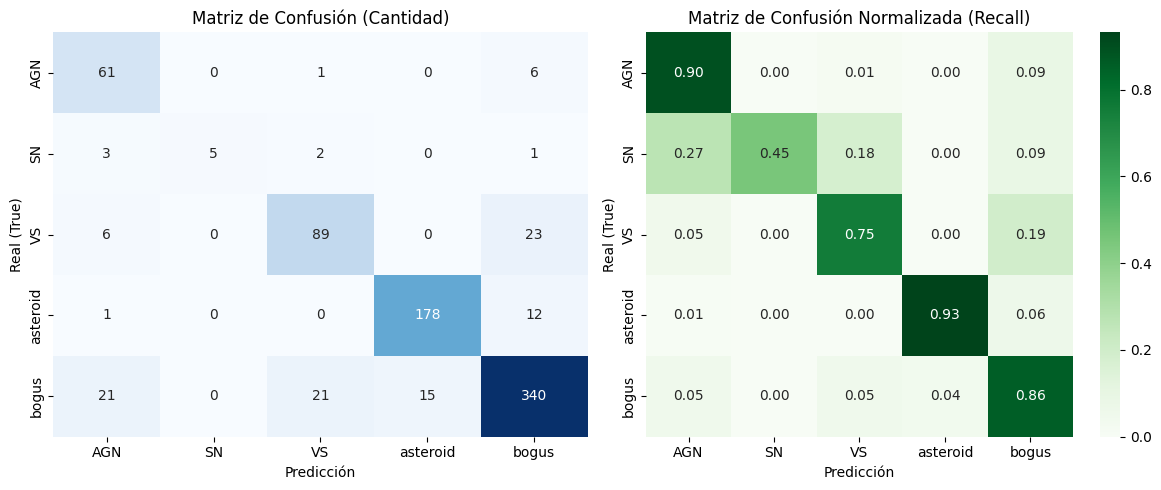


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

         AGN       0.66      0.90      0.76        68
          SN       1.00      0.45      0.62        11
          VS       0.79      0.75      0.77       118
    asteroid       0.92      0.93      0.93       191
       bogus       0.89      0.86      0.87       397

    accuracy                           0.86       785
   macro avg       0.85      0.78      0.79       785
weighted avg       0.86      0.86      0.86       785



In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Cargar el archivo de resultados

# 2. Obtener los nombres de las clases en el orden correcto
# El script anterior guardó las columnas como 'prob_ClaseA', 'prob_ClaseB' ordenadas por índice.
prob_cols = [c for c in predictions.columns if c.startswith('prob_')]
class_names = [c.replace('prob_', '') for c in prob_cols]

print(f"Clases detectadas (orden 0-{len(class_names)-1}): {class_names}")

# 3. Calcular la Matriz de Confusión
y_true = predictions['true_label']
y_pred = predictions['predicted_label']

cm = confusion_matrix(y_true, y_pred)

# 4. Graficar la Matriz de Confusión (Conteo Absoluto)
plt.figure(figsize=(12, 5))

# Subplot 1: Cantidad de objetos
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real (True)')
plt.title('Matriz de Confusión (Cantidad)')

# Subplot 2: Normalizada (Recall por clase)
# Esto es útil para ver qué % de cada clase real se clasificó correctamente
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', cbar=True,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real (True)')
plt.title('Matriz de Confusión Normalizada (Recall)')

plt.tight_layout()
plt.show()

# 5. Reporte de Clasificación detallado (Precision, Recall, F1-Score)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=class_names))

In [14]:
objects_metadata = pd.read_parquet('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/ts_stamps_v0.0.2_comm_4candmax/comm_objs_4candmax.parquet')[['oid', 'measurement_id', 'snr']]
objects_metadata

,oid,measurement_id,snr
0,169298432645136566,169298432645136566,17.405159
1,169298432645136566,169342390804939401,5.099667
2,169298432645136566,169342391077569156,6.517491
3,169298432645136566,169342391901225029,6.289797
4,169298436562092346,169298436562092346,34.58759
...,...,...,...
6963,169623885986660770,169623885986660770,5.368201
6964,169623886050099223,169623886050099223,5.339849
6965,169623886051672110,169623886051672110,8.243246
6966,169623886096236648,169623886096236648,5.227186


In [15]:
predictions

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
0,169298437874909259,169298437874909259,0,0,AGN,AGN,0.909892,0.909892,0.031338,0.025100,0.000203,0.033467
1,169302853217681420,169302853217681420,0,4,AGN,bogus,0.619632,0.037713,0.000481,0.341328,0.000846,0.619632
2,169302854308200461,169302854308200461,0,0,AGN,AGN,0.786920,0.786920,0.007114,0.084929,0.002536,0.118501
3,169302854846644615,169302854846644615,0,0,AGN,AGN,0.892084,0.892084,0.010723,0.035633,0.004053,0.057507
4,169342390655516782,169342390655516782,0,0,AGN,AGN,0.460880,0.460880,0.002680,0.155986,0.001660,0.378793
...,...,...,...,...,...,...,...,...,...,...,...,...
780,169615071701368858,169615071701368858,4,4,bogus,bogus,0.750172,0.109365,0.000671,0.136389,0.003402,0.750172
781,169615109554962465,169615109554962465,4,4,bogus,bogus,0.538124,0.295315,0.002737,0.161656,0.002169,0.538124
782,169615110372851739,169615110372851739,4,3,bogus,asteroid,0.559105,0.007542,0.111306,0.003827,0.559105,0.318220
783,169623885920600163,169623885920600163,4,4,bogus,bogus,0.660667,0.139041,0.001442,0.197874,0.000976,0.660667


In [30]:
fakes_sn = pd.read_pickle('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/simulated_data_20251223/fakes_20251223.pickle')
fakes_sn

,oid,fold,gal_objectId,gal_band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,...,level0_image,level0_header,level1_image,level1_header,level2_image,level2_header,level3_image,level3_header,level4_image,level4_header
0,fakes_20251221_0,train_0,609780764988422794,g,2024120900332,6,592913981740417050,g,2024120200081,7,...,"[[0.004197153, 0.0049062795, 0.006688803, 0.00...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004197153, 0.0049062795, 0.006688803, 0.00...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004197153, 0.0049062795, 0.006688803, 0.00...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004197153, 0.0049062795, 0.006688803, 0.00...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004197153, 0.0049062795, 0.006688803, 0.00...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE..."
1,fakes_20251221_1,train_0,609780764988422794,g,2024120900332,6,592913981740417050,g,2024120200085,5,...,"[[0.004545113, 0.0029715837, 0.0034701652, 0.0...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004545113, 0.0029715837, 0.0034701652, 0.0...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004545113, 0.0029715837, 0.0034701652, 0.0...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004545113, 0.0029715837, 0.0034701652, 0.0...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004545113, 0.0029715837, 0.0034701652, 0.0...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE..."
2,fakes_20251221_2,train_0,609780764988422794,g,2024120900332,6,611253835691723482,g,2024120100148,8,...,"[[0.015448976, 0.018849885, 0.019384798, 0.020...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.015448976, 0.018849885, 0.019384798, 0.020...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.015448976, 0.018849885, 0.019384798, 0.020...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.015448976, 0.018849885, 0.019384798, 0.020...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.015448976, 0.018849885, 0.019384798, 0.020...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE..."
3,fakes_20251221_3,train_0,609780764988422794,g,2024120900332,6,611255003922831024,g,2024112900281,5,...,"[[0.0056003085, 0.0057230457, 0.0040046386, 0....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.0056003085, 0.0057230457, 0.0040046386, 0....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.0056003085, 0.0057230457, 0.0040046386, 0....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.0056003085, 0.0057230457, 0.0040046386, 0....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.0056003085, 0.0057230457, 0.0040046386, 0....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE..."
4,fakes_20251221_4,train_0,609780764988422794,g,2024120900332,6,614431080698610905,g,2024120200340,2,...,"[[0.014220125, 0.017140526, 0.018778317, 0.024...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.014220125, 0.017140526, 0.018778317, 0.024...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.014220125, 0.017140526, 0.018778317, 0.024...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.014220125, 0.017140526, 0.018778317, 0.024...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.014220125, 0.017140526, 0.018778317, 0.024...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21619,fakes_20251221_21619,val_4,611256584470808273,z,2024120900327,2,612928529339777217,z,2024120700486,6,...,"[[0.01469231, 0.01491529, 0.015217164, 0.01418...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.01469231, 0.01491529, 0.015217164, 0.01418...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.01469231, 0.01491529, 0.015217164, 0.01418...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.01469231, 0.01491529, 0.015217164, 0.01418...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.01469231, 0.

In [43]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
# En Jupyter/Colab, display() muestra los DataFrames de forma más bonita
from IPython.display import display 

# --- Tu código inicial para seleccionar los runs de un experimento específico ---
# Asumo que 'runs' ya es un DataFrame cargado con mlflow.search_runs()
# runs['run_name'] = runs['tags.mlflow.runName'].apply(lambda row: '_'.join(row.split('_')[-2:]))
fold_run = runs[runs['run_name'] == run_name]

# --- Listas para almacenar los resultados de cada fold ---
all_confusion_matrices = []
all_confusion_matrices_norm = []
all_classification_reports = []
class_names = [] # Para guardar los nombres de las clases (ej: 'AGN', 'VS')
class_labels = [] # Para guardar las etiquetas numéricas (ej: 0, 2)
all_predictions = []
all_predictions_sim = []

# --- 1. Iterar y recolectar resultados de cada fold ---
print(f"Procesando {len(fold_run)} folds para el experimento {run_name}...\n")

for idx, row in fold_run.iterrows():
    experiment_id = row['experiment_id']
    run_id = row['run_id']
    fold_num = row.get('params.loader.fold', 'N/A') # Intenta obtener el número de fold
    path_pred = f'./{results_file_name}/ml-runs/{experiment_id}/{run_id}/artifacts/test_predictions.csv'
    
    try:
        predictions = pd.read_csv(path_pred)
        #predictions = predictions[predictions.oid.isin(oid_test_used)] ########################################################

        fakes_pred = pd.read_csv(f'./{results_file_name}/ml-runs/{experiment_id}/{run_id}/artifacts/test_sim_predictions.csv')
        fakes_pred = fakes_pred[fakes_pred.oid.isin(fakes_sn[fakes_sn.fold == f'val_{fold_num}'].oid.values)]
        all_predictions_sim.append(fakes_pred)

        y_true = predictions['true_label_int']
        y_pred = predictions['predicted_label_int']
        
        # En la primera iteración, obtenemos los nombres y etiquetas de las clases
        if not class_names:
            # Ordenamos por la etiqueta numérica para asegurar un orden consistente
            labels_df = predictions[['true_label_int', 'true_label']].drop_duplicates().sort_values('true_label_int')
            class_labels = labels_df['true_label_int'].tolist()
            class_names = labels_df['true_label'].tolist()
            print(f"Clases detectadas (en orden): {class_names}")

        all_predictions.append(predictions)

        # a) Calcular y guardar la matriz de confusión
        # Usamos `labels=class_labels` para asegurar que todas las matrices tengan el mismo tamaño y orden
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        all_confusion_matrices.append(cm)

        cm_norm = confusion_matrix(y_true, y_pred, labels=class_labels, normalize='true')
        all_confusion_matrices_norm.append(cm_norm)
        
        # b) Calcular y guardar el reporte de clasificación (como diccionario)
        report = classification_report(
            y_true, 
            y_pred, 
            labels=class_labels, 
            target_names=class_names, 
            output_dict=True,
            zero_division=0 # Evita warnings si una clase no tiene predicciones
        )
        all_classification_reports.append(report)
        
    except FileNotFoundError:
        print(f"ADVERTENCIA: No se encontró el archivo de predicciones para el run_id: {run_id}")
    except Exception as e:
        print(f"Ocurrió un error procesando el run_id {run_id}: {e}")

# --- 2. Procesar y promediar los resultados recolectados ---

# --- a) Matriz de Confusión ---
if all_confusion_matrices:
    # Convertimos la lista de matrices 2D en un array 3D de NumPy
    cm_stack = np.stack(all_confusion_matrices, axis=0)
    mean_cm = np.mean(cm_stack, axis=0)
    std_cm = np.std(cm_stack, axis=0)

    cm_norm_stack = np.stack(all_confusion_matrices_norm, axis=0)
    mean_cm_norm = np.mean(cm_norm_stack, axis=0)
    std_cm_norm = np.std(cm_norm_stack, axis=0)
    
    # Creamos DataFrames para una visualización clara
    mean_cm_df = pd.DataFrame(mean_cm, index=class_names, columns=class_names)
    std_cm_df = pd.DataFrame(std_cm, index=class_names, columns=class_names)
    
    print("\n" + "="*50)
    print("       MATRIZ DE CONFUSIÓN (PROMEDIO Y STD)")
    print("="*50)
    print("\n--- Matriz de Confusión Promedio (número de muestras) ---")
    print("Filas: Etiqueta Verdadera, Columnas: Etiqueta Predicha")
    display(mean_cm_df.round(2))
    
    print("\n--- Desviación Estándar de la Matriz de Confusión ---")
    display(std_cm_df.round(2))

else:
    print("\nNo se encontraron matrices de confusión para procesar.")

# --- b) Reporte de Clasificación ---
if all_classification_reports:
    # Parseamos la lista de diccionarios para crear un DataFrame más manejable
    report_data = []
    for report in all_classification_reports:
        for class_name, metrics in report.items():
            # Solo nos interesan las clases, no las métricas agregadas como 'accuracy'
            if class_name in class_names:
                report_data.append({
                    'class': class_name,
                    'precision': metrics['precision'],
                    'recall': metrics['recall'],
                    'f1-score': metrics['f1-score'],
                    'support': metrics['support']
                })
    
    reports_df = pd.DataFrame(report_data)
    
    # Agrupamos por clase y calculamos la media y std para cada métrica
    final_report = reports_df.groupby('class').agg({
        'precision': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'f1-score': ['mean', 'std'],
        'support': ['mean'] # El support debería ser el mismo en todos los folds de test
    })
    
    print("\n" + "="*50)
    print("    REPORTE DE CLASIFICACIÓN (PROMEDIO Y STD)")
    print("="*50)
    display(final_report.round(3))

else:
    print("\nNo se encontraron reportes de clasificación para procesar.")

Procesando 6 folds para el experimento 2026-01-06_19-10-46...

Clases detectadas (en orden): ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
ADVERTENCIA: No se encontró el archivo de predicciones para el run_id: 98bfd4416bc042909245e1b01b1ca707

       MATRIZ DE CONFUSIÓN (PROMEDIO Y STD)

--- Matriz de Confusión Promedio (número de muestras) ---
Filas: Etiqueta Verdadera, Columnas: Etiqueta Predicha


,AGN,SN,VS,asteroid,bogus
AGN,60.4,0.0,2.4,0.0,5.2
SN,4.0,4.4,1.6,0.0,1.0
VS,6.6,0.0,90.0,0.6,20.8
asteroid,0.6,0.0,0.0,178.4,12.0
bogus,21.0,0.2,20.2,15.0,340.6



--- Desviación Estándar de la Matriz de Confusión ---


,AGN,SN,VS,asteroid,bogus
AGN,0.80,0.00,0.80,0.00,1.17
SN,0.89,1.02,0.49,0.00,0.63
VS,0.80,0.00,2.00,0.80,2.04
asteroid,0.49,0.00,0.00,1.02,1.10
bogus,1.26,0.40,1.33,1.26,1.62



    REPORTE DE CLASIFICACIÓN (PROMEDIO Y STD)


precision        recall        f1-score        support
              mean    std   mean    std     mean    std    mean
class                                                          
AGN          0.653  0.018  0.888  0.013    0.752  0.015    68.0
SN           0.960  0.089  0.400  0.104    0.559  0.108    11.0
VS           0.788  0.013  0.763  0.019    0.775  0.010   118.0
asteroid     0.920  0.009  0.934  0.006    0.927  0.004   191.0
bogus        0.897  0.006  0.858  0.005    0.877  0.003   397.0

In [44]:
# --- b) Reporte de Clasificación ---
if all_classification_reports:
    # 1. Agrupar los resultados por clase (igual que antes)
    # ---------------------------------------------------------------------
    report_data = []
    # También recolectamos las métricas agregadas
    all_accuracies = []
    all_macro_avg = []
    all_weighted_avg = []

    for report in all_classification_reports:
        # Extraer métricas por clase
        for class_name in class_names:
            if class_name in report:
                metrics = report[class_name]
                report_data.append({
                    'class': class_name,
                    'precision': metrics['precision'],
                    'recall': metrics['recall'],
                    'f1-score': metrics['f1-score'],
                    'support': metrics['support']
                })
        # Extraer métricas agregadas
        all_accuracies.append(report['accuracy'])
        all_macro_avg.append(report['macro avg'])
        all_weighted_avg.append(report['weighted avg'])
    
    reports_df = pd.DataFrame(report_data)
    
    # Agrupamos por clase y calculamos la media y std para cada métrica
    final_report_stats = reports_df.groupby('class').agg(['mean', 'std'])

    # 2. Calcular media y std para las métricas agregadas
    # ---------------------------------------------------------------------
    accuracy_mean = np.mean(all_accuracies)
    accuracy_std = np.std(all_accuracies)

    macro_avg_df = pd.DataFrame(all_macro_avg)
    macro_avg_mean = macro_avg_df.mean()
    macro_avg_std = macro_avg_df.std()

    weighted_avg_df = pd.DataFrame(all_weighted_avg)
    weighted_avg_mean = weighted_avg_df.mean()
    weighted_avg_std = weighted_avg_df.std()

    # El soporte total es la suma del soporte medio de cada clase
    total_support = int(final_report_stats[('support', 'mean')].sum())

    # 3. Imprimir el reporte con el formato "media ± std"
    # ---------------------------------------------------------------------
    print("\n" + "="*65)
    print("        REPORTE DE CLASIFICACIÓN (PROMEDIO Y STD POR FOLD)")
    print("="*65)

    # Determinar el espacio para los nombres de las clases para alinear todo
    max_len = max(len(name) for name in class_names)
    header = f"{'':>{max_len}} {'precision':>20} {'recall':>20} {'f1-score':>20} {'support':>9}"
    print(header)
    print("-"*len(header))

    # Imprimir métricas por clase
    for class_name in class_names:
        precision_mean = final_report_stats.loc[class_name, ('precision', 'mean')]
        precision_std = final_report_stats.loc[class_name, ('precision', 'std')]
        recall_mean = final_report_stats.loc[class_name, ('recall', 'mean')]
        recall_std = final_report_stats.loc[class_name, ('recall', 'std')]
        f1_mean = final_report_stats.loc[class_name, ('f1-score', 'mean')]
        f1_std = final_report_stats.loc[class_name, ('f1-score', 'std')]
        support = int(final_report_stats.loc[class_name, ('support', 'mean')])

        p_str = f"{precision_mean:.2f} ± {precision_std:.2f}"
        r_str = f"{recall_mean:.2f} ± {recall_std:.2f}"
        f1_str = f"{f1_mean:.2f} ± {f1_std:.2f}"
        
        print(f"{class_name:<{max_len}} {p_str:>20} {r_str:>20} {f1_str:>20} {support:>9}")

    print("\n") # Línea en blanco para separar

    # Imprimir métricas agregadas
    # Accuracy
    acc_str = f"{accuracy_mean:.2f} ± {accuracy_std:.2f}"
    print(f"{'accuracy':<{max_len}} {'':>20} {'':>20} {acc_str:>20} {total_support:>9}")

    # Macro Avg
    p_str = f"{macro_avg_mean['precision']:.2f} ± {macro_avg_std['precision']:.2f}"
    r_str = f"{macro_avg_mean['recall']:.2f} ± {macro_avg_std['recall']:.2f}"
    f1_str = f"{macro_avg_mean['f1-score']:.2f} ± {macro_avg_std['f1-score']:.2f}"
    print(f"{'macro avg':<{max_len}} {p_str:>20} {r_str:>20} {f1_str:>20} {total_support:>9}")

    # Weighted Avg
    p_str = f"{weighted_avg_mean['precision']:.2f} ± {weighted_avg_std['precision']:.2f}"
    r_str = f"{weighted_avg_mean['recall']:.2f} ± {weighted_avg_std['recall']:.2f}"
    f1_str = f"{weighted_avg_mean['f1-score']:.2f} ± {weighted_avg_std['f1-score']:.2f}"
    print(f"{'weighted avg':<{max_len}} {p_str:>20} {r_str:>20} {f1_str:>20} {total_support:>9}")

else:
    print("\nNo se encontraron reportes de clasificación para procesar.")


        REPORTE DE CLASIFICACIÓN (PROMEDIO Y STD POR FOLD)
                    precision               recall             f1-score   support
---------------------------------------------------------------------------------
AGN               0.65 ± 0.02          0.89 ± 0.01          0.75 ± 0.01        68
SN                0.96 ± 0.09          0.40 ± 0.10          0.56 ± 0.11        11
VS                0.79 ± 0.01          0.76 ± 0.02          0.78 ± 0.01       118
asteroid          0.92 ± 0.01          0.93 ± 0.01          0.93 ± 0.00       191
bogus             0.90 ± 0.01          0.86 ± 0.00          0.88 ± 0.00       397


accuracy                                                    0.86 ± 0.00       785
macro avg          0.84 ± 0.02          0.77 ± 0.02          0.78 ± 0.02       785
weighted avg          0.87 ± 0.00          0.86 ± 0.00          0.86 ± 0.00       785


In [45]:
def get_confusion_matrix(mean_matrix, std_matrix, order_classes):
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=(6, 6)) #, dpi=110)
    im = ax.imshow(np.around(mean_matrix, decimals=2), interpolation='nearest', cmap=cmap)

    # color map
    new_color = cmap(1.0) 

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    for i in range(mean_matrix.shape[0]):
        for j in range(mean_matrix.shape[1]):
            if mean_matrix[i, j] >= 0.005:
                #print(mean_matrix[i, j])
                text = f'{np.around(mean_matrix[i, j], decimals=2)}\n±{np.around(std_matrix[i, j], decimals=2)}'
                color = "white" if mean_matrix[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12.5)
            else:
                text = f'{np.around(mean_matrix[i, j], decimals=2)}'
                color = "white" if mean_matrix[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12.5)

    # Ajustes finales y mostrar la gráfica
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(np.arange(len(order_classes)))
    ax.set_yticks(np.arange(len(order_classes)))
    ax.set_xticklabels(order_classes)
    ax.set_yticklabels(order_classes)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    plt.tight_layout()
    plt.show()

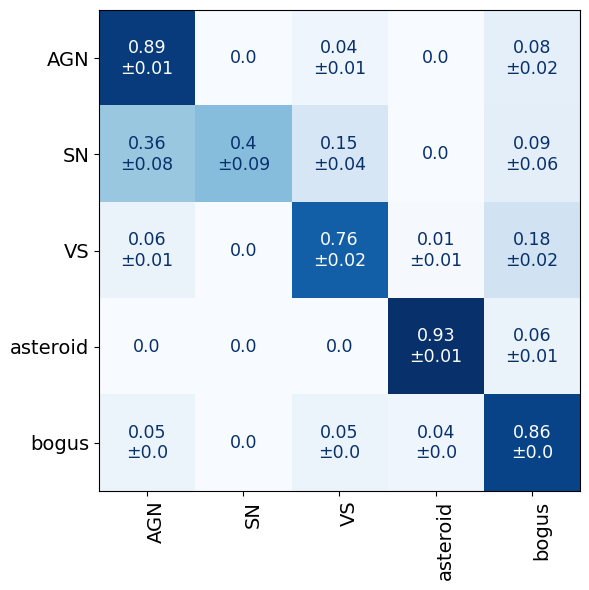

In [46]:
order_classes = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
get_confusion_matrix(mean_cm_norm, std_cm_norm, order_classes)


      GRÁFICO DE MATRIZ DE CONFUSIÓN MIXTA
Texto: Recuento Promedio ± Std (No Normalizado)
Color: Proporción Promedio (Normalizado por fila/Recall)


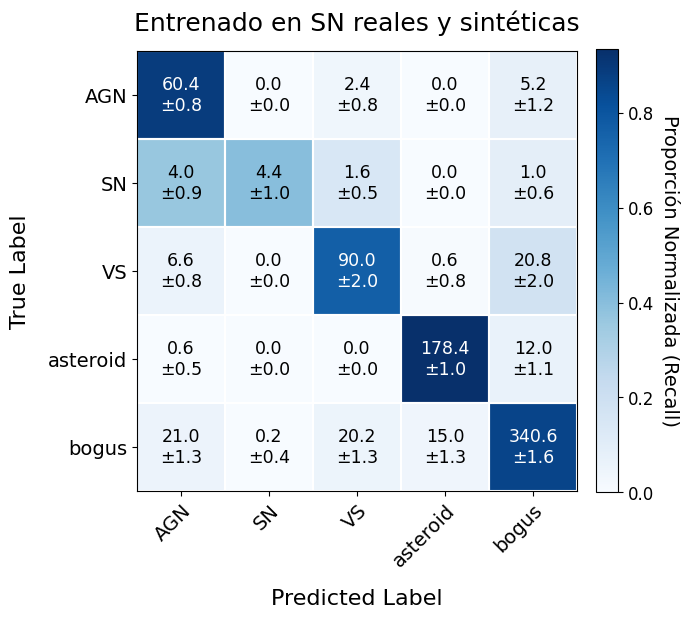

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn es excelente para heatmaps, pero nos quedaremos con plt para mantener tu estilo

# --- REEMPLAZA TU FUNCIÓN get_confusion_matrix CON ESTA ---
def plot_mixed_confusion_matrix(mean_text, std_text, mean_color, class_names, 
                                figsize=(7, 7), cmap='Blues', title='Entrenado en SN reales y sintéticas'):
    """
    Grafica una matriz de confusión con valores de texto no normalizados (media ± std)
    y colores de celda y barra de color basados en valores normalizados.

    Args:
        mean_text (np.array): Matriz promedio con los recuentos absolutos (no normalizada).
        std_text (np.array): Matriz de desviación estándar de los recuentos absolutos.
        mean_color (np.array): Matriz promedio normalizada (por fila, 'true') para el color.
        class_names (list): Lista de nombres de las clases para los ejes.
        figsize (tuple): Tamaño de la figura.
        cmap (str): Colormap a utilizar.
        title (str): Título del gráfico.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # 1. Usar la matriz NORMALIZADA (mean_color) para generar el heatmap (los colores)
    im = ax.imshow(mean_color, interpolation='nearest', cmap=cmap)

    # 2. Añadir la barra de color basada en la matriz NORMALIZADA
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proporción Normalizada (Recall)", rotation=-90, va="bottom", size=14)
    cbar.ax.tick_params(labelsize=12)

    # 3. Iterar y añadir el texto usando las matrices NO NORMALIZADAS (mean_text y std_text)
    threshold = mean_color.max() / 2.  # Umbral para cambiar el color del texto (blanco/negro)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            # Formateamos el texto con los valores no normalizados
            text_val = f"{mean_text[i, j]:.1f}\n±{std_text[i, j]:.1f}"
            
            # El color del texto depende del color de fondo (que viene de la matriz normalizada)
            text_color = "white" if mean_color[i, j] > threshold else "black"
            
            ax.text(j, i, text_val, ha="center", va="center", color=text_color, fontsize=12.5)

    # --- Estilo y etiquetas (similar a tu código original) ---
    ax.set_title(title, fontsize=18, pad=15)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    ax.set_ylabel('True Label', fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=16)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    # Añadir un borde a las celdas para mayor claridad
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='white', lw=1.5))


    fig.tight_layout()
    plt.show()

# Asegúrate de que 'class_names' es la variable correcta que contiene ['AGN', 'SN', ...]
# Tu código ya la define correctamente al inicio del bucle.
# La variable 'order_classes' que tenías es redundante si 'class_names' está bien definida.

if all_confusion_matrices:
    print("\n" + "="*50)
    print("      GRÁFICO DE MATRIZ DE CONFUSIÓN MIXTA")
    print("="*50)
    print("Texto: Recuento Promedio ± Std (No Normalizado)")
    print("Color: Proporción Promedio (Normalizado por fila/Recall)")
    
    plot_mixed_confusion_matrix(
        mean_text=mean_cm,          # Matriz NO normalizada para el texto
        std_text=std_cm,            # Matriz NO normalizada para el texto
        mean_color=mean_cm_norm,    # Matriz NORMALIZADA para el color
        class_names=class_names     # Los nombres de las clases en el orden correcto
    )
else:
    print("No hay datos para graficar la matriz de confusión.")


  MATRIZ DE CONFUSIÓN ESTIMADA PARA EL ENTORNO DE PRODUCCIÓN


,AGN,SN,VS,asteroid,bogus
AGN,62.2,0.0,2.5,0.0,5.4
SN,72.7,80.0,29.1,0.0,18.2
VS,402.7,0.0,5491.5,36.6,1269.2
asteroid,9.4,0.0,0.0,2802.1,188.5
bogus,553.8,5.3,532.7,395.6,8982.6


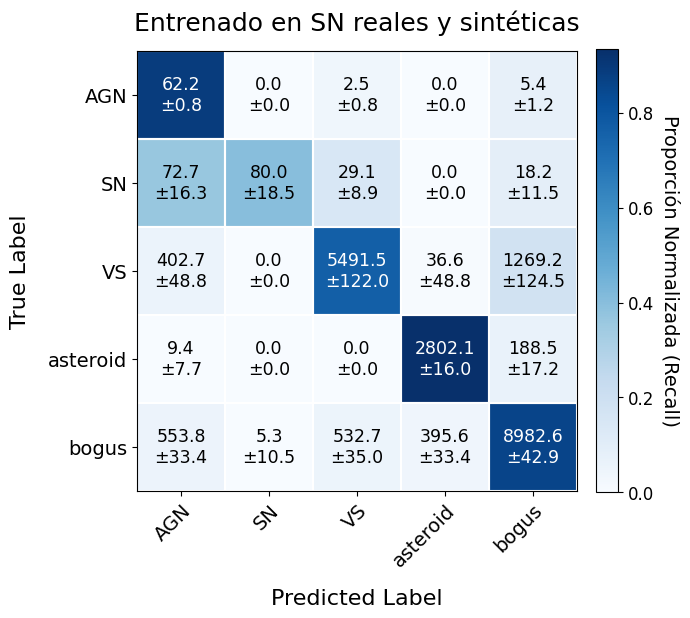

In [48]:
# 1. Definir la distribución de clases esperada en producción
prod_distribution = {
    'AGN': 70,
    'SN': 200,
    'VS': 7200,
    'asteroid': 3000,
    'bogus': 10470
}

# Asegurarnos de que el orden de las clases en el diccionario coincide con el de la matriz
# 'class_names' ya debería tener el orden correcto ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
prod_counts = np.array([prod_distribution[name] for name in class_names])

# 2. Calcular la matriz de confusión estimada para producción
# Usamos broadcasting de NumPy: (5x5 matrix) * (5x1 vector)
# Esto multiplica cada fila de la matriz por el elemento correspondiente del vector.
estimated_prod_cm = mean_cm_norm * prod_counts[:, np.newaxis]

# Para la desviación estándar, la propagación de errores es un poco más compleja,
# pero una aproximación razonable es escalar de la misma manera.
estimated_prod_std_cm = std_cm_norm * prod_counts[:, np.newaxis]


# 3. Mostrar y visualizar la nueva matriz de confusión estimada para producción
print("\n" + "="*60)
print("  MATRIZ DE CONFUSIÓN ESTIMADA PARA EL ENTORNO DE PRODUCCIÓN")
print("="*60)
estimated_prod_cm_df = pd.DataFrame(estimated_prod_cm, index=class_names, columns=class_names)
display(estimated_prod_cm_df.round(1))

# Visualizar la nueva matriz. 
# Nota: La normalizamos de nuevo para que los colores sigan representando el recall,
# pero el texto mostrará los números absolutos de producción.
estimated_prod_cm_norm_color = estimated_prod_cm / estimated_prod_cm.sum(axis=1, keepdims=True)

plot_mixed_confusion_matrix(
    mean_text=estimated_prod_cm,
    std_text=estimated_prod_std_cm,
    mean_color=estimated_prod_cm_norm_color, # Usamos la versión normalizada para el color
    class_names=class_names,
    title='Entrenado en SN reales y sintéticas'
)

In [49]:
# 4. (OPCIONAL PERO MUY RECOMENDADO) Calcular métricas de producción
# A partir de esta matriz estimada, podemos recalcular la Precisión, Recall, etc.
# que esperaríamos en producción.
print("\n" + "="*60)
print("      MÉTRICAS ESTIMADAS PARA EL ENTORNO DE PRODUCCIÓN")
print("="*60)

for i, class_name in enumerate(class_names):
    TP = estimated_prod_cm[i, i]
    FP = estimated_prod_cm[:, i].sum() - TP
    FN = estimated_prod_cm[i, :].sum() - TP
    
    # Precisión: De todo lo que se predijo como esta clase, ¿cuánto fue correcto?
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    # Recall: De todo lo que realmente era de esta clase, ¿cuánto se encontró?
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    print(f"--- Clase: {class_name} ---")
    print(f"  Verdaderos Positivos (TP) esperados: {TP:.1f}")
    print(f"  Falsos Positivos (FP) esperados:     {FP:.1f}")
    print(f"  Falsos Negativos (FN) esperados:     {FN:.1f}")
    print(f"  Precisión estimada en producción:    {precision:.2%}")
    print(f"  Recall estimado en producción:       {recall:.2%}\n")


      MÉTRICAS ESTIMADAS PARA EL ENTORNO DE PRODUCCIÓN
--- Clase: AGN ---
  Verdaderos Positivos (TP) esperados: 62.2
  Falsos Positivos (FP) esperados:     1038.7
  Falsos Negativos (FN) esperados:     7.8
  Precisión estimada en producción:    5.65%
  Recall estimado en producción:       88.82%

--- Clase: SN ---
  Verdaderos Positivos (TP) esperados: 80.0
  Falsos Positivos (FP) esperados:     5.3
  Falsos Negativos (FN) esperados:     120.0
  Precisión estimada en producción:    93.81%
  Recall estimado en producción:       40.00%

--- Clase: VS ---
  Verdaderos Positivos (TP) esperados: 5491.5
  Falsos Positivos (FP) esperados:     564.3
  Falsos Negativos (FN) esperados:     1708.5
  Precisión estimada en producción:    90.68%
  Recall estimado en producción:       76.27%

--- Clase: asteroid ---
  Verdaderos Positivos (TP) esperados: 2802.1
  Falsos Positivos (FP) esperados:     432.2
  Falsos Negativos (FN) esperados:     197.9
  Precisión estimada en producción:    86.64%
  R

In [50]:
class_map = {
    0: "AGN",
    1: "SN",
    2: "VS",
    3: "asteroid",
    4: "bogus"
}

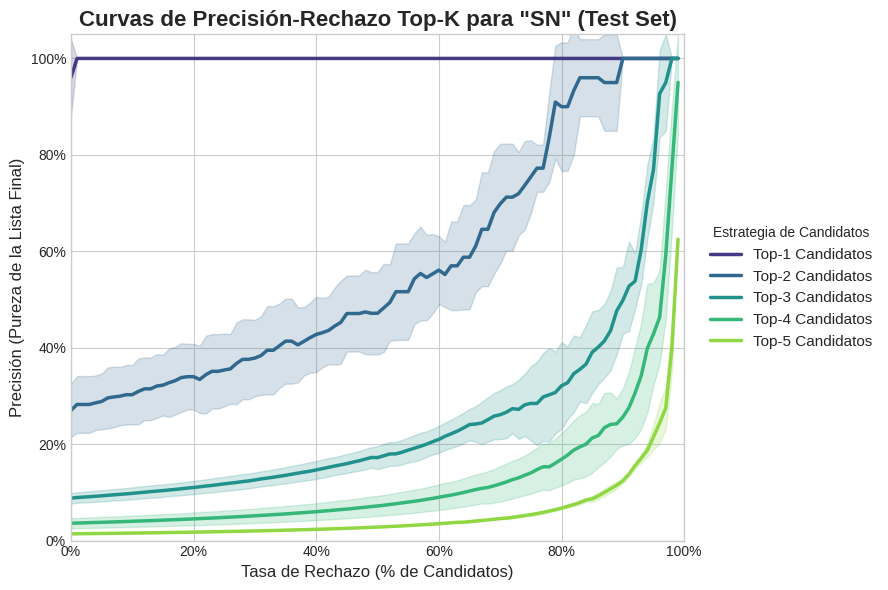

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# --- Configuración del Análisis (sin cambios) ---
TARGET_CLASS_NAME = 'SN'
prob_columns = [f'prob_{name}' for name in class_map.values()]
class_map_inv = {v: k for k, v in class_map.items()}
target_class_id = class_map_inv[TARGET_CLASS_NAME]
prob_column_name = f'prob_{TARGET_CLASS_NAME}'

k_values = [1, 2, 3, 4, 5]
rejection_rates = np.linspace(0, 0.99, 100)

all_curves_data = {k: [] for k in k_values}

# --- Bucle principal por Fold (sin cambios) ---
for df_fold in all_predictions:
    probs = df_fold[prob_columns].to_numpy()
    sorted_class_indices = np.argsort(probs, axis=1)[:, ::-1]
    
    for k in k_values:
        top_k_indices = sorted_class_indices[:, :k]
        is_candidate = np.any(top_k_indices == target_class_id, axis=1)
        df_candidates_k = df_fold[is_candidate]
        
        if len(df_candidates_k) == 0:
            all_curves_data[k].append([np.nan] * len(rejection_rates))
            continue

        fold_precisions = []
        scores = df_candidates_k[prob_column_name].values
        
        for rate in rejection_rates:
            if len(scores) < 2:
                fold_precisions.append(np.nan)
                continue
                
            threshold = np.quantile(scores, rate)
            df_accepted = df_candidates_k[df_candidates_k[prob_column_name] >= threshold]
            
            if len(df_accepted) > 0:
                is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
                precision = is_correct.mean()
            else:
                precision = np.nan
                
            fold_precisions.append(precision)
        
        all_curves_data[k].append(fold_precisions)

# --- Agregación y Visualización (Con la leyenda afuera) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette("viridis", n_colors=len(k_values))

for i, k in enumerate(k_values):
    precisions_array = np.array(all_curves_data[k])
    
    mean_precisions = np.nanmean(precisions_array, axis=0)
    std_precisions = np.nanstd(precisions_array, axis=0)
    upper_bound = mean_precisions + std_precisions
    lower_bound = mean_precisions - std_precisions
    
    if not np.all(np.isnan(mean_precisions)):
        ax.plot(rejection_rates * 100, mean_precisions, 
                label=f'Top-{k} Candidatos', 
                color=palette[i], linewidth=2.5)
        
        ax.fill_between(rejection_rates * 100, lower_bound, upper_bound,
                        color=palette[i], alpha=0.2)

# Formato y etiquetas
ax.set_title(f'Curvas de Precisión-Rechazo Top-K para "{TARGET_CLASS_NAME}" (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (% de Candidatos)', fontsize=12)
ax.set_ylabel('Precisión (Pureza de la Lista Final)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

# --- LÍNEA MODIFICADA PARA MOVER LA LEYENDA ---
ax.legend(title="Estrategia de Candidatos", fontsize=11, 
          bbox_to_anchor=(1.02, 0.5), loc='center left')
# ---------------------------------------------

# Ajusta el layout para asegurar que la leyenda quepa
plt.tight_layout()
plt.show()

Usando datos de ejemplo (mock) para 'tables'.



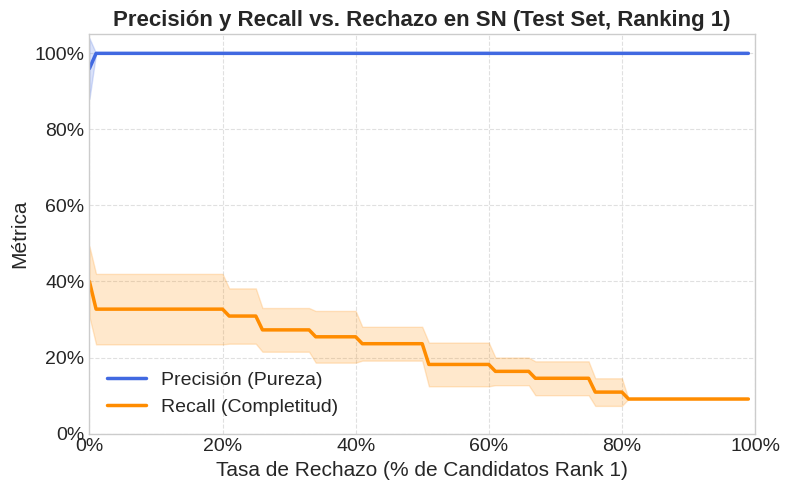

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Asumimos que 'all_predictions', 'tables' y 'class_map' ya existen ---
# (Usaré mocks para que el código sea ejecutable)
# ----------------- INICIO DEL MOCK DATA -----------------
def create_mock_predictions_sn(num_rows=800, num_folds=5): # Test Set Data
    mock_list = []
    labels = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
    label_p = [0.1, 0.02, 0.15, 0.25, 0.48]
    for i in range(num_folds):
        df = pd.DataFrame()
        df['true_label'] = np.random.choice(labels, num_rows, p=label_p)
        probs = np.random.rand(num_rows, len(labels))
        # Make SN probs higher for real SNs and for predicted SNs
        true_sn_indices = df[df['true_label'] == 'SN'].index
        probs[true_sn_indices, 1] = np.clip(probs[true_sn_indices, 1] + 0.6, 0, 1)
        probs = probs / probs.sum(axis=1, keepdims=True)
        for idx, label_name in enumerate(labels):
             df[f'prob_{label_name}'] = probs[:, idx]
        df['predicted_label'] = pd.Index(labels)[np.argmax(probs, axis=1)]
        mock_list.append(df)
    return mock_list

def create_mock_tables(num_rows=20000): # Production Data
    df = pd.DataFrame()
    df['class_id'] = np.random.choice([0, 1, 2, 3, 4], num_rows, p=[0.05, 0.2, 0.3, 0.15, 0.3])
    df['ranking'] = np.random.randint(1, 6, num_rows)
    probs = np.random.beta(a=2, b=15, size=num_rows) + (1 - (df['ranking'] / 5)) * 0.3
    sn_indices = df[df['class_id'] == 0].index
    probs[sn_indices] = probs[sn_indices] + np.random.uniform(0, 0.4, size=len(sn_indices))
    df['probability'] = np.clip(probs, 0.01, 1.0)
    return df

class_map = {0: 'AGN', 1: 'SN', 2: 'VS', 3: 'asteroid', 4: 'bogus'}
if 'all_predictions' not in locals():
    print("Usando datos de ejemplo (mock) para 'all_predictions'.")
    all_predictions = create_mock_predictions_sn()
if 'tables' not in locals():
    print("Usando datos de ejemplo (mock) para 'tables'.\n")
    tables = create_mock_tables()
# ----------------- FIN DEL MOCK DATA -----------------


# --- Configuración del Análisis ---
TARGET_CLASS_NAME = 'SN'
SN_CLASS_ID = 1 # Asumo ID=1 para SN, cámbialo si es necesario
prob_column_name = f'prob_{TARGET_CLASS_NAME}'
rejection_rates = np.linspace(0, 0.99, 100)

# --- Creación de los Subplots ---
fig, ax1 = plt.subplots(figsize=(8, 5))
#ax1, ax2 = axes[0], axes[1]

# ==============================================================================
# GRÁFICO 1: ANÁLISIS EN EL CONJUNTO DE TEST (all_predictions)
# ==============================================================================
precisions_per_fold = []
recalls_per_fold = []

for df_fold in all_predictions:
    # El denominador del Recall: el número total de SN reales en este fold
    total_true_sns_in_fold = (df_fold['true_label'] == TARGET_CLASS_NAME).sum()

    # Filtramos para quedarnos solo con los candidatos de Ranking 1
    # En este dataset, Ranking 1 significa que la predicción fue SN
    candidates_rank1 = df_fold[df_fold['predicted_label'] == TARGET_CLASS_NAME]
    
    fold_precisions, fold_recalls = [], []
    scores = candidates_rank1[prob_column_name].values
    
    for rate in rejection_rates:
        if len(scores) < 2 or total_true_sns_in_fold == 0:
            fold_precisions.append(np.nan)
            fold_recalls.append(np.nan)
            continue
            
        threshold = np.quantile(scores, rate)
        df_accepted = candidates_rank1[candidates_rank1[prob_column_name] >= threshold]
        
        if len(df_accepted) > 0:
            # Precisión
            is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
            precision = is_correct.mean()
            # Recall
            true_positives = is_correct.sum()
            recall = true_positives / total_true_sns_in_fold
        else:
            precision, recall = np.nan, 0 # Si no aceptamos nada, la precisión es indefinida y el recall es 0
            
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        
    precisions_per_fold.append(fold_precisions)
    recalls_per_fold.append(fold_recalls)

# --- Agregación y Visualización para Test Set ---
# Precisión
mean_precisions = np.nanmean(precisions_per_fold, axis=0)
std_precisions = np.nanstd(precisions_per_fold, axis=0)
# Recall
mean_recalls = np.nanmean(recalls_per_fold, axis=0)
std_recalls = np.nanstd(recalls_per_fold, axis=0)

# Graficar Precisión
ax1.plot(rejection_rates * 100, mean_precisions, label='Precisión (Pureza)', color='royalblue', lw=2.5)
ax1.fill_between(rejection_rates * 100, mean_precisions - std_precisions, mean_precisions + std_precisions, color='royalblue', alpha=0.2)

# Graficar Recall
ax1.plot(rejection_rates * 100, mean_recalls, label='Recall (Completitud)', color='darkorange', lw=2.5)
ax1.fill_between(rejection_rates * 100, mean_recalls - std_recalls, mean_recalls + std_recalls, color='darkorange', alpha=0.2)
ax1.set_title('Precisión y Recall vs. Rechazo en SN (Test Set, Ranking 1)', fontsize=16, weight='bold')
ax1.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=15)
ax1.set_ylabel('Métrica', fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=14)

ax1.set_ylim(0, 1.05)
ax1.set_xlim(0, 100)

ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
ax1.legend(fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# ==============================================================================
# GRÁFICO 2: ANÁLISIS EN PRODUCCIÓN (tables)
# ==============================================================================
# Denominador del Recall: Total de SN reales en producción
total_true_sns_in_prod = (tables['class_id'] == SN_CLASS_ID).sum()

# Filtramos para candidatos de Ranking 1
prod_candidates_rank1 = tables[
    (tables.class_id == SN_CLASS_ID) & # Esto es para producción, así que asumimos que class_id es el tipo de objeto
    (tables.ranking == 1)
]

prod_precisions, prod_recalls = [], []
prod_scores = prod_candidates_rank1['probability'].values

for rate in rejection_rates:
    if len(prod_scores) < 2 or total_true_sns_in_prod == 0:
        prod_precisions.append(np.nan)
        prod_recalls.append(np.nan)
        continue

    threshold = np.quantile(prod_scores, rate)
    df_accepted = prod_candidates_rank1[prod_candidates_rank1.probability >= threshold]
    
    if len(df_accepted) > 0:
        # En producción, la precisión de los candidatos de Rank 1 es siempre 100% por definición
        precision = 1.0 
        true_positives = len(df_accepted)
        recall = true_positives / total_true_sns_in_prod
    else:
        precision, recall = np.nan, 0
    
    prod_precisions.append(precision)
    prod_recalls.append(recall)

# --- Visualización para Producción ---
#ax2.plot(rejection_rates * 100, prod_precisions, label='Precisión (Pureza)', color='royalblue', lw=2.5)
#ax2.plot(rejection_rates * 100, prod_recalls, label='Recall (Completitud)', color='darkorange', lw=2.5)
#ax2.set_title('Precisión y Recall vs. Rechazo (Producción, Ranking 1)', fontsize=14, weight='bold')
#ax2.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=12)

# --- Formato Final para Ambos Gráficos ---
#for ax in axes:
#    ax.set_ylim(0, 1.05)
#    ax.set_xlim(0, 100)
#    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
#    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
#    ax.legend()
#    ax.grid(True, linestyle='--', alpha=0.6)

#fig.suptitle('Análisis del Trade-off Precisión-Recall para Candidatos a SN de Ranking 1', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

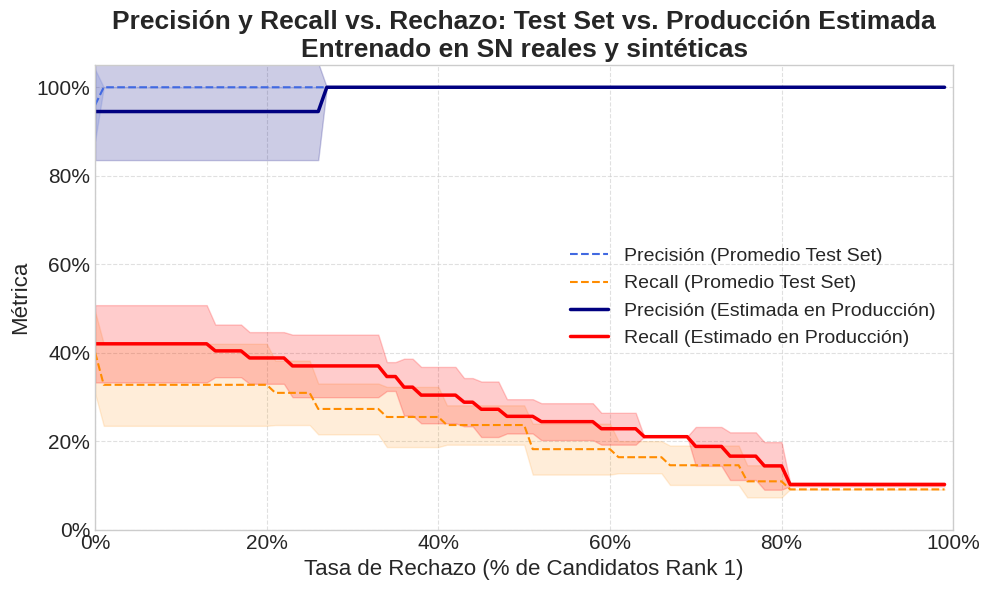

In [53]:
# --- CÓDIGO FINAL Y CORREGIDO PARA LA ESTIMACIÓN EN PRODUCCIÓN CON STD ---

# 1. Definir la distribución de clases de producción
prod_distribution = {
    'AGN': 70,
    'SN': 200,
    'VS': 7200,
    'asteroid': 3000,
    'bogus': 10470
}

# 2. Listas para guardar las curvas de cada simulación de fold
prod_sim_precisions_per_fold = []
prod_sim_recalls_per_fold = []

# 3. Iterar a través de las predicciones de cada fold individual
for df_fold in all_predictions:
    
    # --- a. Crear un DataFrame de producción simulado PARA ESTE FOLD ---
    prod_sim_df_list_fold = []
    for class_name, num_samples in prod_distribution.items():
        class_subset = df_fold[df_fold['true_label'] == class_name]
        
        if len(class_subset) == 0:
            # Si una clase no está en el test set de este fold, no podemos simularla.
            # Esto puede introducir algo de ruido, pero es la única opción.
            continue
        
        prod_sim_df_list_fold.append(
            class_subset.sample(n=num_samples, replace=True, random_state=42)
        )

    # Si por alguna razón no se pudo crear el df (ej. faltaban muchas clases)
    if not prod_sim_df_list_fold:
        continue
        
    prod_sim_df_fold = pd.concat(prod_sim_df_list_fold, ignore_index=True)
    
    # --- b. Calcular la curva de P-R para la simulación de este fold ---
    TARGET_CLASS_NAME = 'SN'
    prob_column_name = f'prob_{TARGET_CLASS_NAME}'
    rejection_rates = np.linspace(0, 0.99, 100)
    total_true_sns_in_prod_sim = prod_distribution.get(TARGET_CLASS_NAME, 0)

    candidates_rank1 = prod_sim_df_fold[prod_sim_df_fold['predicted_label'] == TARGET_CLASS_NAME]
    scores = candidates_rank1[prob_column_name].values
    
    fold_precisions, fold_recalls = [], []
    for rate in rejection_rates:
        if len(scores) < 2 or total_true_sns_in_prod_sim == 0:
            fold_precisions.append(np.nan)
            fold_recalls.append(np.nan)
            continue
            
        threshold = np.quantile(scores, rate)
        df_accepted = candidates_rank1[candidates_rank1[prob_column_name] >= threshold]
        
        if len(df_accepted) > 0:
            is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
            precision = is_correct.mean()
            true_positives = is_correct.sum()
            recall = true_positives / total_true_sns_in_prod_sim
        else:
            precision, recall = np.nan, 0
            
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        
    prod_sim_precisions_per_fold.append(fold_precisions)
    prod_sim_recalls_per_fold.append(fold_recalls)

# 4. Agregar los resultados de todas las simulaciones de folds
# Precisión
mean_prod_sim_precisions = np.nanmean(prod_sim_precisions_per_fold, axis=0)
std_prod_sim_precisions = np.nanstd(prod_sim_precisions_per_fold, axis=0)
# Recall
mean_prod_sim_recalls = np.nanmean(prod_sim_recalls_per_fold, axis=0)
std_prod_sim_recalls = np.nanstd(prod_sim_recalls_per_fold, axis=0)

# 5. Graficar todo junto
fig, ax = plt.subplots(figsize=(10, 6))

# Curvas originales del Test Set
ax.plot(rejection_rates * 100, mean_precisions, label='Precisión (Promedio Test Set)', color='royalblue', ls='--')
ax.fill_between(rejection_rates * 100, mean_precisions - std_precisions, mean_precisions + std_precisions, color='royalblue', alpha=0.15)
ax.plot(rejection_rates * 100, mean_recalls, label='Recall (Promedio Test Set)', color='darkorange', ls='--')
ax.fill_between(rejection_rates * 100, mean_recalls - std_recalls, mean_recalls + std_recalls, color='darkorange', alpha=0.15)

# Nuevas curvas estimadas para Producción con su desviación estándar
ax.plot(rejection_rates * 100, mean_prod_sim_precisions, label='Precisión (Estimada en Producción)', color='navy', lw=2.5)
ax.fill_between(rejection_rates * 100, mean_prod_sim_precisions - std_prod_sim_precisions, mean_prod_sim_precisions + std_prod_sim_precisions, color='navy', alpha=0.2)
ax.plot(rejection_rates * 100, mean_prod_sim_recalls, label='Recall (Estimado en Producción)', color='red', lw=2.5)
ax.fill_between(rejection_rates * 100, mean_prod_sim_recalls - std_prod_sim_recalls, mean_prod_sim_recalls + std_prod_sim_recalls, color='red', alpha=0.2)

# Estilo del gráfico
ax.set_title('Precisión y Recall vs. Rechazo: Test Set vs. Producción Estimada\nEntrenado en SN reales y sintéticas', fontsize=19, weight='bold')
ax.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=16)
ax.set_ylabel('Métrica', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [54]:
import glob

path_real_stamps = glob.glob('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/ts_stamps_v0.0.2_comm_4candmax/stamps/*.pkl')

df_real_all_stamps = []

for path in path_real_stamps:
    df_real_all_stamps.append(pd.read_pickle(path))

df_real_all_stamps = pd.concat(df_real_all_stamps)
df_real_all_stamps

,oid,measurement_id,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header,variance_Science_data,variance_Science_header,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169342391392665651,169368779404869680,"[[-11.43412, -61.157898, -36.767532, 2.3479912...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[19.970436, 9.456891, 13.70118, 1.8506378, 5....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-19.709507, -70.71258, -45.61192, -5.388886,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[1350.7681, 1316.2396, 1328.7379, 1375.7206, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[48.75372, 48.6074, 44.92881, 53.182293, 40.7...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[1406.3743, 1370.4304, 1383.4205, 1432.3733, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.69...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.69...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
1,169342391392665651,169368781154418723,"[[12.617219, 24.45698, 35.47745, 10.133407, 73...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[9.981423, 20.141548, 23.992834, 33.55316, 59...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-17.836555, -11.826263, -7.5156693, -41.9118...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[172.93977, 179.61725, 185.36595, 171.49901, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.86152, 13.508177, 13.792195, 13.8862915, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[189.61496, 196.93031, 203.23215, 188.03621, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.58...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.02857206888...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.58...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
2,169342391396859977,169342391396859977,"[[20.201748, 8.987029, 20.140661, 5.541897, 2....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[11.899033, 14.724549, 8.104676, 9.156919, 10...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[9.553257, -0.75593305, 11.6207695, -3.399367...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[113.74172, 110.11547, 114.21119, 107.290985,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[12.621083, 12.107674, 12.1881275, 14.158052,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[128.269, 124.173134, 128.77019, 121.12555, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
3,169342391461347756,169342391461347756,"[[7.650416, 16.770666, 41.501934, 16.376083, 2...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[21.86371, 25.689003, 24.45363, 27.604593, 15...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-18.728577, -10.020834, 17.58616, -11.041704...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[118.146385, 123.34396, 135.7948, 123.88186, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.748417, 16.173056, 14.099533, 15.934614, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[133.68181, 139.71996, 153.50385, 140.3026, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...

In [55]:
merged_df = pd.merge(all_predictions[0], df_real_all_stamps, on=['oid', 'measurement_id'])
merged_df

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,...,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169298437874909259,169298437874909259,0,0,AGN,AGN,0.922838,0.922838,0.022695,0.012575,...,"[[58.10792, 43.08991, 47.814693, 35.43749, 41....","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[2170.6272, 2134.7517, 2231.402, 2155.7065, 2...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 2.0...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 2.0...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
1,169302853217681420,169302853217681420,0,4,AGN,bogus,0.601982,0.034493,0.000071,0.363155,...,"[[71.19777, 77.26596, 89.03073, 92.2832, 92.95...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[2770.2188, 2786.931, 2818.41, 2864.5276, 289...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 1.0...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 1.0...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
2,169302854308200461,169302854308200461,0,0,AGN,AGN,0.784803,0.784803,0.003170,0.094268,...,"[[43.009907, 42.82742, 47.910988, 53.354637, 4...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[3024.6074, 2948.7864, 2979.8533, 2930.7666, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 2.2...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 1.935009587092592e-15, -1.28500080...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 2.2...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
3,169302854846644615,169302854846644615,0,0,AGN,AGN,0.916744,0.916744,0.011839,0.021319,...,"[[41.419632, 43.41866, 37.296715, 36.9683, 44....","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[2851.8594, 2893.6367, 2893.895, 2842.8926, 2...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.07...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.9...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.07...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
4,169342390655516782,169342390655516782,0,2,AGN,VS,0.341602,0.320641,0.000630,0.341602,...,"[[16.620705, 14.498254, 19.144537, 13.741392, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[138.43959, 131.16487, 137.45259, 128.49153, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.10...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.10...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,169615071701368858,169615071701368858,4,4,bogus,bogus,0.806041,0.057490,0.000181,0.134945,...,"[[10.148095, 11.182007, 9.894725, 10.699478, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[128.17926, 137.17876, 129.68864, 139.88693, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1,

In [56]:
# --- 3. Filtrar los casos de interés ---

# A) PRECISION: Objetos que el modelo predijo como Supernova ('SN')
predicted_as_sn = merged_df[merged_df['predicted_label'] == 'SN'].copy()

# B) RECALL: Objetos que eran Supernova ('SN') pero el modelo falló
missed_sn = merged_df[(merged_df['true_label'] == 'SN') & (merged_df['predicted_label'] != 'SN')].copy()


# --- 4. Función para Graficar (MODIFICADA) ---
def plot_stamps(df, title_prefix):
    """
    Itera sobre un DataFrame filtrado y grafica las estampillas
    de forma compacta y sin ejes ni cuadrículas.
    """
    if df.empty:
        print(f"No se encontraron ejemplos para: '{title_prefix}'")
        return

    print(f"\n--- {title_prefix} ---")
    print(f"Mostrando {len(df)} ejemplos.")

    for index, row in df.iterrows():
        fig, axes = plt.subplots(1, 3, figsize=(7, 4))

        stamps_to_plot = {
            "Science": row['flux_Science_data'],
            "Template": row['flux_Template_data'],
            "Difference": row['flux_Difference_data']
        }
        
        # Iteramos para aplicar los cambios a cada subplot
        for i, (title, data) in enumerate(stamps_to_plot.items()):
            ax = axes[i]
            im = ax.imshow(data, cmap='viridis')
            ax.set_title(title)

            #fig.colorbar(im, ax=ax, shrink=0.4, aspect=7)
            
            ax.grid(False)
            #ax.set_xticks([])
            #ax.set_yticks([])

        main_title = (
            f"oid: {row['oid']} | measurement_id: {row['measurement_id']}\n"
            f"Etiqueta Real: '{row['true_label']}' | Predicción del Modelo: '{row['predicted_label']}'"
        )
        fig.suptitle(main_title, fontsize=14, y=0.87) # Ajuste de 'y' para el nuevo tamaño
        
        plt.tight_layout() # Ajuste para que el suptitle no se solape
        plt.show()



--- Análisis de Precisión: Objetos Predichos como Supernova ---
Mostrando 4 ejemplos.


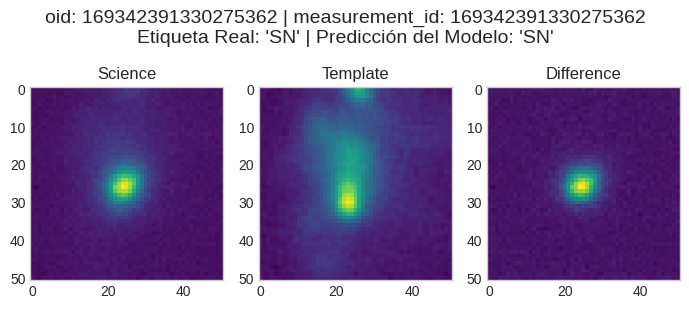

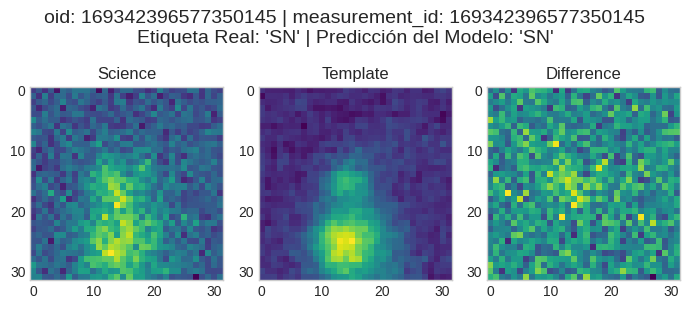

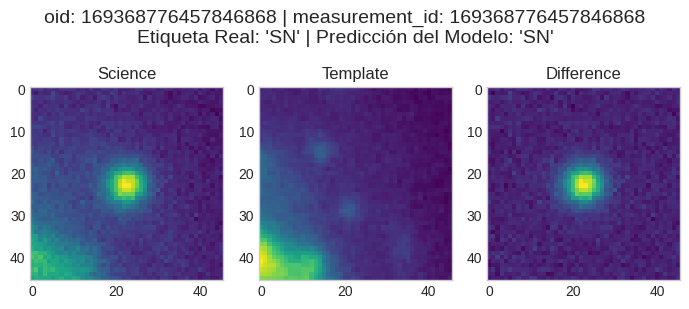

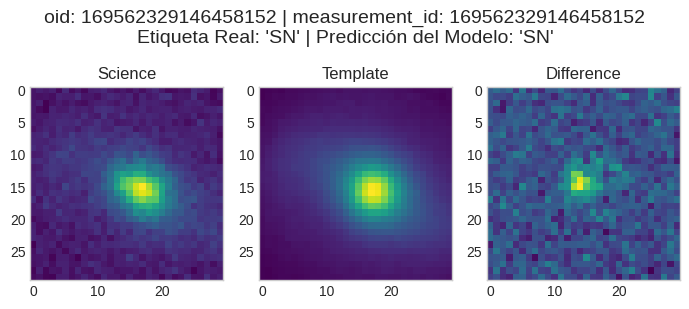

In [57]:
# Visualización para la PRECISIÓN
plot_stamps(
    predicted_as_sn, 
    "Análisis de Precisión: Objetos Predichos como Supernova"
)


--- Análisis de Recall: Supernovas Reales que el Modelo no Detectó ---
Mostrando 7 ejemplos.


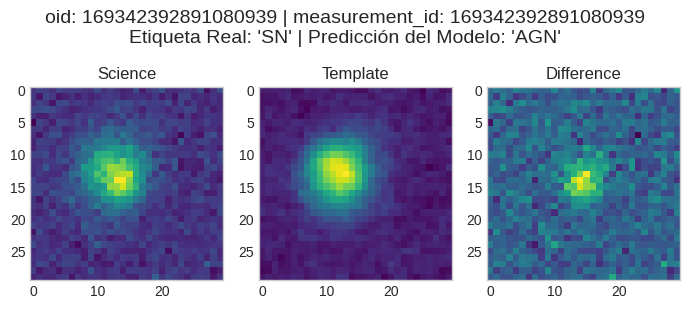

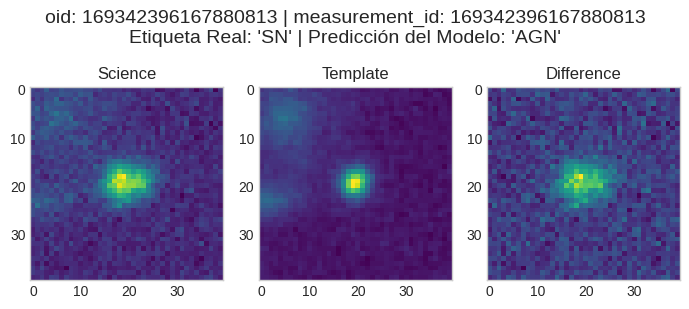

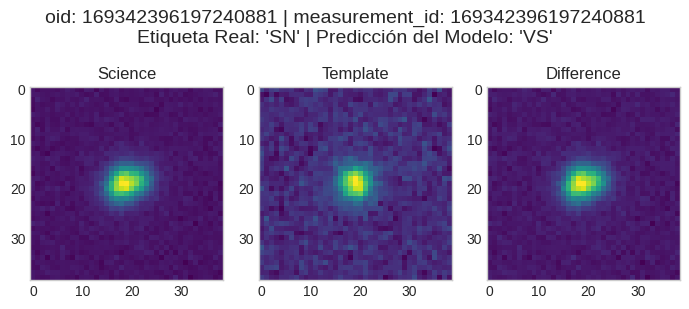

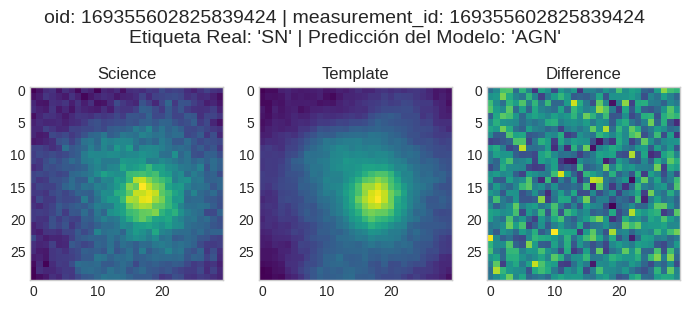

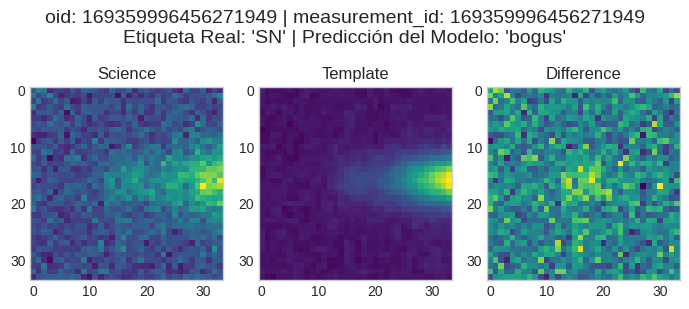

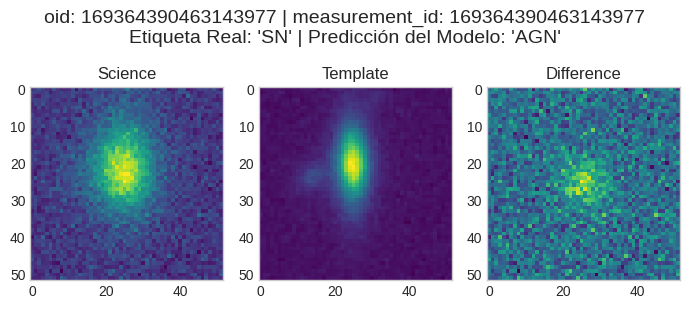

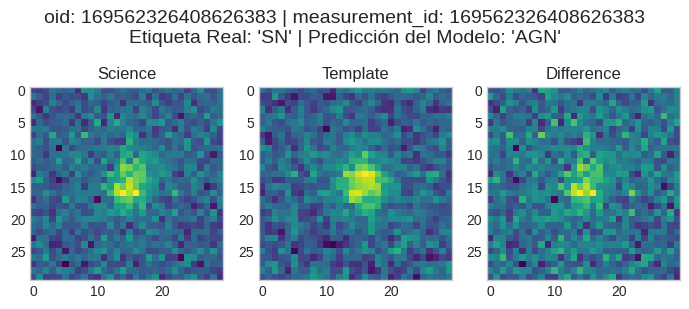

In [58]:
# Visualización para el RECALL
plot_stamps(
    missed_sn, 
    "Análisis de Recall: Supernovas Reales que el Modelo no Detectó"
)

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Asegúrate de que df_real_all_stamps esté definido con las columnas oid y measurement_id
# y que all_predictions sea una lista de DataFrames de predicciones.

# 1. Definir la carpeta base para guardar los plots
OUTPUT_DIR = 'mixed_reales_sinteticas_plots_por_fold_fforster'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 4. Función para Graficar (MODIFICADA para guardar) ---
def plot_stamps(df, title_prefix, output_folder, max_plots=5):
    """
    Itera sobre un DataFrame filtrado y grafica las estampillas
    guardándolas en la carpeta especificada.
    
    Args:
        df (pd.DataFrame): DataFrame con las estampillas.
        title_prefix (str): Prefijo del título para los logs.
        output_folder (str): Ruta de la carpeta donde guardar los plots.
        max_plots (int): Número máximo de plots a guardar para evitar sobrecarga.
    """
    if df.empty:
        print(f"No se encontraron ejemplos para: '{title_prefix}'")
        return

    print(f"\n--- {title_prefix} ---")
    num_to_plot = min(len(df), max_plots)
    print(f"Mostrando y guardando {num_to_plot} ejemplos de {len(df)} encontrados.")

    # Asegurarse de que la carpeta de salida exista
    os.makedirs(output_folder, exist_ok=True)
    
    # Solo graficar un número limitado de ejemplos
    for index, row in df.head(max_plots).iterrows():
        fig, axes = plt.subplots(1, 3, figsize=(7, 4))

        stamps_to_plot = {
            "Science": row['flux_Science_data'],
            "Template": row['flux_Template_data'],
            "Difference": row['flux_Difference_data']
        }
        
        # Iteramos para aplicar los cambios a cada subplot
        for i, (title, data) in enumerate(stamps_to_plot.items()):
            ax = axes[i]
            # Usamos 'viridis' si no hay otra información de cmap
            im = ax.imshow(data, cmap='viridis') 
            ax.set_title(title)
            
            ax.grid(False)
            #ax.set_xticks([])
            #ax.set_yticks([])

        true_label = row['true_label'].replace('/', '_')
        predicted_label = row['predicted_label'].replace('/', '_')
        
        main_title = (
            f"oid: {row['oid']} | measurement_id: {row['measurement_id']}\n"
            f"Etiqueta Real: '{true_label}' | Predicción del Modelo: '{predicted_label}'"
        )
        fig.suptitle(main_title, fontsize=14, y=0.87)
        
        plt.tight_layout()
        
        # --- Guardar el plot en la carpeta del fold ---
        
        # Generar un nombre de archivo descriptivo
        file_name_type = title_prefix.split(':')[0].replace(' ', '_').lower()
        file_name = (
            f"{file_name_type}_oid_{row['oid']}_mid_{row['measurement_id']}.png"
        )
        save_path = os.path.join(output_folder, file_name)
        
        plt.savefig(save_path)
        plt.close(fig) # Cierra la figura para liberar memoria
        print(f"Guardado: {save_path}")


# 2. Iterar sobre todos los folds
for fold_index, fold_predictions_df in enumerate(all_predictions):
    
    print(f"\n=======================================================")
    print(f"Procesando Fold {fold_index}")
    print(f"=======================================================")
    
    # 3. Crear la ruta de salida específica para este fold
    fold_output_folder = os.path.join(OUTPUT_DIR, f'fold_{fold_index}')
    os.makedirs(fold_output_folder, exist_ok=True)

    # 4. Combinar datos del fold con las estampillas
    merged_df = pd.merge(fold_predictions_df, df_real_all_stamps, on=['oid', 'measurement_id'])

    # A) PRECISION: Objetos predichos como Supernova ('SN')
    predicted_as_sn = merged_df[merged_df['predicted_label'] == 'SN'].copy()

    # B) RECALL: Objetos que eran Supernova ('SN') pero el modelo falló (Falsos Negativos)
    missed_sn = merged_df[(merged_df['true_label'] == 'SN') & (merged_df['predicted_label'] != 'SN')].copy()

    
    # 5. Visualización para la PRECISIÓN (True Positives + False Positives)
    # Guardamos los ejemplos de los objetos predichos como SN
    plot_stamps(
        predicted_as_sn, 
        "Precision: Objetos Predichos como Supernova",
        fold_output_folder
    )

    # 6. Visualización para el RECALL (False Negatives)
    # Guardamos los ejemplos de las Supernovas que el modelo falló
    plot_stamps(
        missed_sn, 
        "Recall: Supernovas Reales que el Modelo no Detectó",
        fold_output_folder
    )

print("\nProceso de guardado completado.")


Procesando Fold 0

--- Precision: Objetos Predichos como Supernova ---
Mostrando y guardando 4 ejemplos de 4 encontrados.
Guardado: mixed_reales_sinteticas_plots_por_fold_fforster/fold_0/precision_oid_169342391330275362_mid_169342391330275362.png
Guardado: mixed_reales_sinteticas_plots_por_fold_fforster/fold_0/precision_oid_169342396577350145_mid_169342396577350145.png
Guardado: mixed_reales_sinteticas_plots_por_fold_fforster/fold_0/precision_oid_169368776457846868_mid_169368776457846868.png
Guardado: mixed_reales_sinteticas_plots_por_fold_fforster/fold_0/precision_oid_169562329146458152_mid_169562329146458152.png

--- Recall: Supernovas Reales que el Modelo no Detectó ---
Mostrando y guardando 5 ejemplos de 7 encontrados.
Guardado: mixed_reales_sinteticas_plots_por_fold_fforster/fold_0/recall_oid_169342392891080939_mid_169342392891080939.png
Guardado: mixed_reales_sinteticas_plots_por_fold_fforster/fold_0/recall_oid_169342396167880813_mid_169342396167880813.png
Guardado: mixed_reales

In [74]:
synthetic_total_SN = pd.read_pickle('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/ts_stamps_v0.0.2_fforster/SN_fakes.pkl')
synthetic_total_SN

,oid,partition,gal_objectId,band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,...,level3_image,level3_header,level4_image,level4_header,ra,dec,mjd,dataset_origin,oid_kept,measurement_id
0,fakes_20251221_0,train_0,609780764988422794,g,2024120900332,6,592913981740417050,g,2024120200081,7,...,"[[0.004197153, 0.0049062795, 0.006688803, 0.00...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004197153, 0.0049062795, 0.006688803, 0.00...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_0,fakes_20251221_0
1,fakes_20251221_1,train_0,609780764988422794,g,2024120900332,6,592913981740417050,g,2024120200085,5,...,"[[0.004545113, 0.0029715837, 0.0034701652, 0.0...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.004545113, 0.0029715837, 0.0034701652, 0.0...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_1,fakes_20251221_1
2,fakes_20251221_2,train_0,609780764988422794,g,2024120900332,6,611253835691723482,g,2024120100148,8,...,"[[0.015448976, 0.018849885, 0.019384798, 0.020...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.015448976, 0.018849885, 0.019384798, 0.020...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_2,fakes_20251221_2
3,fakes_20251221_3,train_0,609780764988422794,g,2024120900332,6,611255003922831024,g,2024112900281,5,...,"[[0.0056003085, 0.0057230457, 0.0040046386, 0....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.0056003085, 0.0057230457, 0.0040046386, 0....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_3,fakes_20251221_3
4,fakes_20251221_4,train_0,609780764988422794,g,2024120900332,6,614431080698610905,g,2024120200340,2,...,"[[0.014220125, 0.017140526, 0.018778317, 0.024...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.014220125, 0.017140526, 0.018778317, 0.024...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_4,fakes_20251221_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21619,fakes_20251221_21619,val_4,611256584470808273,z,2024120900327,2,612928529339777217,z,2024120700486,6,...,"[[0.01469231, 0.01491529, 0.015217164, 0.01418...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.01469231, 0.01491529, 0.015217164, 0.01418...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_21619,fakes_20251221_21619
21620,fakes_20251221_21620,val_4,611256584470808273,z,2024120900327,2,612928529339777217,z,2024120700486,6,...,"[[0.2327445, 0.30431864, 0.38795543, 0.4593497...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.2327445, 0.30431864, 0.38795543, 0.4593497...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_21620,fakes_20251221_21620
21621,fakes_20251221_21621,val_4,611256584470808273,z,2024120900327,2,612928529339777217,z,2024120700486,6,...,"[[0.017744984, 0.019678714, 0.021442503, 0.022...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.017744984, 0.019678714, 0.021442503, 0.022...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_21621,fakes_20251221_21621
21622,fakes_20251221_21622,val_4,611256584470808273,z,2024120900327,2,612928529339777217,z,2024120700486,6,...,"[[0.014848061, 0.016738113, 0.016622182, 0.017...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...","[[0.014848061, 0.016738113, 0.016622182, 0.017...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, WCSAXE...",NaN,NaN,NaN,synthetic,fakes_20251221_21622,fakes_20251221_21622


In [65]:
#df_diff = pd.read_csv('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/simulated_data/fakes/df_diff.csv')
#df_diff.columns

In [66]:
#df_diff

In [67]:
#df_gal = pd.read_csv('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/simulated_data/fakes/df_gal.csv')
#df_gal.columns

In [68]:
#df_gal

In [69]:
all_predictions_sim[2]

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
1790,fakes_20251221_19542,fakes_20251221_19542,1,1,SN,SN,0.999110,0.000075,0.999110,0.000039,0.000397,0.000380
1791,fakes_20251221_19543,fakes_20251221_19543,1,1,SN,SN,0.999172,0.000182,0.999172,0.000064,0.000213,0.000370
1792,fakes_20251221_19544,fakes_20251221_19544,1,1,SN,SN,0.998278,0.000070,0.998278,0.000053,0.001254,0.000345
1793,fakes_20251221_19545,fakes_20251221_19545,1,1,SN,SN,0.998440,0.000082,0.998440,0.000052,0.000985,0.000441
1794,fakes_20251221_19546,fakes_20251221_19546,1,1,SN,SN,0.999096,0.000099,0.999096,0.000045,0.000339,0.000421
...,...,...,...,...,...,...,...,...,...,...,...,...
2584,fakes_20251221_20336,fakes_20251221_20336,1,1,SN,SN,0.978047,0.010927,0.978047,0.002053,0.000824,0.008148
2585,fakes_20251221_20337,fakes_20251221_20337,1,1,SN,SN,0.774287,0.184536,0.774287,0.037548,0.001310,0.002320
2586,fakes_20251221_20338,fakes_20251221_20338,1,1,SN,SN,0.966942,0.016041,0.966942,0.003538,0.001320,0.012158
2587,fakes_20251221_20339,fakes_20251221_20339,1,1,SN,SN,0.970401,0.002207,0.970401,0.001009,0.013470,0.012912


Iniciando cálculo de Matrices de Confusión para datos SIMULADOS...

Calculando CM Promedio a partir de 5 folds SIMULADOS.


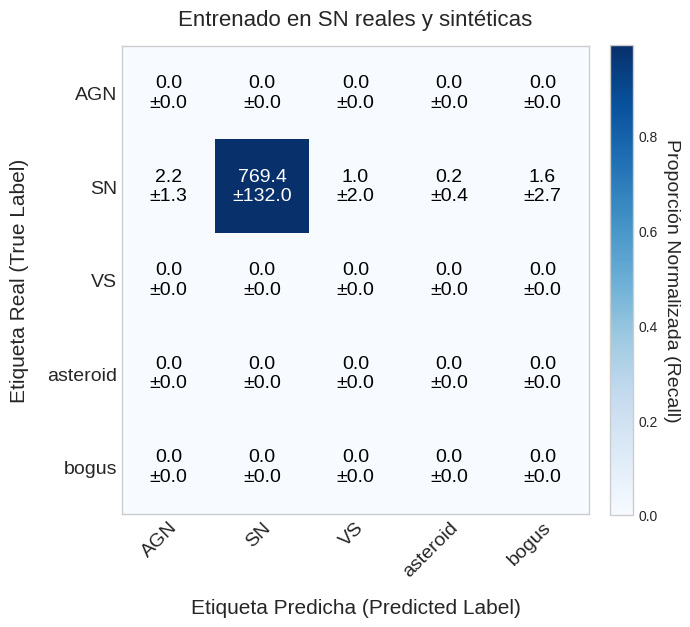

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Datos proporcionados (Asegúrate de que estas variables estén disponibles)
class_map = {
    0: "AGN",
    1: "SN",
    2: "VS",
    3: "asteroid",
    4: "bogus"
}
# La variable all_predictions_sim debe contener la lista de DataFrames simulados por fold.
# Ejemplo: all_predictions_sim = [df_fold_0, df_fold_1, ...]

# 2. Definir las etiquetas en el orden deseado
LABELS = [class_map[i] for i in sorted(class_map.keys())]
N_CLASSES = len(LABELS)


# 3. Función de Ploteo de Matriz de Confusión (Formato Mixto - SIN CUADRÍCULAS)
def plot_mixed_confusion_matrix(mean_text, std_text, mean_color, class_names, 
                                figsize=(7, 7), cmap='Blues', title='Matriz de Confusión Promedio (Datos Simulados)'):
    """
    Grafica una matriz de confusión con el formato deseado (texto μ ± σ y color normalizado),
    eliminando las cuadrículas interiores y ajustando el estilo.
    """
    N_CLASSES = len(class_names)
    fig, ax = plt.subplots(figsize=figsize)
    
    # 1. Usar la matriz NORMALIZADA (mean_color) para generar el heatmap (los colores)
    im = ax.imshow(mean_color, interpolation='nearest', cmap=cmap)

    # 2. Añadir la barra de color basada en la matriz NORMALIZADA
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proporción Normalizada (Recall)", rotation=-90, va="bottom", size=14)
    cbar.ax.tick_params(labelsize=10)

    # 3. Iterar y añadir el texto (μ ± σ)
    threshold = mean_color.max() / 2.
    
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            # Recuentos absolutos con un decimal
            text_val = f"{mean_text[i, j]:.1f}\n±{std_text[i, j]:.1f}"
            text_color = "white" if mean_color[i, j] > threshold else "black"
            
            ax.text(j, i, text_val, ha="center", va="center", color=text_color, fontsize=14)

    # --- Estilo y etiquetas ---
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xticks(np.arange(N_CLASSES))
    ax.set_yticks(np.arange(N_CLASSES))
    
    ax.set_xticklabels(class_names, fontsize=14)
    ax.set_yticklabels(class_names, fontsize=14)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    ax.set_ylabel('Etiqueta Real (True Label)', fontsize=15)
    ax.set_xlabel('Etiqueta Predicha (Predicted Label)', fontsize=15)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    # ELIMINAR CUADRÍCULAS/BORDES
    ax.tick_params(which='both', width=0)
    ax.grid(False)

    fig.tight_layout()
    plt.show()


# 4. CALCULAR MATRICES DE CONFUSIÓN SOLO PARA DATOS SIMULADOS
simulated_cms = []

print("Iniciando cálculo de Matrices de Confusión para datos SIMULADOS...")

for fold_index, fold_df in enumerate(all_predictions_sim):
    
    y_true = fold_df['true_label']
    y_pred = fold_df['predicted_label']
    
    if len(y_true) == 0:
        print(f"Advertencia: No hay datos en el Fold {fold_index} simulado. Saltando.")
        continue

    # Calculamos la Matriz de Confusión Absoluta
    try:
        cm_abs = confusion_matrix(y_true, y_pred, labels=LABELS)
        simulated_cms.append(cm_abs)
    except ValueError as e:
        print(f"Error al calcular CM en Fold {fold_index} simulado: {e}")
        continue

# 5. AGREGACIÓN Y GRÁFICO
if not simulated_cms:
    print("No se pudo calcular ninguna matriz de confusión a partir de all_predictions_sim.")
else:
    
    # 5.1 Agregación de Resultados (Media y Desviación Estándar)
    all_cm_array = np.array(simulated_cms)
    
    # Media y Desviación Estándar de recuentos ABSOLUTOS
    mean_cm = np.mean(all_cm_array, axis=0)
    std_cm = np.std(all_cm_array, axis=0)
    
    print("\n" + "="*50)
    print(f"Calculando CM Promedio a partir de {len(simulated_cms)} folds SIMULADOS.")
    print("="*50)

    # 5.2 Normalización (para los COLORES)
    row_sums = mean_cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1 
    mean_cm_norm = mean_cm / row_sums

    # 5.3 Graficar la Matriz de Confusión Mixta
    plot_mixed_confusion_matrix(
        mean_text=mean_cm,
        std_text=std_cm,
        mean_color=mean_cm_norm,
        class_names=LABELS,
        title='Entrenado en SN reales y sintéticas'
    )

/tmp/ipykernel_3114677/2001131735.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_radius = plot_data_radius.groupby('radius_bin')['is_correct'].agg(['mean', 'std', 'count']).reset_index()
/tmp/ipykernel_3114677/2001131735.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_radius = sns.barplot(


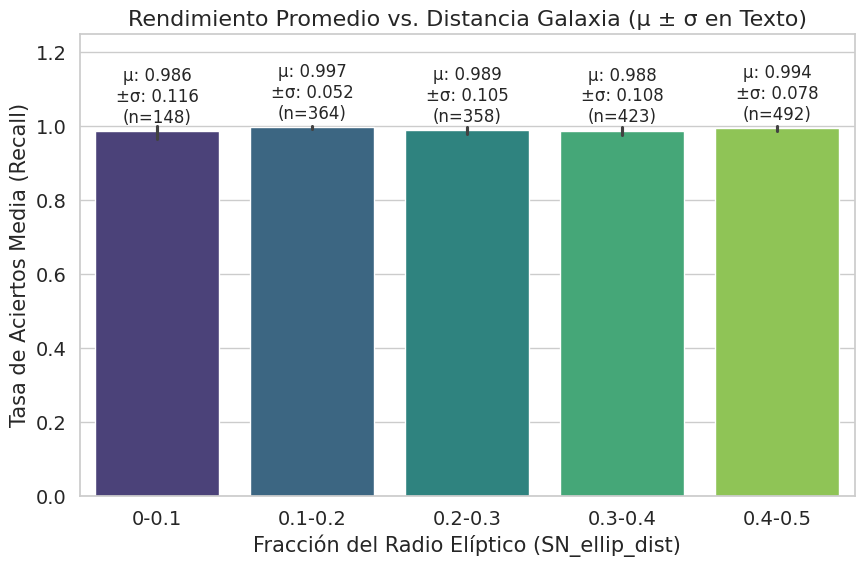

/tmp/ipykernel_3114677/2001131735.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_band = sns.barplot(


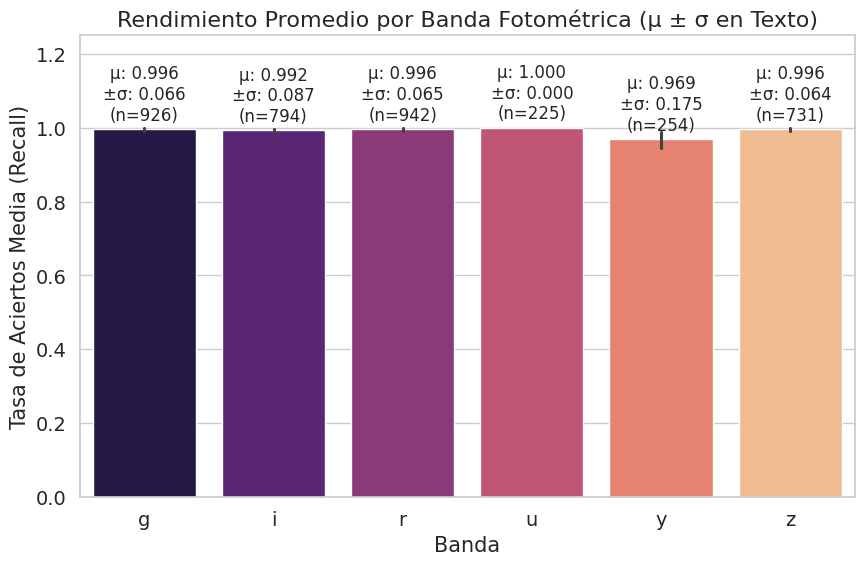

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración inicial
sns.set_theme(style="whitegrid")

# --- 1. CONCATENAR PREDICCIONES DE TODOS LOS FOLDS ---
if not isinstance(all_predictions_sim, list) or not all_predictions_sim:
    print("Error: 'all_predictions_sim' debe ser una lista de DataFrames no vacía.")
    exit()
    
all_sim_predictions_df = pd.concat(all_predictions_sim, ignore_index=True)

# --- 2. MERGEAR CON METADATOS SIMULADOS ---
# Asumimos que synthetic_total_SN tiene las columnas necesarias
merged_sim_df = pd.merge(
    all_sim_predictions_df,
    synthetic_total_SN,
    left_on='measurement_id',
    right_on='oid',
    how='inner'
)

# Preparación de la variable de acierto
merged_sim_df['is_correct'] = (merged_sim_df['predicted_label'] == 'SN').astype(int)


# --- FUNCIÓN AUXILIAR PARA ANOTAR MEDIA Y STD ---
def annotate_mu_sigma(ax, stats_df, x_col, order=None):
    """
    Añade anotaciones de Media (μ) ± Desviación Estándar (σ) a un barplot.
    """
    
    # Asegurar el orden del DataFrame de estadísticas
    if order is not None:
        stats_df = stats_df.set_index(x_col).loc[order].reset_index()

    for i, p in enumerate(ax.patches):
        if i < len(stats_df):
            mu = stats_df.iloc[i]['mean']
            sigma = stats_df.iloc[i]['std']
            n = stats_df.iloc[i]['count']
            
            # Formato de texto: Media ± Std (en proporción) y n
            text_annotation = f'μ: {mu:.3f}\n±σ: {sigma:.3f}\n(n={n})'
            
            # El texto se coloca en la parte superior de la barra
            ax.annotate(
                text_annotation,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 25), # Pequeño desplazamiento hacia arriba
                textcoords='offset points',
                fontsize=12
            )


# =========================================================================
# A) GRÁFICO 1: ANÁLISIS por FRACCIÓN de RADIO (Solo Texto μ ± σ)
# =========================================================================

radius_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
radius_labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5']

merged_sim_df['radius_bin'] = pd.cut(
    merged_sim_df['SN_ellip_dist'],
    bins=radius_bins,
    labels=radius_labels,
    right=True,
    include_lowest=True
)

plot_data_radius = merged_sim_df.dropna(subset=['radius_bin'])

# Calcular estadísticas para el texto
stats_radius = plot_data_radius.groupby('radius_bin')['is_correct'].agg(['mean', 'std', 'count']).reset_index()

plt.figure(figsize=(10, 6))
ax_radius = sns.barplot(
    data=plot_data_radius,
    x='radius_bin',
    y='is_correct',
    palette='viridis',
    # !!! SIN errorbar: solo la media se grafica
    order=radius_labels
)

ax_radius.tick_params(axis='both', which='major', labelsize=14) # Aumentado a 12

# Añadir etiquetas de Media ± Std
annotate_mu_sigma(ax_radius, stats_radius, 'radius_bin', order=radius_labels)

plt.title('Rendimiento Promedio vs. Distancia Galaxia (μ ± σ en Texto)', fontsize=16)
plt.xlabel('Fracción del Radio Elíptico (SN_ellip_dist)', fontsize=15)
plt.ylabel('Tasa de Aciertos Media (Recall)', fontsize=15)
plt.ylim(0, 1.25)
plt.show()


# =========================================================================
# B) GRÁFICO 2: ANÁLISIS por BANDA FOTOMÉTRICA (Solo Texto μ ± σ)
# =========================================================================

band_order = sorted(merged_sim_df['band'].unique())

# Calcular estadísticas para el texto
stats_band = merged_sim_df.groupby('band')['is_correct'].agg(['mean', 'std', 'count']).reset_index()

plt.figure(figsize=(10, 6))
ax_band = sns.barplot(
    data=merged_sim_df,
    x='band',
    y='is_correct',
    palette='magma',
    # !!! SIN errorbar: solo la media se grafica
    order=band_order
)

ax_band.tick_params(axis='both', which='major', labelsize=14) # Aumentado a 12

# Añadir etiquetas de Media ± Std
annotate_mu_sigma(ax_band, stats_band, 'band', order=band_order)

plt.title('Rendimiento Promedio por Banda Fotométrica (μ ± σ en Texto)', fontsize=16)
plt.xlabel('Banda', fontsize=15)
plt.ylabel('Tasa de Aciertos Media (Recall)', fontsize=15)
plt.ylim(0, 1.25)
plt.show()

<Axes: >

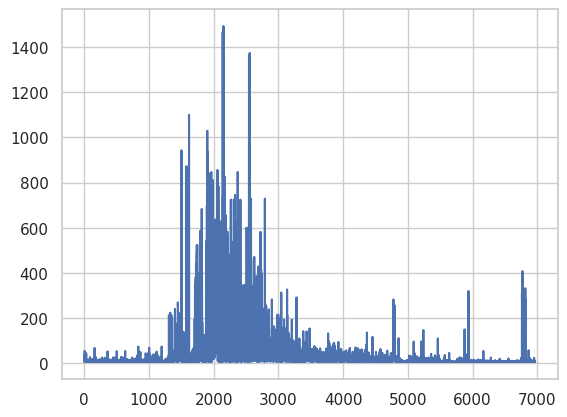

In [42]:
objects_metadata.snr.plot()

In [43]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# --- CONFIGURACIÓN ---
TARGET_CLASS = 'SN'       # La clase que quieres evaluar
SNR_BINS = [0, 5, 10, 15, 20, 30, 50, 1000] # Definimos los cortes de los bins
# Etiquetas para los gráficos (excluyendo el último borde para visualización)
bin_labels = [f'{SNR_BINS[i]}-{SNR_BINS[i+1]}' for i in range(len(SNR_BINS)-1)]
bin_centers = [(SNR_BINS[i] + SNR_BINS[i+1])/2 for i in range(len(SNR_BINS)-1)]
# Ajuste visual para el último bin que es muy grande (50-1000)
bin_centers[-1] = 60 

# Estructura para guardar resultados: diccionario de listas (una lista por fold)
snr_metrics = {
    'precision': {k: [] for k in bin_labels},
    'recall': {k: [] for k in bin_labels},
    'f1': {k: [] for k in bin_labels},
    'count': {k: [] for k in bin_labels} # Para saber cuántos objetos cayeron en el bin
}

# Asegúrate de que measurement_id sea del mismo tipo en ambos lados para el merge
# (A veces pandas carga uno como int y otro como string u object)
objects_metadata['measurement_id'] = objects_metadata['measurement_id'].astype(str)

print(f"Procesando métricas vs SNR para {len(all_predictions)} folds...")

for i, df_fold in enumerate(all_predictions):
    # 1. Preparar el dataframe del fold
    df_fold = df_fold.copy()
    df_fold['measurement_id'] = df_fold['measurement_id'].astype(str)
    
    # 2. Merge con metadata para traer el SNR
    # Usamos 'inner' para asegurarnos de evaluar solo lo que tiene metadata, 
    # o 'left' si confías en que todas las predicciones tienen metadata.
    merged_df = pd.merge(df_fold, objects_metadata[['measurement_id', 'snr']], on='measurement_id', how='inner')
    
    if merged_df.empty:
        print(f"Advertencia: El fold {i} quedó vacío tras el merge. Revisa los IDs.")
        continue

    # 3. Crear los bins de SNR
    merged_df['snr_bin'] = pd.cut(merged_df['snr'], bins=SNR_BINS, labels=bin_labels, include_lowest=True)
    
    # 4. Calcular métricas por cada bin
    for bin_label in bin_labels:
        # Filtrar datos del bin actual
        subset = merged_df[merged_df['snr_bin'] == bin_label]
        
        if len(subset) == 0:
            # Si no hay datos en este rango para este fold, guardamos NaN
            snr_metrics['precision'][bin_label].append(np.nan)
            snr_metrics['recall'][bin_label].append(np.nan)
            snr_metrics['f1'][bin_label].append(np.nan)
            snr_metrics['count'][bin_label].append(0)
            continue
            
        # Calcular True Positives, False Positives, False Negatives para la clase TARGET
        y_true = subset['true_label']
        y_pred = subset['predicted_label']
        
        # Opción A: Usar sklearn (más lento pero estándar)
        # precision, recall, f1, _ = precision_recall_fscore_support(
        #     y_true, y_pred, labels=[TARGET_CLASS], average=None, zero_division=0
        # )
        # p, r, f = precision[0], recall[0], f1[0]
        
        # Opción B: Cálculo manual (más rápido y transparente para binarios/multiclase 1vsAll)
        TP = ((y_true == TARGET_CLASS) & (y_pred == TARGET_CLASS)).sum()
        FP = ((y_true != TARGET_CLASS) & (y_pred == TARGET_CLASS)).sum()
        FN = ((y_true == TARGET_CLASS) & (y_pred != TARGET_CLASS)).sum()
        
        p = TP / (TP + FP) if (TP + FP) > 0 else 0
        r = TP / (TP + FN) if (TP + FN) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
        
        snr_metrics['precision'][bin_label].append(p)
        snr_metrics['recall'][bin_label].append(r)
        snr_metrics['f1'][bin_label].append(f)
        snr_metrics['count'][bin_label].append(len(subset))

print("Cálculo finalizado.")

Procesando métricas vs SNR para 5 folds...
Cálculo finalizado.


In [44]:
# Función auxiliar para agregar
def aggregate_metrics(metric_dict):
    means = []
    stds = []
    for bin_label in bin_labels:
        values = np.array(metric_dict[bin_label])
        # Usamos nanmean/nanstd para ignorar folds vacíos en un bin específico
        means.append(np.nanmean(values))
        stds.append(np.nanstd(values))
    return np.array(means), np.array(stds)

prec_mean, prec_std = aggregate_metrics(snr_metrics['precision'])
rec_mean, rec_std = aggregate_metrics(snr_metrics['recall'])
f1_mean, f1_std = aggregate_metrics(snr_metrics['f1'])

# Contar cuántos objetos SN REALES hay en promedio por bin (para contexto)
# Nota: el conteo anterior era de todos los objetos, aquí es útil saber cuántas SN hay
counts_mean, _ = aggregate_metrics(snr_metrics['count'])

/tmp/ipykernel_3015231/2160190467.py:8: RuntimeWarning: Mean of empty slice
  means.append(np.nanmean(values))
/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


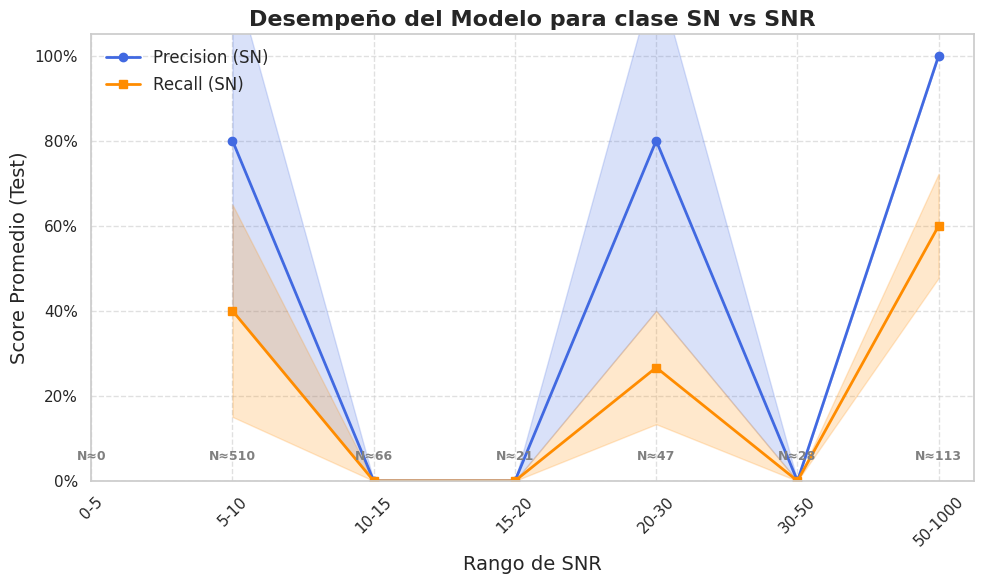

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 6))

# Usamos índices numéricos para el eje X para que los bins queden equidistantes
# (Si usas los valores reales de SNR, los bins pequeños se aplastan a la izquierda)
x_indices = np.arange(len(bin_labels))

# --- GRÁFICO DE LÍNEAS (Métricas) ---
# Precisión
ax.plot(x_indices, prec_mean, marker='o', label=f'Precision ({TARGET_CLASS})', color='royalblue', lw=2)
ax.fill_between(x_indices, prec_mean - prec_std, prec_mean + prec_std, color='royalblue', alpha=0.2)

# Recall
ax.plot(x_indices, rec_mean, marker='s', label=f'Recall ({TARGET_CLASS})', color='darkorange', lw=2)
ax.fill_between(x_indices, rec_mean - rec_std, rec_mean + rec_std, color='darkorange', alpha=0.2)

# F1 (Opcional, descomentar si quieres verla)
# ax.plot(x_indices, f1_mean, marker='^', label='F1-Score', color='green', ls='--', alpha=0.7)

# --- ESTÉTICA ---
ax.set_title(f'Desempeño del Modelo para clase {TARGET_CLASS} vs SNR', fontsize=16, weight='bold')
ax.set_xlabel('Rango de SNR', fontsize=14)
ax.set_ylabel('Score Promedio (Test)', fontsize=14)
ax.set_ylim(0, 1.05)

# Configurar el eje X con las etiquetas de los bins
ax.set_xticks(x_indices)
ax.set_xticklabels(bin_labels, rotation=45)

ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

# --- (Opcional) TEXTO CON CANTIDAD DE DATOS ---
# Poner arriba de cada punto cuántos objetos aprox hay en ese bin
for i, count in enumerate(counts_mean):
    ax.text(i, 0.05, f'N≈{int(count)}', ha='center', fontsize=9, color='gray', fontweight='bold')

plt.tight_layout()
plt.show()

In [46]:
df_fold[df_fold.predicted_label == 'SN'].shape

(5, 12)

In [47]:
df_fold[df_fold.true_label == 'SN'].shape

(11, 12)

In [49]:
df_fold

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
0,169298437874909259,169298437874909259,0,0,AGN,AGN,0.909892,0.909892,0.031338,0.025100,0.000203,0.033467
1,169302853217681420,169302853217681420,0,4,AGN,bogus,0.619632,0.037713,0.000481,0.341328,0.000846,0.619632
2,169302854308200461,169302854308200461,0,0,AGN,AGN,0.786920,0.786920,0.007114,0.084929,0.002536,0.118501
3,169302854846644615,169302854846644615,0,0,AGN,AGN,0.892084,0.892084,0.010723,0.035633,0.004053,0.057507
4,169342390655516782,169342390655516782,0,0,AGN,AGN,0.460880,0.460880,0.002680,0.155986,0.001660,0.378793
...,...,...,...,...,...,...,...,...,...,...,...,...
780,169615071701368858,169615071701368858,4,4,bogus,bogus,0.750172,0.109365,0.000671,0.136389,0.003402,0.750172
781,169615109554962465,169615109554962465,4,4,bogus,bogus,0.538124,0.295315,0.002737,0.161656,0.002169,0.538124
782,169615110372851739,169615110372851739,4,3,bogus,asteroid,0.559105,0.007542,0.111306,0.003827,0.559105,0.318220
783,169623885920600163,169623885920600163,4,4,bogus,bogus,0.660667,0.139041,0.001442,0.197874,0.000976,0.660667


Generando métricas (P, R, F1) para 30 rangos de SNR...


/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: Run

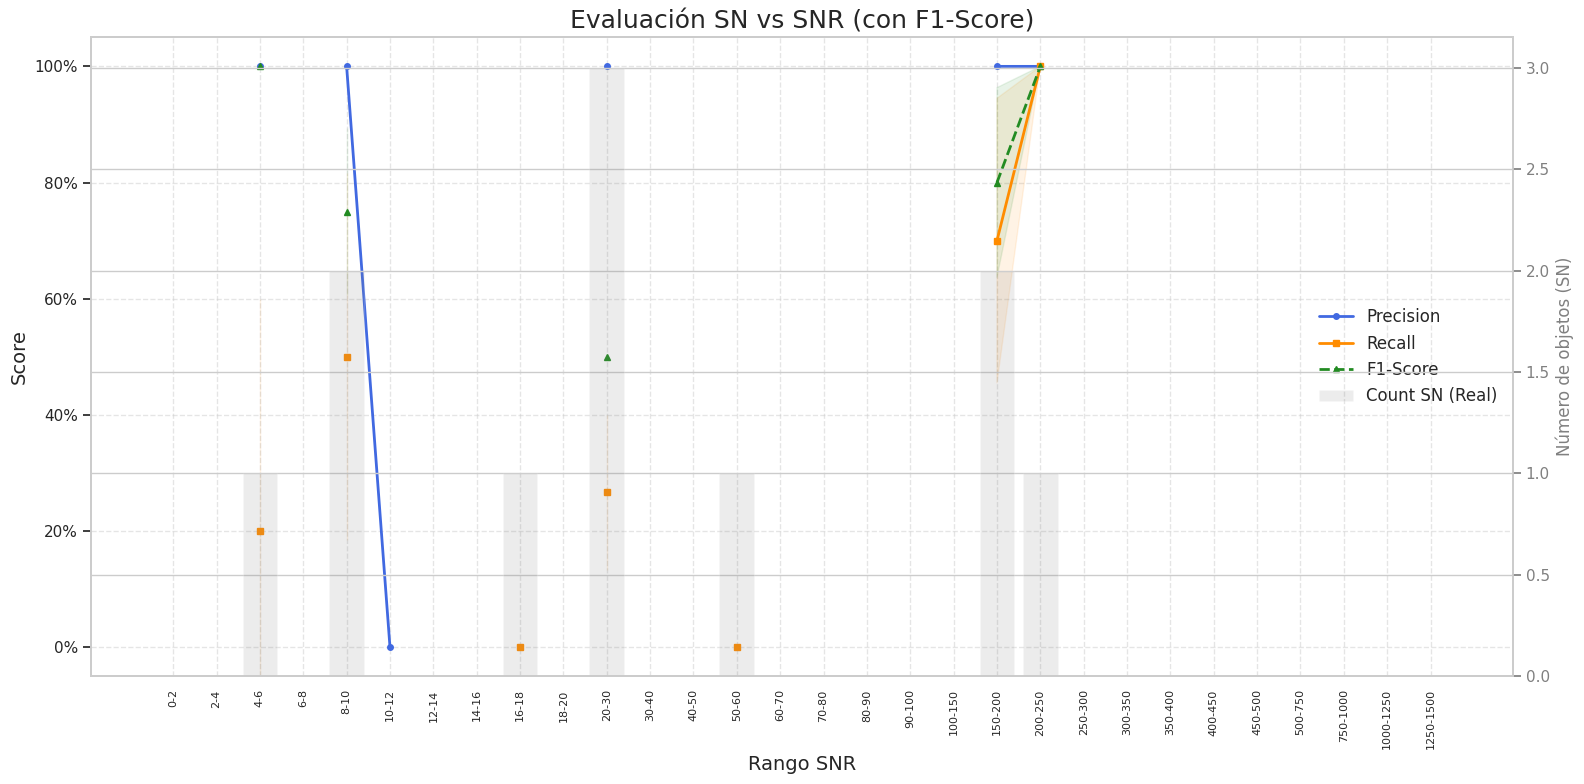

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings # <--- SOLUCIÓN AL ERROR: Usamos la librería estándar

# --- 1. DEFINICIÓN DE BINS HASTA 1500 ---
bins_micro = np.arange(0, 20, 2)       # 0, 2... 18
bins_low   = np.arange(20, 100, 10)    # 20, 30... 90
bins_mid   = np.arange(100, 500, 50)   # 100, 150... 450
bins_high  = np.arange(500, 1501, 250) # 500, 750... 1500

SNR_BINS = np.concatenate([bins_micro, bins_low, bins_mid, bins_high])
bin_labels = [f'{int(SNR_BINS[i])}-{int(SNR_BINS[i+1])}' for i in range(len(SNR_BINS)-1)]

# --- 2. CONFIGURACIÓN ---
TARGET_CLASS = 'SN' 
snr_metrics = {
    'precision': {k: [] for k in bin_labels},
    'recall':    {k: [] for k in bin_labels},
    'f1':        {k: [] for k in bin_labels}, # <--- Agregamos F1
    'count':     {k: [] for k in bin_labels}
}

objects_metadata['measurement_id'] = objects_metadata['measurement_id'].astype(str)

print(f"Generando métricas (P, R, F1) para {len(bin_labels)} rangos de SNR...")

# --- 3. PROCESAMIENTO ---
for i, df_fold in enumerate(all_predictions):
    df_fold = df_fold.copy()
    df_fold['measurement_id'] = df_fold['measurement_id'].astype(str)
    
    merged_df = pd.merge(df_fold, objects_metadata[['measurement_id', 'snr']], on='measurement_id', how='inner')
    
    if merged_df.empty: continue

    merged_df['snr_bin'] = pd.cut(merged_df['snr'], bins=SNR_BINS, labels=bin_labels, include_lowest=True)
    
    for bin_label in bin_labels:
        subset = merged_df[merged_df['snr_bin'] == bin_label]
        n_true_sn = len(subset[subset['true_label'] == TARGET_CLASS])
        
        if len(subset) == 0:
            snr_metrics['precision'][bin_label].append(np.nan)
            snr_metrics['recall'][bin_label].append(np.nan)
            snr_metrics['f1'][bin_label].append(np.nan)
            snr_metrics['count'][bin_label].append(0)
            continue
            
        TP = ((subset['true_label'] == TARGET_CLASS) & (subset['predicted_label'] == TARGET_CLASS)).sum()
        FP = ((subset['true_label'] != TARGET_CLASS) & (subset['predicted_label'] == TARGET_CLASS)).sum()
        FN = ((subset['true_label'] == TARGET_CLASS) & (subset['predicted_label'] != TARGET_CLASS)).sum()
        
        # Precision
        denom_p = TP + FP
        p = TP / denom_p if denom_p > 0 else np.nan 
        
        # Recall
        denom_r = TP + FN
        r = TP / denom_r if denom_r > 0 else np.nan 

        # F1-Score
        # Si p o r son NaN, F1 es NaN. Si p+r es 0, F1 es 0.
        if np.isnan(p) or np.isnan(r):
            f1 = np.nan
        elif (p + r) == 0:
            f1 = 0.0
        else:
            f1 = 2 * (p * r) / (p + r)

        snr_metrics['precision'][bin_label].append(p)
        snr_metrics['recall'][bin_label].append(r)
        snr_metrics['f1'][bin_label].append(f1)
        snr_metrics['count'][bin_label].append(n_true_sn)

# --- 4. AGREGACIÓN (FIXED) ---
def aggregate(metric_dict):
    means, stds = [], []
    for lbl in bin_labels:
        vals = np.array(metric_dict[lbl], dtype=float)
        
        # --- FIX: Usamos 'warnings' nativo en vez de np.warnings ---
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', r'Mean of empty slice')
            # Si todos los valores son NaN (ningún fold tuvo datos en ese bin), retorna NaN
            means.append(np.nanmean(vals))
            stds.append(np.nanstd(vals))
            
    return np.array(means), np.array(stds)

prec_m, prec_s = aggregate(snr_metrics['precision'])
rec_m, rec_s   = aggregate(snr_metrics['recall'])
f1_m, f1_s     = aggregate(snr_metrics['f1']) # Agregamos F1
counts_m, _    = aggregate(snr_metrics['count'])

# --- 5. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(bin_labels))

# Precision
ax.plot(x, prec_m, label='Precision', color='royalblue', lw=2, marker='o', markersize=4)
ax.fill_between(x, prec_m - prec_s, prec_m + prec_s, color='royalblue', alpha=0.1)

# Recall
ax.plot(x, rec_m, label='Recall', color='darkorange', lw=2, marker='s', markersize=4)
ax.fill_between(x, rec_m - rec_s, rec_m + rec_s, color='darkorange', alpha=0.1)

# F1-Score (Nueva línea)
ax.plot(x, f1_m, label='F1-Score', color='forestgreen', lw=2, marker='^', markersize=4, ls='--')
ax.fill_between(x, f1_m - f1_s, f1_m + f1_s, color='forestgreen', alpha=0.1)

# Histograma de fondo
ax2 = ax.twinx()
ax2.bar(x, counts_m, color='gray', alpha=0.15, label='Count SN (Real)')
ax2.set_ylabel('Número de objetos (SN)', fontsize=12, color='gray')
ax2.tick_params(axis='y', colors='gray')

# Estética
ax.set_title(f'Evaluación {TARGET_CLASS} vs SNR (con F1-Score)', fontsize=18)
ax.set_xlabel('Rango SNR', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=90, fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.grid(True, linestyle='--', alpha=0.5)

# Leyenda unificada
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
# Ordenamos para que F1 quede junto a las métricas
ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=12)

plt.tight_layout()
plt.show()

Extrayendo puntos individuales (sin bins)...


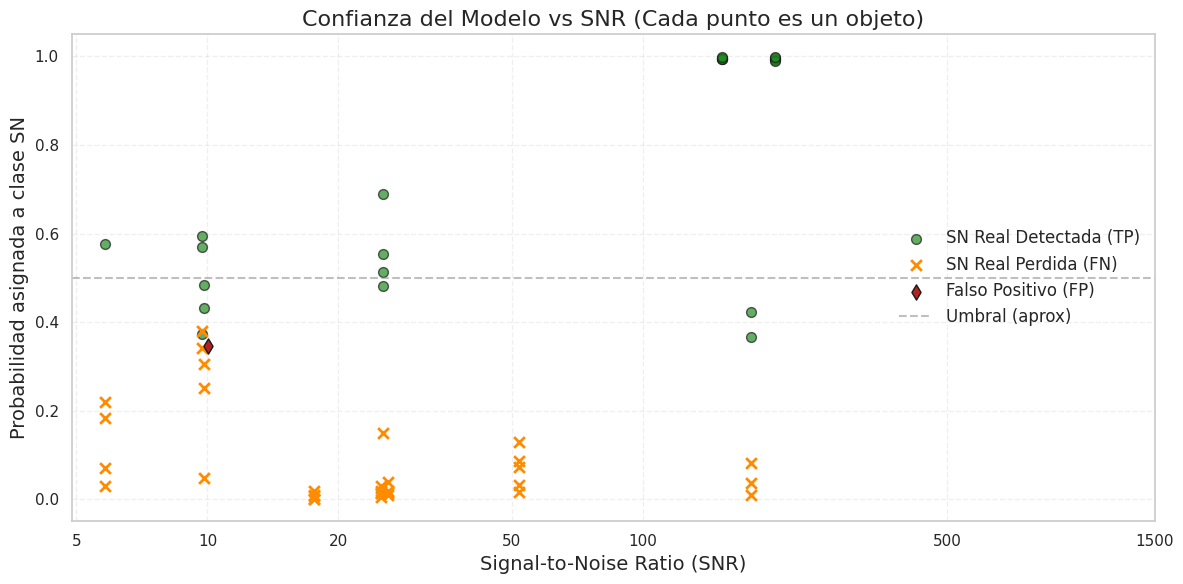

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración
TARGET_CLASS = 'SN'

# Lista para guardar todos los puntos individuales
plot_data = []

print("Extrayendo puntos individuales (sin bins)...")

for df_fold in all_predictions:
    df_fold = df_fold.copy()
    # Aseguramos tipo string para el merge
    df_fold['measurement_id'] = df_fold['measurement_id'].astype(str)
    objects_metadata['measurement_id'] = objects_metadata['measurement_id'].astype(str)
    
    # Unimos para tener el SNR de cada predicción
    merged = pd.merge(df_fold, objects_metadata[['measurement_id', 'snr']], on='measurement_id', how='inner')
    
    if merged.empty: continue
    
    # FILTRO CRÍTICO:
    # Nos interesan dos tipos de objetos:
    # 1. Verdaderas SN (True Positives + False Negatives) -> Queremos ver si el modelo las detecta.
    # 2. Falsos Positivos -> Cosas que NO son SN pero el modelo dijo que sí.
    
    # Caso 1: Es realmente una SN
    true_sn = merged[merged['true_label'] == TARGET_CLASS].copy()
    true_sn['type'] = 'Real SN'
    true_sn['is_correct'] = true_sn['predicted_label'] == TARGET_CLASS
    
    # Caso 2: El modelo predijo SN pero NO lo era (Falsos Positivos)
    false_pos = merged[(merged['predicted_label'] == TARGET_CLASS) & (merged['true_label'] != TARGET_CLASS)].copy()
    false_pos['type'] = 'False Positive'
    false_pos['is_correct'] = False # Por definición es un error
    
    # Concatenamos y guardamos
    relevant_objects = pd.concat([true_sn, false_pos])
    plot_data.append(relevant_objects)

# Unimos todos los folds en un solo dataframe
df_plot = pd.concat(plot_data)

# Ordenamos por SNR para que el gráfico se vea limpio
df_plot = df_plot.sort_values('snr')

# --- GRAFICAR ---
fig, ax = plt.subplots(figsize=(12, 6))

# 1. Puntos: SN Reales detectadas correctamente (Verdes)
correct_sn = df_plot[(df_plot['type'] == 'Real SN') & (df_plot['is_correct'] == True)]
ax.scatter(correct_sn['snr'], correct_sn['prob_SN'], 
           color='forestgreen', label='SN Real Detectada (TP)', alpha=0.7, s=50, edgecolors='k')

# 2. Puntos: SN Reales NO detectadas (Naranjas - Falsos Negativos)
# A estos el modelo les dio baja probabilidad, por eso falló.
missed_sn = df_plot[(df_plot['type'] == 'Real SN') & (df_plot['is_correct'] == False)]
ax.scatter(missed_sn['snr'], missed_sn['prob_SN'], 
           color='darkorange', label='SN Real Perdida (FN)', marker='x', s=60, lw=2)

# 3. Puntos: Falsos Positivos (Rojos)
# Objetos que NO eran SN pero el modelo pensó que sí (probabilidad alta errónea)
fp_sn = df_plot[df_plot['type'] == 'False Positive']
ax.scatter(fp_sn['snr'], fp_sn['prob_SN'], 
           color='firebrick', label='Falso Positivo (FP)', marker='d', s=60, edgecolors='k')

# Estética
ax.set_title(f'Confianza del Modelo vs SNR (Cada punto es un objeto)', fontsize=16)
ax.set_xlabel('Signal-to-Noise Ratio (SNR)', fontsize=14)
ax.set_ylabel('Probabilidad asignada a clase SN', fontsize=14)

# Escala logarítmica en X para ver bien los SNR bajos y el SNR 1500
ax.set_xscale('log') 
# Ajustamos los ticks del eje X para que sean legibles
ax.set_xticks([5, 10, 20, 50, 100, 500, 1500])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Línea de umbral (donde el modelo decide)
# Esto asume que el modelo decide por max-probability. Si es binario, suele ser 0.5.
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral (aprox)')

ax.legend(fontsize=12, loc='center right')
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [52]:
df_plot.dtypes

oid                                int64
measurement_id                    object
true_label_int                     int64
predicted_label_int                int64
true_label                        object
predicted_label                   object
predicted_probability            float64
prob_AGN                         float64
prob_SN                          float64
prob_VS                          float64
prob_asteroid                    float64
prob_bogus                       float64
snr                      double[pyarrow]
type                              object
is_correct                          bool
dtype: object

In [53]:
df_real_all_stamps.dtypes

oid                            int64
measurement_id                 int64
flux_Science_data             object
flux_Science_header           object
flux_Template_data            object
flux_Template_header          object
flux_Difference_data          object
flux_Difference_header        object
variance_Science_data         object
variance_Science_header       object
variance_Template_data        object
variance_Template_header      object
variance_Difference_data      object
variance_Difference_header    object
mask_Science_data             object
mask_Science_header           object
mask_Template_data            object
mask_Template_header          object
mask_Difference_data          object
mask_Difference_header        object
dtype: object

In [54]:
df_real_all_stamps_str = df_real_all_stamps.copy()
df_real_all_stamps_str.measurement_id = df_real_all_stamps.measurement_id.astype(str)
stamps_to_plot = pd.merge(df_plot, df_real_all_stamps_str, on=['oid', 'measurement_id'])
stamps_to_plot

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,...,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169355602825839424,169355602825839424,1,0,SN,AGN,0.649069,0.649069,0.029225,0.002723,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
1,169355602825839424,169355602825839424,1,0,SN,AGN,0.714622,0.714622,0.219780,0.003478,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
2,169355602825839424,169355602825839424,1,0,SN,AGN,0.727312,0.727312,0.184000,0.003923,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
3,169355602825839424,169355602825839424,1,0,SN,AGN,0.885423,0.885423,0.070232,0.002329,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
4,169355602825839424,169355602825839424,1,1,SN,SN,0.576022,0.416064,0.576022,0.003048,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
5,169342396577350145,169342396577350145,1,1,SN,SN,0.373410,0.272575,0.373410,0.016509,...,"[[74.71856, 63.32415, 65.93816, 76.07733, 76.3...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[697.6801, 710.2958, 686.6568, 721.39325, 678...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.84...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.098512...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.84...","[XTENSION, BITPIX, NAXIS, NAXIS1

In [55]:
stamps_to_plot_snr_grande = stamps_to_plot[stamps_to_plot.snr < 30]
stamps_to_plot_snr_grande

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,...,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169355602825839424,169355602825839424,1,0,SN,AGN,0.649069,0.649069,0.029225,0.002723,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
1,169355602825839424,169355602825839424,1,0,SN,AGN,0.714622,0.714622,0.219780,0.003478,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
2,169355602825839424,169355602825839424,1,0,SN,AGN,0.727312,0.727312,0.184000,0.003923,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
3,169355602825839424,169355602825839424,1,0,SN,AGN,0.885423,0.885423,0.070232,0.002329,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
4,169355602825839424,169355602825839424,1,1,SN,SN,0.576022,0.416064,0.576022,0.003048,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
5,169342396577350145,169342396577350145,1,1,SN,SN,0.373410,0.272575,0.373410,0.016509,...,"[[74.71856, 63.32415, 65.93816, 76.07733, 76.3...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[697.6801, 710.2958, 686.6568, 721.39325, 678...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.84...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.098512...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.84...","[XTENSION, BITPIX, NAXIS, NAXIS1

In [56]:
stamps_to_plot_snr_grande.drop_duplicates('measurement_id')

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,...,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169355602825839424,169355602825839424,1,0,SN,AGN,0.649069,0.649069,0.029225,0.002723,...,"[[16.37832, 16.42102, 12.29205, 15.2376, 16.35...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[110.69368, 117.38978, 123.80215, 128.51572, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.14...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
5,169342396577350145,169342396577350145,1,1,SN,SN,0.373410,0.272575,0.373410,0.016509,...,"[[74.71856, 63.32415, 65.93816, 76.07733, 76.3...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[697.6801, 710.2958, 686.6568, 721.39325, 678...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.84...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.098512...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.84...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
10,169359996456271949,169359996456271949,1,4,SN,bogus,0.479547,0.064872,0.305373,0.100070,...,"[[157.97916, 161.06604, 156.95558, 156.45932, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[3631.6816, 3738.624, 3681.974, 3391.8782, 34...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[-3.017248960465706e-15, -4.409099768309105e-...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
15,169298432603193372,169302854326550543,4,1,bogus,SN,0.344901,0.239839,0.344901,0.090019,...,"[[203.86424, 223.6049, 225.68114, 247.70084, 2...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[3011.4092, 2921.9111, 2988.0225, 3039.8054, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.47...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 7.73768482114374e-13, -1.0132...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.47...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
16,169562326408626383,169562326408626383,1,0,SN,AGN,0.634143,0.634143,0.000701,0.158477,...,"[[565.6982, 426.88858, 437.29965, 458.38635, 4...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[5723.9062, 5671.7397, 5714.5825, 5815.34, 57...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.48...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.48...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
21,169364390463143977,169364390463143977,1,0,SN,AGN,0.664219,0.664219,0.014936,0.310662,...,"[[121.15169, 150.85744, 175.56262, 115.05775, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[1315.8372, 1327.777, 1361.0005, 1323.1765, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.13...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.13...","[XTENSION, BITPIX, NAXI

In [57]:
stamps_to_plot_snr_grande.drop_duplicates('measurement_id').predicted_label.value_counts()

predicted_label
AGN      4
SN       3
bogus    1
Name: count, dtype: int64

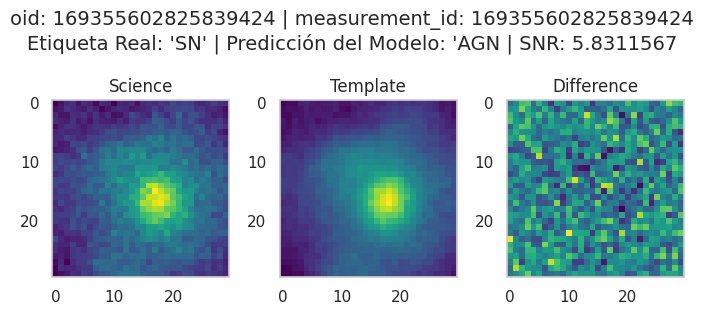

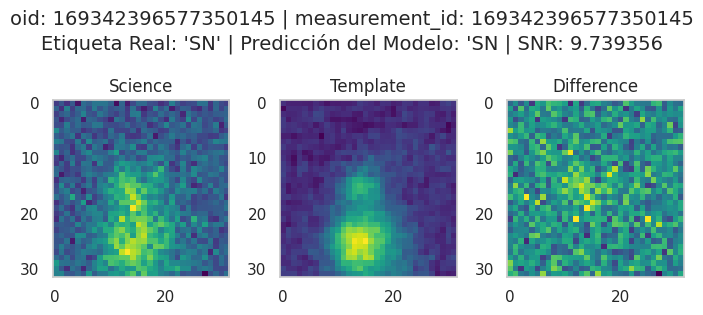

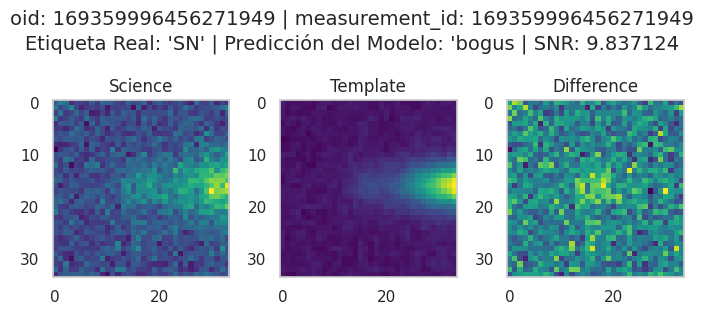

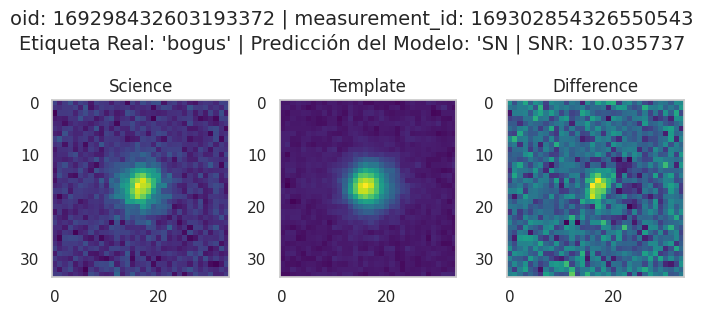

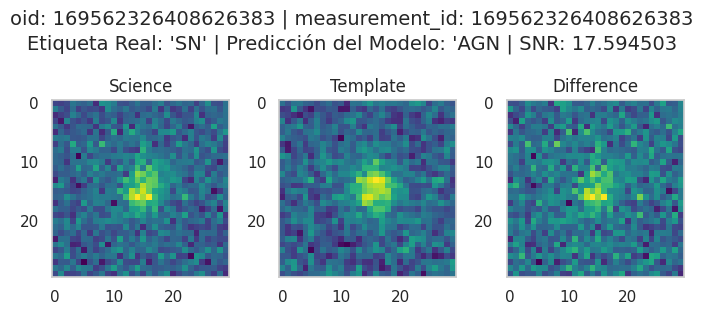

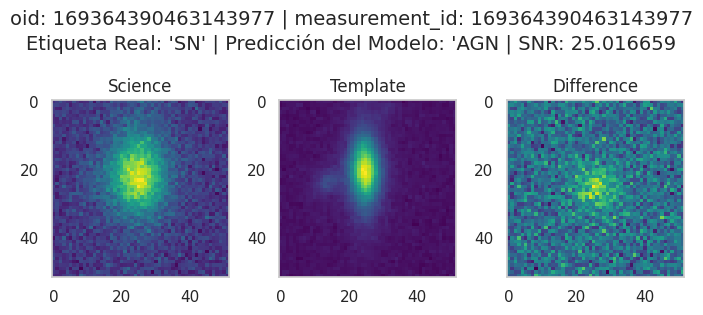

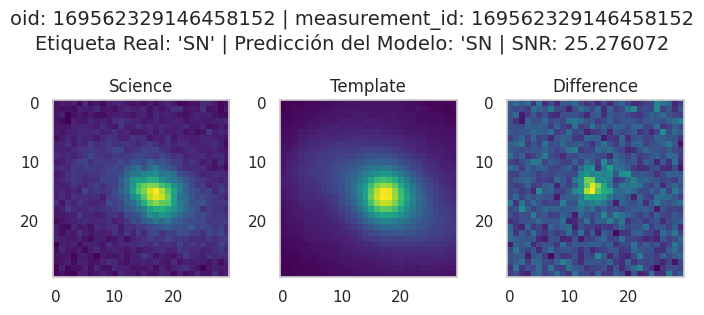

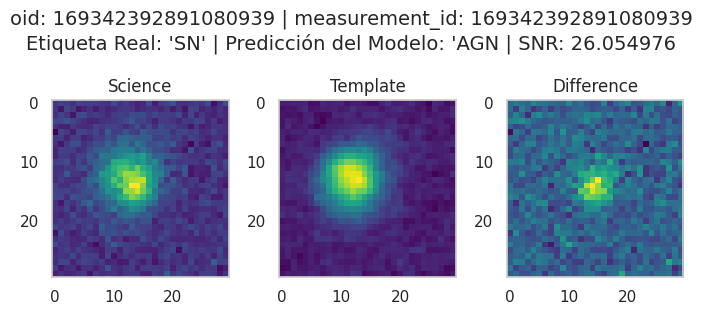

In [58]:
for index, row in stamps_to_plot_snr_grande.drop_duplicates('measurement_id').iterrows():
    fig, axes = plt.subplots(1, 3, figsize=(7, 4))

    stamps_to_plot_values = {
        "Science": row['flux_Science_data'],
        "Template": row['flux_Template_data'],
        "Difference": row['flux_Difference_data']
    }
    
    # Iteramos para aplicar los cambios a cada subplot
    for i, (title, data) in enumerate(stamps_to_plot_values.items()):
        ax = axes[i]
        im = ax.imshow(data, cmap='viridis')
        ax.set_title(title)

        #fig.colorbar(im, ax=ax, shrink=0.4, aspect=7)
        
        ax.grid(False)
        #ax.set_xticks([])
        #ax.set_yticks([])

    main_title = (
        f"oid: {row['oid']} | measurement_id: {row['measurement_id']}\n"
        f"Etiqueta Real: '{row['true_label']}' | Predicción del Modelo: '{row['predicted_label']} | SNR: {row['snr']}"
    )
    fig.suptitle(main_title, fontsize=14, y=0.87) # Ajuste de 'y' para el nuevo tamaño
    
    plt.tight_layout() # Ajuste para que el suptitle no se solape
    plt.show()

Procesando 5 folds para generar curvas promedio...


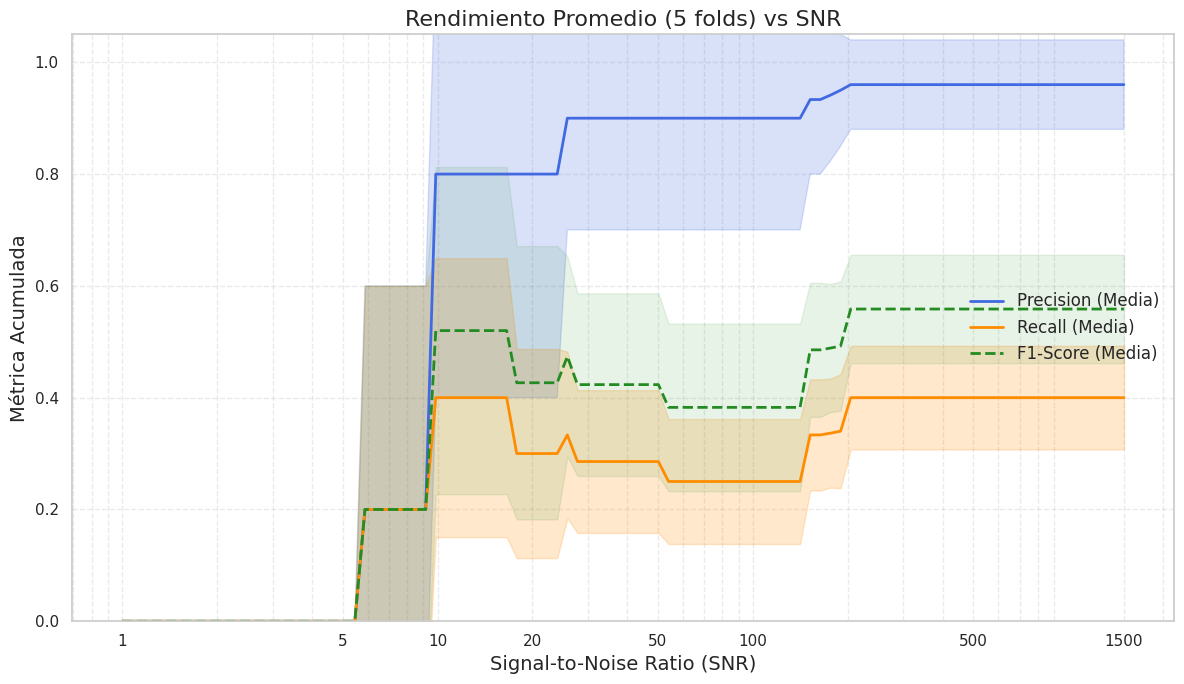

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
TARGET_CLASS = 'SN'
# Definimos una grilla común de SNR para poder promediar los folds.
# Usamos escala logarítmica porque tus datos abarcan de 5 a 1500.
common_snr_grid = np.logspace(np.log10(1), np.log10(1500), 100)

# Listas para guardar las curvas interpoladas de cada fold
all_precisions = []
all_recalls = []
all_f1s = []

print(f"Procesando {len(all_predictions)} folds para generar curvas promedio...")

for i, df_fold in enumerate(all_predictions):
    df_fold = df_fold.copy()
    df_fold['measurement_id'] = df_fold['measurement_id'].astype(str)
    objects_metadata['measurement_id'] = objects_metadata['measurement_id'].astype(str)
    
    # 1. Merge para obtener SNR
    merged = pd.merge(df_fold, objects_metadata[['measurement_id', 'snr']], on='measurement_id', how='inner')
    if merged.empty: continue
    
    # 2. Ordenar por SNR (vital para el cálculo acumulado)
    merged = merged.sort_values('snr')
    
    # 3. Calcular TP, FP, FN acumulados para ESTE fold
    merged['TP'] = ((merged['true_label'] == TARGET_CLASS) & (merged['predicted_label'] == TARGET_CLASS)).astype(int)
    merged['FP'] = ((merged['true_label'] != TARGET_CLASS) & (merged['predicted_label'] == TARGET_CLASS)).astype(int)
    merged['FN'] = ((merged['true_label'] == TARGET_CLASS) & (merged['predicted_label'] != TARGET_CLASS)).astype(int)
    
    # Solo nos importa donde cambia la métrica (filtrar ruido si quieres, pero acumulado funciona igual)
    # Acumulamos
    cum_tp = merged['TP'].cumsum()
    cum_fp = merged['FP'].cumsum()
    cum_fn = merged['FN'].cumsum()
    
    # Evitar división por cero
    precision_curve = cum_tp / (cum_tp + cum_fp)
    recall_curve = cum_tp / (cum_tp + cum_fn)
    # Rellenamos NaNs iniciales (cuando todo es 0)
    precision_curve = precision_curve.fillna(0) 
    recall_curve = recall_curve.fillna(0)
    
    # Calculamos F1
    denom = precision_curve + recall_curve
    f1_curve = np.divide(2 * precision_curve * recall_curve, denom, out=np.zeros_like(denom), where=denom!=0)
    
    # 4. INTERPOLACIÓN (El paso clave)
    # Proyectamos los valores de este fold sobre la grilla común
    # xp = SNR reales del fold, fp = Métricas calculadas
    interp_p = np.interp(common_snr_grid, merged['snr'], precision_curve)
    interp_r = np.interp(common_snr_grid, merged['snr'], recall_curve)
    interp_f = np.interp(common_snr_grid, merged['snr'], f1_curve)
    
    all_precisions.append(interp_p)
    all_recalls.append(interp_r)
    all_f1s.append(interp_f)

# --- 5. AGREGACIÓN (Promedio y Desviación Estándar) ---
# Convertimos listas a arrays de numpy (n_folds x 100)
arr_prec = np.array(all_precisions)
arr_rec = np.array(all_recalls)
arr_f1 = np.array(all_f1s)

# Media
mean_p = np.mean(arr_prec, axis=0)
mean_r = np.mean(arr_rec, axis=0)
mean_f = np.mean(arr_f1, axis=0)

# Desviación Estándar
std_p = np.std(arr_prec, axis=0)
std_r = np.std(arr_rec, axis=0)
std_f = np.std(arr_f1, axis=0)

# --- 6. GRAFICAR ---
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Precision (Azul)
ax.plot(common_snr_grid, mean_p, color='royalblue', lw=2, label='Precision (Media)')
ax.fill_between(common_snr_grid, mean_p - std_p, mean_p + std_p, color='royalblue', alpha=0.2)

# Plot Recall (Naranja)
ax.plot(common_snr_grid, mean_r, color='darkorange', lw=2, label='Recall (Media)')
ax.fill_between(common_snr_grid, mean_r - std_r, mean_r + std_r, color='darkorange', alpha=0.2)

# Plot F1 (Verde)
ax.plot(common_snr_grid, mean_f, color='forestgreen', lw=2, ls='--', label='F1-Score (Media)')
ax.fill_between(common_snr_grid, mean_f - std_f, mean_f + std_f, color='forestgreen', alpha=0.1)

# Estética
ax.set_title(f'Rendimiento Promedio ({len(all_predictions)} folds) vs SNR', fontsize=16)
ax.set_xlabel('Signal-to-Noise Ratio (SNR)', fontsize=14)
ax.set_ylabel('Métrica Acumulada', fontsize=14)
ax.set_xscale('log') # Importante para ver el rango completo

# Ajuste de ticks para que se entienda la escala log
ax.set_xticks([1, 5, 10, 20, 50, 100, 500, 1500])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_ylim(0, 1.05)
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc='center right')

plt.tight_layout()
plt.show()

Procesando métricas acumuladas por objeto...


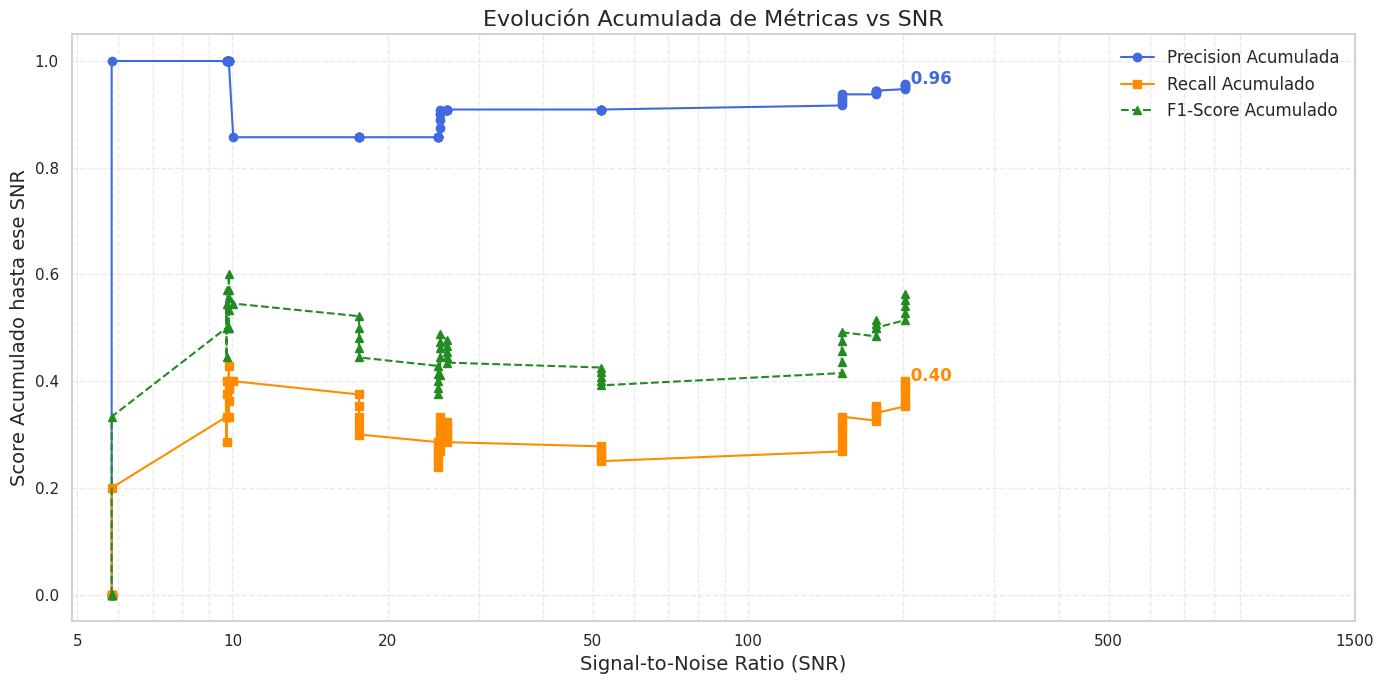

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración
TARGET_CLASS = 'SN'

# 1. Recopilar todos los datos
data_list = []

print("Procesando métricas acumuladas por objeto...")

for df_fold in all_predictions:
    df_fold = df_fold.copy()
    df_fold['measurement_id'] = df_fold['measurement_id'].astype(str)
    objects_metadata['measurement_id'] = objects_metadata['measurement_id'].astype(str)
    
    # Merge para obtener SNR
    merged = pd.merge(df_fold, objects_metadata[['measurement_id', 'snr']], on='measurement_id', how='inner')
    if merged.empty: continue
    
    # Definimos las condiciones para contar
    # TP: Es SN y predijo SN
    merged['TP'] = ((merged['true_label'] == TARGET_CLASS) & (merged['predicted_label'] == TARGET_CLASS)).astype(int)
    
    # FP: NO es SN pero predijo SN
    merged['FP'] = ((merged['true_label'] != TARGET_CLASS) & (merged['predicted_label'] == TARGET_CLASS)).astype(int)
    
    # FN: Es SN pero predijo otra cosa
    merged['FN'] = ((merged['true_label'] == TARGET_CLASS) & (merged['predicted_label'] != TARGET_CLASS)).astype(int)
    
    # Filtramos solo filas que afecten a las métricas de SN (o es SN, o se confundió con SN)
    # Si es un asteroide predicho correctamente como asteroide (True Negative), no afecta P/R de SN.
    relevant_mask = (merged['true_label'] == TARGET_CLASS) | (merged['predicted_label'] == TARGET_CLASS)
    relevant_df = merged[relevant_mask].copy()
    
    data_list.append(relevant_df)

# Concatenamos todo
df_all = pd.concat(data_list)

# --- 2. EL TRUCO: ORDENAR Y ACUMULAR ---

# Ordenamos por SNR ascendente (para ver cómo mejora/empeora al subir el brillo)
df_all = df_all.sort_values('snr')

# Calculamos las sumas acumuladas (Cumulative Sum)
# En la fila N, 'cum_TP' es la suma de TP desde la fila 0 hasta la N.
df_all['cum_TP'] = df_all['TP'].cumsum()
df_all['cum_FP'] = df_all['FP'].cumsum()
df_all['cum_FN'] = df_all['FN'].cumsum()

# Calculamos métricas fila por fila (por punto)
# Precision = TP / (TP + FP)
df_all['precision_point'] = df_all['cum_TP'] / (df_all['cum_TP'] + df_all['cum_FP'])

# Recall = TP / (TP + FN)
df_all['recall_point'] = df_all['cum_TP'] / (df_all['cum_TP'] + df_all['cum_FN'])

# F1 Score
df_all['f1_point'] = 2 * (df_all['precision_point'] * df_all['recall_point']) / \
                     (df_all['precision_point'] + df_all['recall_point'])

# Limpieza de NaNs (al inicio puede haber divisiones por cero)
df_all = df_all.fillna(0)

# --- 3. GRAFICAR ---
fig, ax = plt.subplots(figsize=(14, 7))

# Graficamos Precision (Azul)
ax.plot(df_all['snr'], df_all['precision_point'], 
        marker='o', markersize=6, linestyle='-', linewidth=1.5, color='royalblue', label='Precision Acumulada')

# Graficamos Recall (Naranja)
ax.plot(df_all['snr'], df_all['recall_point'], 
        marker='s', markersize=6, linestyle='-', linewidth=1.5, color='darkorange', label='Recall Acumulado')

# Graficamos F1 (Verde)
ax.plot(df_all['snr'], df_all['f1_point'], 
        marker='^', markersize=6, linestyle='--', linewidth=1.5, color='forestgreen', label='F1-Score Acumulado')

# Estética
ax.set_title(f'Evolución Acumulada de Métricas vs SNR', fontsize=16)
ax.set_xlabel('Signal-to-Noise Ratio (SNR)', fontsize=14)
ax.set_ylabel('Score Acumulado hasta ese SNR', fontsize=14)

# Escala Logarítmica en X
ax.set_xscale('log')
ax.set_xticks([5, 10, 20, 50, 100, 500, 1500])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Límites y Grilla
ax.set_ylim(-0.05, 1.05)
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend(fontsize=12)

# --- BONUS: Etiquetas en el último punto ---
last_row = df_all.iloc[-1]
ax.text(last_row['snr'], last_row['precision_point'], f" {last_row['precision_point']:.2f}", color='royalblue', fontweight='bold')
ax.text(last_row['snr'], last_row['recall_point'], f" {last_row['recall_point']:.2f}", color='darkorange', fontweight='bold')

plt.tight_layout()
plt.show()

In [87]:
df_all['snr']

517     5.348292
517     5.348292
517     5.348292
517     5.348292
517     5.348292
         ...    
531    151.82372
544    428.13055
544    428.13055
544    428.13055
544    428.13055
Name: snr, Length: 121, dtype: double[pyarrow]

In [62]:
df_comentarios = pd.read_csv('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/models/experimentation/stamp_rubin/retiro/comm_sne_tran_flagged.csv')
df_comentarios.comment.unique()

array(['Negative difference flux', 'Unclear difference stamp',
       'PSF too wide in difference stamp',
       'PSF bad shape in difference stamp', 'Dipole in difference stamp'],
      dtype=object)

In [63]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display 

# --- 0. Configuración de Auditoría ---
orden_filas_audit = [
    'AGN', 'SN', 'VS', 'asteroid', 'bogus', 
    'Negative difference flux', 
    'Unclear difference stamp', 
    'PSF too wide in difference stamp', 
    'PSF bad shape in difference stamp', 
    'Dipole in difference stamp'
]
orden_columnas_audit = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']

# --- Selección de runs ---
fold_run = runs[runs['run_name'] == run_name]

# --- Listas para almacenar resultados de cada fold ---
all_confusion_matrices = []
all_confusion_matrices_norm = []
all_classification_reports = []
all_audit_matrices = [] # <--- Recolecta matrices asimétricas
class_names = [] 
class_labels = [] 
all_predictions = []
all_predictions_sim = []

# --- 1. Iterar y recolectar resultados de cada fold ---
print(f"Procesando {len(fold_run)} folds para el experimento {run_name}...\n")

for idx, row in fold_run.iterrows():
    experiment_id = row['experiment_id']
    run_id = row['run_id']
    path_pred = f'./{results_file_name}/ml-runs/{experiment_id}/{run_id}/artifacts/test_predictions.csv'
    
    try:
        predictions = pd.read_csv(path_pred)
        all_predictions_sim.append(pd.read_csv(f'./{results_file_name}/ml-runs/{experiment_id}/{run_id}/artifacts/test_sim_predictions.csv'))

        # --- Lógica de Auditoría por Fold ---
        # Unimos con df_comentarios (debe estar disponible en tu ambiente)
        df_audit = predictions.merge(df_comentarios[['measurement_id', 'comment']], on='measurement_id', how='left')
        df_audit['fila_audit'] = df_audit['comment'].fillna(df_audit['true_label'])
        
        # Creamos la matriz asimétrica y reindexamos para mantener consistencia 10x5
        cm_audit_fold = pd.crosstab(df_audit['fila_audit'], df_audit['predicted_label'])
        cm_audit_fold = cm_audit_fold.reindex(index=orden_filas_audit, columns=orden_columnas_audit, fill_value=0)
        all_audit_matrices.append(cm_audit_fold.values)
        # ------------------------------------

        y_true = predictions['true_label_int']
        y_pred = predictions['predicted_label_int']
        
        if not class_names:
            labels_df = predictions[['true_label_int', 'true_label']].drop_duplicates().sort_values('true_label_int')
            class_labels = labels_df['true_label_int'].tolist()
            class_names = labels_df['true_label'].tolist()

        all_predictions.append(predictions)

        # Matrices estándar (Cuadradas)
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        all_confusion_matrices.append(cm)
        cm_norm = confusion_matrix(y_true, y_pred, labels=class_labels, normalize='true')
        all_confusion_matrices_norm.append(cm_norm)
        
        # Reporte de clasificación (como diccionario)
        report = classification_report(y_true, y_pred, labels=class_labels, target_names=class_names, output_dict=True, zero_division=0)
        all_classification_reports.append(report)
        
    except FileNotFoundError:
        print(f"ADVERTENCIA: No se encontró el archivo en run_id: {run_id}")
    except Exception as e:
        print(f"Error en run_id {run_id}: {e}")

# --- A. Para la Matriz Estándar ---
if all_confusion_matrices:
    cm_stack = np.stack(all_confusion_matrices, axis=0)
    mean_cm = np.mean(cm_stack, axis=0)
    std_cm = np.std(cm_stack, axis=0)
    
    cm_norm_stack = np.stack(all_confusion_matrices_norm, axis=0)
    mean_cm_norm = np.mean(cm_norm_stack, axis=0)
    std_cm_norm = np.std(cm_norm_stack, axis=0)
else:
    mean_cm = std_cm = mean_cm_norm = None

# --- 2. Procesar y promediar Auditoría (Cálculo de std_audit) ---
if all_audit_matrices:
    audit_stack = np.stack(all_audit_matrices, axis=0)
    mean_audit = np.mean(audit_stack, axis=0)
    std_audit = np.std(audit_stack, axis=0)
    
    # Normalización por fila (Recall) para graficación posterior
    fila_sumas = mean_audit.sum(axis=1, keepdims=True)
    fila_sumas[fila_sumas == 0] = 1 
    mean_audit_norm = mean_audit / fila_sumas
    std_audit_norm = std_audit / fila_sumas

# --- 3. Reporte de Clasificación Detallado (Media ± Std) ---
if all_classification_reports:
    report_data = []
    all_accuracies, all_macro_avg, all_weighted_avg = [], [], []
    
    # Etiquetas de comentarios que queremos mostrar en el reporte
    audit_tags = orden_filas_audit[5:] # Las últimas 5 de tu lista

    for i, report in enumerate(all_classification_reports):
        # A. Métricas clases normales
        for class_name in class_names:
            if class_name in report:
                metrics = report[class_name]
                report_data.append({
                    'class': class_name, 'precision': metrics['precision'], 
                    'recall': metrics['recall'], 'f1-score': metrics['f1-score'], 'support': metrics['support']
                })
        
        # B. Recall para etiquetas de auditoría (desde la matriz asimétrica del fold)
        if i < len(all_audit_matrices):
            matriz_fold = all_audit_matrices[i]
            for tag in audit_tags:
                idx_fila = orden_filas_audit.index(tag)
                idx_col_sn = orden_columnas_audit.index('SN')
                fila = matriz_fold[idx_fila, :]
                soporte = fila.sum()
                recall_audit = fila[idx_col_sn] / soporte if soporte > 0 else 0
                report_data.append({
                    'class': tag, 'precision': np.nan, 'recall': recall_audit, 'f1-score': np.nan, 'support': soporte
                })

        all_accuracies.append(report['accuracy'])
        all_macro_avg.append(report['macro avg'])
        all_weighted_avg.append(report['weighted avg'])
    
    reports_df = pd.DataFrame(report_data)
    final_report_stats = reports_df.groupby('class').agg(['mean', 'std'])

    # Métricas agregadas
    accuracy_mean, accuracy_std = np.mean(all_accuracies), np.std(all_accuracies)
    macro_mean, macro_std = pd.DataFrame(all_macro_avg).mean(), pd.DataFrame(all_macro_avg).std()
    weighted_mean, weighted_std = pd.DataFrame(all_weighted_avg).mean(), pd.DataFrame(all_weighted_avg).std()
    total_support = int(final_report_stats.loc[class_names, ('support', 'mean')].sum())

    # --- IMPRESIÓN DEL REPORTE FINAL ---
    print("\n" + "="*85)
    print("        REPORTE DE CLASIFICACIÓN Y AUDITORÍA SN (PROMEDIO ± STD)")
    print("="*85)
    
    all_rows = class_names + audit_tags
    max_len = max(len(name) for name in all_rows)
    print(f"{'':>{max_len}} {'precision':>20} {'recall':>20} {'f1-score':>20} {'support':>9}")
    print("-"*(max_len + 73))

    for name in all_rows:
        if name not in final_report_stats.index: continue
        row = final_report_stats.loc[name]
        support = int(row[('support', 'mean')])
        
        # Formateo condicional si es clase real o comentario
        if name in class_names:
            p_s = f"{row[('precision', 'mean')]:.2f} ± {row[('precision', 'std')]:.2f}"
            f1_s = f"{row[('f1-score', 'mean')]:.2f} ± {row[('f1-score', 'std')]:.2f}"
        else:
            p_s, f1_s = f"{'---':>20}", f"{'---':>20}"

        r_s = f"{row[('recall', 'mean')]:.2f} ± {row[('recall', 'std')]:.2f}"
        print(f"{name:<{max_len}} {p_s:>20} {r_s:>20} {f1_s:>20} {support:>9}")

    print("-"*(max_len + 73))
    print(f"{'accuracy':<{max_len}} {'':>20} {'':>20} {accuracy_mean:.2f} ± {accuracy_std:.2f} {total_support:>9}")
    
    for label, m, s in [('macro avg', macro_mean, macro_std), ('weighted avg', weighted_mean, weighted_std)]:
        p_s = f"{m['precision']:.2f} ± {s['precision']:.2f}"
        r_s = f"{m['recall']:.2f} ± {s['recall']:.2f}"
        f1_s = f"{m['f1-score']:.2f} ± {s['f1-score']:.2f}"
        print(f"{label:<{max_len}} {p_s:>20} {r_s:>20} {f1_s:>20} {total_support:>9}")

Procesando 6 folds para el experimento 2026-01-06_19-10-46...

ADVERTENCIA: No se encontró el archivo en run_id: 98bfd4416bc042909245e1b01b1ca707

        REPORTE DE CLASIFICACIÓN Y AUDITORÍA SN (PROMEDIO ± STD)
                                             precision               recall             f1-score   support
----------------------------------------------------------------------------------------------------------
AGN                                        0.65 ± 0.02          0.89 ± 0.01          0.75 ± 0.01        68
SN                                         0.96 ± 0.09          0.40 ± 0.10          0.56 ± 0.11        11
VS                                         0.79 ± 0.01          0.76 ± 0.02          0.78 ± 0.01       118
asteroid                                   0.92 ± 0.01          0.93 ± 0.01          0.93 ± 0.00       191
bogus                                      0.90 ± 0.01          0.86 ± 0.00          0.88 ± 0.00       397
Negative difference flux               

In [64]:
# --- b) Reporte de Clasificación ---
if all_classification_reports:
    # 1. Agrupar los resultados por clase y por etiquetas de auditoría
    # ---------------------------------------------------------------------
    report_data = []
    all_accuracies = []
    all_macro_avg = []
    all_weighted_avg = []

    # Definimos las categorías de auditoría (las que son comentarios)
    audit_tags = [
        'Negative difference flux', 
        'Unclear difference stamp', 
        'PSF too wide in difference stamp', 
        'PSF bad shape in difference stamp', 
        'Dipole in difference stamp'
    ]

    for i, report in enumerate(all_classification_reports):
        # A. Extraer métricas por clase estándar
        for class_name in class_names:
            if class_name in report:
                metrics = report[class_name]
                report_data.append({
                    'class': class_name,
                    'precision': metrics['precision'],
                    'recall': metrics['recall'],
                    'f1-score': metrics['f1-score'],
                    'support': metrics['support']
                })
        
        # B. Extraer "Recall" para las etiquetas de auditoría desde las matrices de auditoría
        # Usamos la matriz del fold actual: all_audit_matrices[i]
        if i < len(all_audit_matrices):
            matriz_fold = all_audit_matrices[i] # Esta es la matriz 10x5
            
            for tag in audit_tags:
                if tag in orden_filas_audit:
                    idx_fila = orden_filas_audit.index(tag)
                    idx_col_sn = orden_columnas_audit.index('SN')
                    
                    fila = matriz_fold[idx_fila, :]
                    soporte = fila.sum()
                    
                    # El recall para un comentario es: ¿Cuántos predijo como SN? / Total
                    recall_audit = fila[idx_col_sn] / soporte if soporte > 0 else 0
                    
                    report_data.append({
                        'class': tag,
                        'precision': np.nan, # No existe precisión para un comentario
                        'recall': recall_audit,
                        'f1-score': np.nan,
                        'support': soporte
                    })

        # Extraer métricas agregadas
        all_accuracies.append(report['accuracy'])
        all_macro_avg.append(report['macro avg'])
        all_weighted_avg.append(report['weighted avg'])
    
    reports_df = pd.DataFrame(report_data)
    
    # Agrupamos por clase/tag y calculamos la media y std
    final_report_stats = reports_df.groupby('class').agg(['mean', 'std'])

    # 2. Calcular media y std para las métricas agregadas
    # ---------------------------------------------------------------------
    accuracy_mean = np.mean(all_accuracies)
    accuracy_std = np.std(all_accuracies)
    macro_avg_mean, macro_avg_std = pd.DataFrame(all_macro_avg).mean(), pd.DataFrame(all_macro_avg).std()
    weighted_avg_mean, weighted_avg_std = pd.DataFrame(all_weighted_avg).mean(), pd.DataFrame(all_weighted_avg).std()

    total_support = int(final_report_stats.loc[class_names, ('support', 'mean')].sum())

    # 3. Imprimir el reporte con el formato "media ± std"
    # ---------------------------------------------------------------------
    print("\n" + "="*85)
    print("        REPORTE DE CLASIFICACIÓN Y AUDITORÍA SN (PROMEDIO ± STD)")
    print("="*85)

    # Combinamos nombres de clases y auditoría para el loop de impresión
    all_display_rows = class_names + audit_tags
    max_len = max(len(name) for name in all_display_rows)
    header = f"{'':>{max_len}} {'precision':>20} {'recall':>20} {'f1-score':>20} {'support':>9}"
    print(header)
    print("-"*len(header))

    # Imprimir métricas
    for name in all_display_rows:
        if name not in final_report_stats.index: continue
        
        row = final_report_stats.loc[name]
        support = int(row[('support', 'mean')])
        
        # Formatear Precision (solo para clases originales)
        if name in class_names:
            p_str = f"{row[('precision', 'mean')]:.2f} ± {row[('precision', 'std')]:.2f}"
            f1_str = f"{row[('f1-score', 'mean')]:.2f} ± {row[('f1-score', 'std')]:.2f}"
        else:
            p_str = f"{'---':>20}" # Los comentarios no tienen Precision
            f1_str = f"{'---':>20}" # Ni F1-score propiamente tal

        # Recall (Este sí es vital para ambos)
        r_str = f"{row[('recall', 'mean')]:.2f} ± {row[('recall', 'std')]:.2f}"
        
        print(f"{name:<{max_len}} {p_str:>20} {r_str:>20} {f1_str:>20} {support:>9}")

    print("-" * len(header))

    # Accuracy, Macro y Weighted
    print(f"{'accuracy':<{max_len}} {'':>20} {'':>20} {accuracy_mean:.2f} ± {accuracy_std:.2f} {total_support:>9}")
    
    for label, mean, std in [('macro avg', macro_avg_mean, macro_avg_std), ('weighted avg', weighted_avg_mean, weighted_avg_std)]:
        p_s = f"{mean['precision']:.2f} ± {std['precision']:.2f}"
        r_s = f"{mean['recall']:.2f} ± {std['recall']:.2f}"
        f_s = f"{mean['f1-score']:.2f} ± {std['f1-score']:.2f}"
        print(f"{label:<{max_len}} {p_s:>20} {r_s:>20} {f_s:>20} {total_support:>9}")

else:
    print("\nNo se encontraron reportes de clasificación para procesar.")


        REPORTE DE CLASIFICACIÓN Y AUDITORÍA SN (PROMEDIO ± STD)
                                             precision               recall             f1-score   support
----------------------------------------------------------------------------------------------------------
AGN                                        0.65 ± 0.02          0.89 ± 0.01          0.75 ± 0.01        68
SN                                         0.96 ± 0.09          0.40 ± 0.10          0.56 ± 0.11        11
VS                                         0.79 ± 0.01          0.76 ± 0.02          0.78 ± 0.01       118
asteroid                                   0.92 ± 0.01          0.93 ± 0.01          0.93 ± 0.00       191
bogus                                      0.90 ± 0.01          0.86 ± 0.00          0.88 ± 0.00       397
Negative difference flux                           ---          0.20 ± 0.45                  ---         1
Unclear difference stamp                           ---          0.00 ± 0.00   

/tmp/ipykernel_3015231/412671523.py:52: RuntimeWarning: invalid value encountered in divide
  mean_audit_norm = mean_audit / mean_audit.sum(axis=1, keepdims=True)
/tmp/ipykernel_3015231/412671523.py:54: RuntimeWarning: invalid value encountered in divide
  std_audit_norm = std_audit / mean_audit.sum(axis=1, keepdims=True)


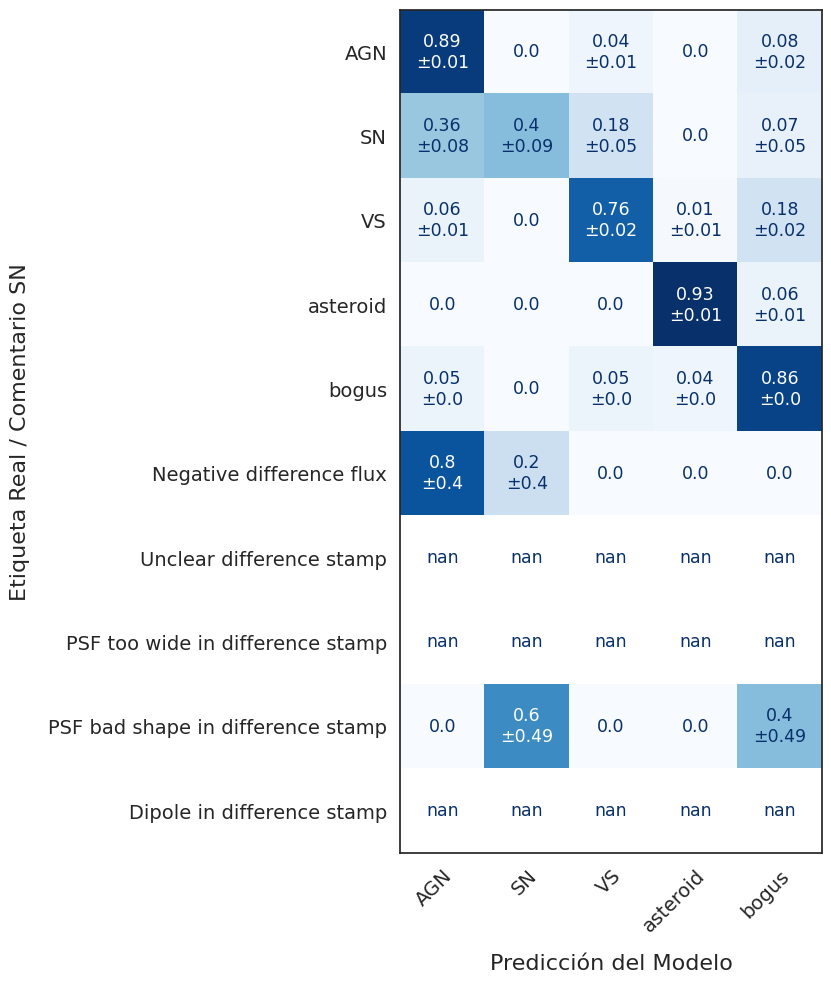

In [68]:
sns.set_style("white")

def get_audit_confusion_matrix(mean_matrix, std_matrix, row_labels, col_labels):
    # Graficando la matriz media
    cmap = plt.cm.Blues
    # Ajustamos el tamaño de la figura (más alta que ancha para acomodar las 10 filas)
    fig, ax = plt.subplots(figsize=(8, 10)) 
    im = ax.imshow(np.around(mean_matrix, decimals=2), interpolation='nearest', cmap=cmap)

    # color map
    new_color = cmap(1.0) 

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    # shape[0] son las filas (10), shape[1] son las columnas (5)
    for i in range(mean_matrix.shape[0]):
        for j in range(mean_matrix.shape[1]):
            # Determinamos el color basado en la intensidad (normalizado por fila)
            color = "white" if mean_matrix[i, j] > 0.5 else new_color
            
            if mean_matrix[i, j] >= 0.005:
                text = f'{np.around(mean_matrix[i, j], decimals=2)}\n±{np.around(std_matrix[i, j], decimals=2)}'
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12.5)
            else:
                text = f'{np.around(mean_matrix[i, j], decimals=2)}'
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12.5)

    # Ajustes de los ejes
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Configuración de Columnas (Predicciones)
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Configuración de Filas (Etiquetas Reales / Auditoría)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)

    ax.set_xlabel("Predicción del Modelo", fontsize=16)
    ax.set_ylabel("Etiqueta Real / Comentario SN", fontsize=16)
    
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    #plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- Llamada a la función ---
# Primero calculamos la normalizada por fila para que los colores y valores tengan sentido (Recall)
# mean_audit y std_audit vienen del bloque de código anterior
mean_audit_norm = mean_audit / mean_audit.sum(axis=1, keepdims=True)
# Nota: La desviación estándar normalizada es una aproximación
std_audit_norm = std_audit / mean_audit.sum(axis=1, keepdims=True)

get_audit_confusion_matrix(
    mean_audit_norm, 
    std_audit_norm, 
    orden_filas_audit, 
    orden_columnas_audit
)

Evaluando clase 'SN' con bins anchos (debido a baja cantidad de muestras)...


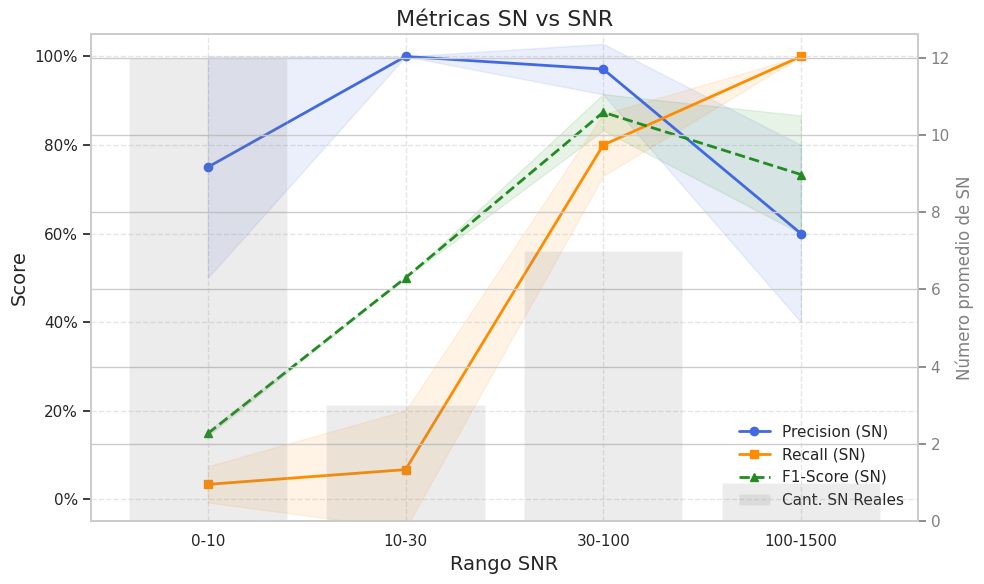

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

# --- 1. DEFINICIÓN DE BINS PARA POCOS DATOS ---
# Con solo ~21 objetos, necesitamos "bolsas" grandes para atrapar algo en cada una.
SNR_BINS = [0, 10, 30, 100, 1500] 

bin_labels = [f'{SNR_BINS[i]}-{SNR_BINS[i+1]}' for i in range(len(SNR_BINS)-1)]

# --- 2. CONFIGURACIÓN ---
TARGET_CLASS = 'SN'  # <--- AQUÍ LE DECIMOS QUE SOLO NOS IMPORTAN LAS MÉTRICAS DE SN
snr_metrics = {
    'precision': {k: [] for k in bin_labels},
    'recall':    {k: [] for k in bin_labels},
    'f1':        {k: [] for k in bin_labels},
    'count':     {k: [] for k in bin_labels}
}

objects_metadata['measurement_id'] = objects_metadata['measurement_id'].astype(str)

print(f"Evaluando clase '{TARGET_CLASS}' con bins anchos (debido a baja cantidad de muestras)...")

# --- 3. PROCESAMIENTO ---
for i, df_fold in enumerate(all_predictions):
    df_fold = df_fold.copy()
    df_fold['measurement_id'] = df_fold['measurement_id'].astype(str)
    
    # Unimos con metadata para saber el SNR de cada predicción
    merged_df = pd.merge(df_fold, objects_metadata[['measurement_id', 'snr']], on='measurement_id', how='inner')
    
    if merged_df.empty: continue

    # Clasificamos cada predicción en su rango de SNR
    merged_df['snr_bin'] = pd.cut(merged_df['snr'], bins=SNR_BINS, labels=bin_labels, include_lowest=True)
    
    for bin_label in bin_labels:
        # subset contiene TODOS los objetos (SN, Asteroides, etc) en ese rango de SNR
        subset = merged_df[merged_df['snr_bin'] == bin_label]
        
        # Contamos cuántas SN reales hay en este bin (para saber si la estadística es confiable)
        n_true_sn = len(subset[subset['true_label'] == TARGET_CLASS])
        
        # Si no hay datos en absoluto en el bin
        if len(subset) == 0:
            snr_metrics['precision'][bin_label].append(np.nan)
            snr_metrics['recall'][bin_label].append(np.nan)
            snr_metrics['f1'][bin_label].append(np.nan)
            snr_metrics['count'][bin_label].append(0)
            continue
            
        # --- CÁLCULO ESPECÍFICO PARA LA CLASE SN ---
        
        # Aciertos (TP): Era SN y dijimos SN
        TP = ((subset['true_label'] == TARGET_CLASS) & (subset['predicted_label'] == TARGET_CLASS)).sum()
        
        # Falsos Positivos (FP): NO era SN (era asteroide, bogus, etc) pero dijimos SN
        # AQUÍ es por qué necesitamos el dataframe completo
        FP = ((subset['true_label'] != TARGET_CLASS) & (subset['predicted_label'] == TARGET_CLASS)).sum()
        
        # Falsos Negativos (FN): Era SN pero dijimos otra cosa
        FN = ((subset['true_label'] == TARGET_CLASS) & (subset['predicted_label'] != TARGET_CLASS)).sum()
        
        # Precision
        denom_p = TP + FP
        p = TP / denom_p if denom_p > 0 else np.nan 
        
        # Recall
        denom_r = TP + FN
        r = TP / denom_r if denom_r > 0 else np.nan 

        # F1
        if np.isnan(p) or np.isnan(r): f1 = np.nan
        elif (p + r) == 0: f1 = 0.0
        else: f1 = 2 * (p * r) / (p + r)

        snr_metrics['precision'][bin_label].append(p)
        snr_metrics['recall'][bin_label].append(r)
        snr_metrics['f1'][bin_label].append(f1)
        snr_metrics['count'][bin_label].append(n_true_sn)

# --- 4. AGREGACIÓN ---
def aggregate(metric_dict):
    means, stds = [], []
    for lbl in bin_labels:
        vals = np.array(metric_dict[lbl], dtype=float)
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')
            means.append(np.nanmean(vals))
            stds.append(np.nanstd(vals))
    return np.array(means), np.array(stds)

prec_m, prec_s = aggregate(snr_metrics['precision'])
rec_m, rec_s   = aggregate(snr_metrics['recall'])
f1_m, f1_s     = aggregate(snr_metrics['f1'])
counts_m, _    = aggregate(snr_metrics['count'])

# --- 5. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(bin_labels))

# Graficamos las métricas
ax.plot(x, prec_m, label='Precision (SN)', color='royalblue', lw=2, marker='o')
ax.fill_between(x, prec_m - prec_s, prec_m + prec_s, color='royalblue', alpha=0.1)

ax.plot(x, rec_m, label='Recall (SN)', color='darkorange', lw=2, marker='s')
ax.fill_between(x, rec_m - rec_s, rec_m + rec_s, color='darkorange', alpha=0.1)

ax.plot(x, f1_m, label='F1-Score (SN)', color='forestgreen', lw=2, marker='^', ls='--')
ax.fill_between(x, f1_m - f1_s, f1_m + f1_s, color='forestgreen', alpha=0.1)

# Histograma de fondo (VITAL para ver dónde cayeron tus 21 objetos)
ax2 = ax.twinx()
ax2.bar(x, counts_m, color='gray', alpha=0.15, label='Cant. SN Reales')
ax2.set_ylabel('Número promedio de SN', fontsize=12, color='gray')
ax2.tick_params(axis='y', colors='gray')

# Estética
ax.set_title(f'Métricas SN vs SNR', fontsize=16)
ax.set_xlabel('Rango SNR', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.grid(True, linestyle='--', alpha=0.5)

lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.tight_layout()
plt.show()

In [60]:
comm_objs_4candmax = pd.read_parquet('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/ts_stamps_v0.0.2_comm_4candmax/comm_objs_4candmax.parquet')
comm_objs_4candmax

,oid,sid,measurement_id,class,mjd,ra,dec,band,visit,detector,...,shape_flag_parent_source,isDipole,pixelFlags_crCenter,pixelFlags_nodataCenter,pixelFlags_interpolatedCenter,pixelFlags_saturatedCenter,pixelFlags_suspectCenter,pixelFlags_streakCenter,pixelFlags_injectedCenter,pixelFlags_injected_templateCenter
0,169298432645136566,1,169298432645136566,AGN,60924.330414,8.905992,-44.103805,3,2025090500225,91,...,False,True,False,False,False,False,False,False,False,False
1,169298432645136566,1,169342390804939401,AGN,60934.116476,8.906227,-44.103605,1,2025091500059,43,...,False,False,False,False,False,False,False,False,False,False
2,169298432645136566,1,169342391077569156,AGN,60934.11739,8.906245,-44.103744,1,2025091500061,51,...,False,False,False,False,False,False,False,False,False,False
3,169298432645136566,1,169342391901225029,AGN,60934.120075,8.906182,-44.103707,1,2025091500067,86,...,False,False,False,False,False,False,False,False,False,False
4,169298436562092346,1,169298436562092346,AGN,60924.363906,9.721266,-43.055253,3,2025090500254,138,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6963,169623885986660770,1,169623885986660770,bogus,60998.222662,7.275447,-43.372673,2,2025111800209,181,...,False,False,False,False,False,False,False,False,False,False
6964,169623886050099223,1,169623886050099223,bogus,60998.223125,9.959908,-45.02071,2,2025111800210,46,...,False,False,False,False,False,False,False,False,False,False
6965,169623886051672110,1,169623886051672110,bogus,60998.223125,9.650085,-44.784965,2,2025111800210,49,...,False,False,False,False,False,False,False,False,False,False
6966,169623886096236648,1,169623886096236648,bogus,60998.223125,8.584275,-43.367622,2,2025111800210,134,...,False,False,False,False,False,False,False,False,False,False


In [57]:
comm_objs_4candmax.columns

Index(['oid', 'sid', 'measurement_id', 'class', 'mjd', 'ra', 'dec', 'band',
       'visit', 'detector', 'snr', 'psfFlux', 'psfFluxErr', 'scienceFlux',
       'scienceFluxErr', 'extendedness', 'reliability', 'bboxSize',
       'centroid_flag', 'psfFlux_flag', 'psfFlux_flag_edge',
       'psfFlux_flag_noGoodPixels', 'forced_PsfFlux_flag',
       'forced_PsfFlux_flag_edge', 'forced_PsfFlux_flag_noGoodPixels',
       'shape_flag', 'shape_flag_no_pixels', 'shape_flag_not_contained',
       'shape_flag_parent_source', 'isDipole', 'pixelFlags_crCenter',
       'pixelFlags_nodataCenter', 'pixelFlags_interpolatedCenter',
       'pixelFlags_saturatedCenter', 'pixelFlags_suspectCenter',
       'pixelFlags_streakCenter', 'pixelFlags_injectedCenter',
       'pixelFlags_injected_templateCenter'],
      dtype='object')

In [61]:
merged_snr = pd.merge(df_test, comm_objs_4candmax[['oid', 'measurement_id', 'snr']], on=['oid', 'measurement_id'])
merged_snr

,oid,oid_kept,measurement_id,band,ra,dec,mjd,class,partition,dataset_origin,synth_file_path,snr
0,169342390728917123,169342390728917123,169342390728917123,g,10.918683,-44.157343,60934.116039,SN,test,real,None,7.06107
1,169342390728917123,169342390728917123,169557919090606131,g,10.918461,-44.157245,60983.203182,SN,test,real,None,5.246732
2,169342390728917123,169342390728917123,169562325654700055,r,10.918518,-44.157352,60984.214716,SN,test,real,None,9.688917
3,169342390728917123,169342390728917123,169593097330098238,g,10.918633,-44.157345,60991.23716,SN,test,real,None,16.215729
4,169342390972711030,169342390728917123,169342390972711030,g,10.918706,-44.157339,60934.116931,SN,test,real,None,7.318937
5,169342390972711030,169342390728917123,169342391934779519,g,10.918735,-44.15734,60934.120075,SN,test,real,None,8.218265
6,169342391127376019,169342390728917123,169342391127376019,g,10.918718,-44.157384,60934.11739,SN,test,real,None,6.341566
7,169342391127376019,169342390728917123,169342392070045810,g,10.91871,-44.157389,60934.12053,SN,test,real,None,10.776515
8,169342391263690893,169342390728917123,169342391263690893,g,10.918822,-44.157366,60934.117827,SN,test,real,None,5.99318
9,169342391395287115,169342390728917123,169342391395287115,g,10.918724,-44.157304,60934.11828,SN,test,real,None,7.163474


In [48]:
partitions = pd.read_parquet('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/partitions/partitions_trainSN_mixed_valSN_real_eval_firstStamp_v1/partitions.parquet')
partitions

,oid,oid_kept,measurement_id,band,ra,dec,mjd,class,partition,dataset_origin,synth_file_path
0,169298432645136566,169298432645136566,169298432645136566,i,8.905992,-44.103805,60924.330414,AGN,training_0,real,None
1,169298432645136566,169298432645136566,169298432645136566,i,8.905992,-44.103805,60924.330414,AGN,training_1,real,None
2,169298432645136566,169298432645136566,169298432645136566,i,8.905992,-44.103805,60924.330414,AGN,training_2,real,None
3,169298432645136566,169298432645136566,169298432645136566,i,8.905992,-44.103805,60924.330414,AGN,validation_3,real,None
4,169298432645136566,169298432645136566,169298432645136566,i,8.905992,-44.103805,60924.330414,AGN,training_4,real,None
...,...,...,...,...,...,...,...,...,...,...,...
37057,611257134226611503,611257134226611503,648367026053579334,i,<NA>,<NA>,<NA>,SN,test,synthetic,611257134226611503_i_2024112900276_2_648367026...
37058,611257134226611503,611257134226611503,614439120877388319,u,<NA>,<NA>,<NA>,SN,test,synthetic,611257134226611503_u_2024120100160_0_614439120...
37059,611257134226611503,611257134226611503,648367026053579334,i,<NA>,<NA>,<NA>,SN,test,synthetic,611257134226611503_i_2024112900276_2_648367026...
37060,611257134226611503,611257134226611503,648372111294857345,i,<NA>,<NA>,<NA>,SN,test,synthetic,611257134226611503_i_2024112900276_2_648372111...


In [49]:
partitions_0 = partitions[
    (partitions.partition == 'training_0') |
    (partitions.partition == 'validation_0') |
    (partitions.partition == 'test')
    ]

partitions_0 = partitions_0[partitions_0.dataset_origin == 'real']
partitions_0 = partitions_0[partitions_0['class'] == 'SN']
partitions_0

,oid,oid_kept,measurement_id,band,ra,dec,mjd,class,partition,dataset_origin,synth_file_path
6024,169342390661283855,169342391058169943,169342390661283855,g,8.928145,-43.00003,60934.116039,SN,training_0,real,None
6029,169342390661283855,169342391058169943,169342391467114574,g,8.928156,-43.000033,60934.118738,SN,training_0,real,None
6034,169342390661283855,169342391058169943,169566723575906326,g,8.928151,-43.000033,60985.23142,SN,training_0,real,None
6039,169342390661283855,169342391058169943,169623885960446000,r,8.928156,-43.000031,60998.222662,SN,training_0,real,None
6044,169342390728917123,169342390728917123,169342390728917123,g,10.918683,-44.157343,60934.116039,SN,test,real,None
...,...,...,...,...,...,...,...,...,...,...,...
6727,169562329146458152,169562329146458152,169579900917776447,r,54.139922,-28.064587,60988.140097,SN,validation_0,real,None
6732,169566725686166691,169566725686166691,169566725686166691,i,59.420655,-47.360822,60985.248202,SN,training_0,real,None
6737,169566725820384322,169566725686166691,169566725820384322,i,59.420656,-47.360803,60985.248642,SN,training_0,real,None
6742,169579900786180327,169579900786180327,169579900786180327,r,54.606343,-28.659858,60988.139636,SN,test,real,None


In [50]:
# Ordenar por mjd y quedarse con el primer registro de cada oid
df_test = partitions_0[partitions_0.partition == 'test']
first_test = df_test.sort_values(by='mjd').drop_duplicates(subset=['oid']).reset_index(drop=True)
first_test

,oid,oid_kept,measurement_id,band,ra,dec,mjd,class,partition,dataset_origin,synth_file_path
0,169342390728917123,169342390728917123,169342390728917123,g,10.918683,-44.157343,60934.116039,SN,test,real,None
1,169342390972711030,169342390728917123,169342390972711030,g,10.918706,-44.157339,60934.116931,SN,test,real,None
2,169342391127376019,169342390728917123,169342391127376019,g,10.918718,-44.157384,60934.11739,SN,test,real,None
3,169342391263690893,169342390728917123,169342391263690893,g,10.918822,-44.157366,60934.117827,SN,test,real,None
4,169342391395287115,169342390728917123,169342391395287115,g,10.918724,-44.157304,60934.11828,SN,test,real,None
5,169342391936876612,169342391936876612,169342391936876612,g,11.10405,-43.07131,60934.120075,SN,test,real,None
6,169342392185389393,169342392185389393,169342392185389393,g,11.00459,-42.934455,60934.120967,SN,test,real,None
7,169342395622621242,169342395622621242,169342395622621242,i,311.289059,-22.254792,60934.136117,SN,test,real,None
8,169342395757887905,169342395757887905,169342395757887905,i,313.414618,-24.018963,60934.136562,SN,test,real,None
9,169342396167880813,169342396167880813,169342396167880813,i,319.637604,-18.179948,60934.138072,SN,test,real,None


In [51]:
df_val = partitions_0[partitions_0.partition == 'validation_0']
first_val = df_val.sort_values(by='mjd').drop_duplicates(subset=['oid']).reset_index(drop=True)
first_val

,oid,oid_kept,measurement_id,band,ra,dec,mjd,class,partition,dataset_origin,synth_file_path
0,169342393479856667,169342393479856667,169342393479856667,i,10.743763,-42.612561,60934.126994,SN,validation_0,real,None
1,169342395822899309,169342395822899309,169342395822899309,i,315.404222,-22.106001,60934.136562,SN,validation_0,real,None
2,169342395929854026,169342395929854026,169342395929854026,i,314.624936,-20.180363,60934.137059,SN,validation_0,real,None
3,169359997934239761,169359997934239761,169359997934239761,i,320.735482,-10.013319,60938.147406,SN,validation_0,real,None
4,169364393180004358,169364393180004358,169364393180004358,i,322.251307,-18.217505,60939.178009,SN,validation_0,real,None
5,169368775872741430,169368775872741430,169368775872741430,i,317.852929,-16.508894,60940.00508,SN,validation_0,real,None
6,169368788811645179,169368788811645179,169368788811645179,z,304.874154,-22.568544,60940.135785,SN,validation_0,real,None
7,169562329146458152,169562329146458152,169562329146458152,r,54.139919,-28.064572,60984.251745,SN,validation_0,real,None


In [52]:
partitions_train = partitions_0[partitions_0.partition == 'training_0']
partitions_train

,oid,oid_kept,measurement_id,band,ra,dec,mjd,class,partition,dataset_origin,synth_file_path
6024,169342390661283855,169342391058169943,169342390661283855,g,8.928145,-43.00003,60934.116039,SN,training_0,real,None
6029,169342390661283855,169342391058169943,169342391467114574,g,8.928156,-43.000033,60934.118738,SN,training_0,real,None
6034,169342390661283855,169342391058169943,169566723575906326,g,8.928151,-43.000033,60985.23142,SN,training_0,real,None
6039,169342390661283855,169342391058169943,169623885960446000,r,8.928156,-43.000031,60998.222662,SN,training_0,real,None
6048,169342390788685912,169342391058169943,169342390788685912,g,8.928154,-43.00003,60934.116476,SN,training_0,real,None
...,...,...,...,...,...,...,...,...,...,...,...
6703,169549125839224881,169549125839224881,169584318275911820,i,58.986985,-48.120587,60989.217682,SN,training_0,real,None
6708,169549125839224881,169549125839224881,169588717162856481,z,58.986979,-48.120593,60990.328238,SN,training_0,real,None
6732,169566725686166691,169566725686166691,169566725686166691,i,59.420655,-47.360822,60985.248202,SN,training_0,real,None
6737,169566725820384322,169566725686166691,169566725820384322,i,59.420656,-47.360803,60985.248642,SN,training_0,real,None


In [53]:
partitions_0_v1 = pd.concat([first_test, first_val, partitions_train])
partitions_0_v1

,oid,oid_kept,measurement_id,band,ra,dec,mjd,class,partition,dataset_origin,synth_file_path
0,169342390728917123,169342390728917123,169342390728917123,g,10.918683,-44.157343,60934.116039,SN,test,real,None
1,169342390972711030,169342390728917123,169342390972711030,g,10.918706,-44.157339,60934.116931,SN,test,real,None
2,169342391127376019,169342390728917123,169342391127376019,g,10.918718,-44.157384,60934.11739,SN,test,real,None
3,169342391263690893,169342390728917123,169342391263690893,g,10.918822,-44.157366,60934.117827,SN,test,real,None
4,169342391395287115,169342390728917123,169342391395287115,g,10.918724,-44.157304,60934.11828,SN,test,real,None
...,...,...,...,...,...,...,...,...,...,...,...
6703,169549125839224881,169549125839224881,169584318275911820,i,58.986985,-48.120587,60989.217682,SN,training_0,real,None
6708,169549125839224881,169549125839224881,169588717162856481,z,58.986979,-48.120593,60990.328238,SN,training_0,real,None
6732,169566725686166691,169566725686166691,169566725686166691,i,59.420655,-47.360822,60985.248202,SN,training_0,real,None
6737,169566725820384322,169566725686166691,169566725820384322,i,59.420656,-47.360803,60985.248642,SN,training_0,real,None


Total de filas después del merge: 142
Primeras filas con SNR:


,measurement_id,partition,snr
0,169342390728917123,test,7.06107
1,169342390972711030,test,7.318937
2,169342391127376019,test,6.341566
3,169342391263690893,test,5.99318
4,169342391395287115,test,7.163474


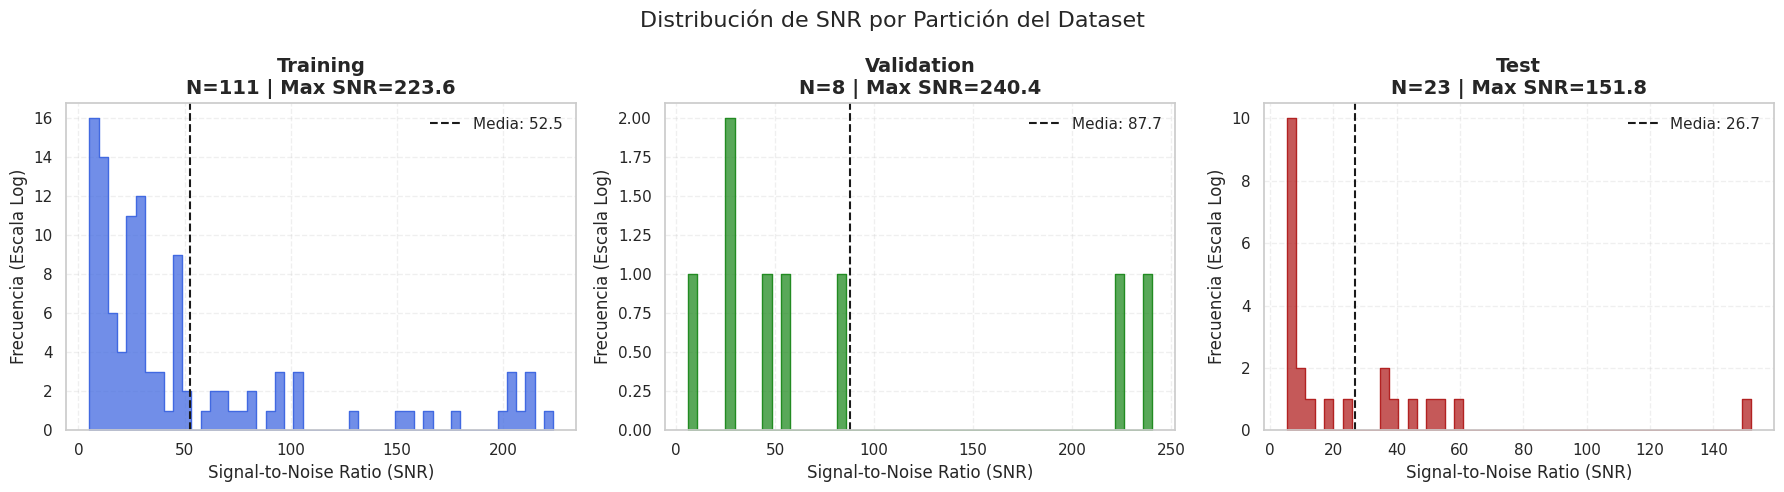

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PREPARACIÓN DE DATOS ---

# Aseguramos que la llave de cruce sea del mismo tipo (string)
partitions_0_v1['measurement_id'] = partitions_0_v1['measurement_id'].astype(str)
objects_metadata['measurement_id'] = objects_metadata['measurement_id'].astype(str)

# Hacemos el merge para agregar el SNR al dataframe de particiones
# Usamos 'inner' para quedarnos solo con los que tienen metadata
df_full = pd.merge(partitions_0_v1, objects_metadata[['measurement_id', 'snr']], 
                   on='measurement_id', 
                   how='inner')

print(f"Total de filas después del merge: {len(df_full)}")
print("Primeras filas con SNR:")
display(df_full[['measurement_id', 'partition', 'snr']].head())

# --- 2. CONFIGURACIÓN DE GRÁFICOS ---

# Definimos las particiones que queremos graficar (basado en tu dataframe)
# Nota: Ajusta los nombres si tu fold cambia (ej: training_1, validation_1)
partition_types = ['training_0', 'validation_0', 'test']
titles = ['Training', 'Validation', 'Test']
colors = ['royalblue', 'forestgreen', 'firebrick']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)

# --- 3. GENERACIÓN DE HISTOGRAMAS ---

for i, part_name in enumerate(partition_types):
    ax = axes[i]
    
    # Filtramos los datos de la partición actual
    subset = df_full[df_full['partition'] == part_name]
    snr_data = subset['snr']
    
    if len(snr_data) == 0:
        ax.text(0.5, 0.5, 'Sin datos', ha='center')
        continue

    # --- Histograma ---
    # Usamos escala logarítmica en el eje Y porque usualmente hay MUCHOS objetos
    # con SNR bajo y muy pocos con SNR alto (como tu supernova de 1493).
    # Sin log=True, las barras pequeñas no se verían.
    sns.histplot(snr_data, bins=50, ax=ax, color=colors[i], element="step")
    
    # Estadísticas básicas para poner en el título o leyenda
    mean_snr = snr_data.mean()
    max_snr = snr_data.max()
    count = len(snr_data)
    
    # Decoración del gráfico
    ax.set_title(f"{titles[i]}\nN={count} | Max SNR={max_snr:.1f}", fontsize=14, weight='bold')
    ax.set_xlabel("Signal-to-Noise Ratio (SNR)", fontsize=12)
    ax.set_ylabel("Frecuencia (Escala Log)", fontsize=12)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    # Opcional: Línea de media
    ax.axvline(mean_snr, color='k', linestyle='--', label=f'Media: {mean_snr:.1f}')
    ax.legend()

plt.suptitle("Distribución de SNR por Partición del Dataset", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [69]:
comm_agn_sne_vs_tran_dup_remove = pd.read_csv('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/ts_stamps_v0.0.2_comm_4candmax/comm_agn_sne_vs_tran_dup_remove.csv')
comm_agn_sne_vs_tran_dup_remove

,oid,survey_class_id,survey_class_distance,class,firstmjd,oid_kept
0,169368775386726461,1009114016849,0.609222,VS,60940.003226,169368775170719863
1,169364385944305671,1015112069977,1.982033,VS,60939.151416,169364385997783075
2,169364386924199954,1018107097138,1.063122,VS,60939.155210,169364387419127825
3,169368783856599207,3021142022266,0.387692,VS,60940.107958,169368783239512226
4,169368784297525279,3021144033003,0.647558,VS,60940.109901,169368784108257339
...,...,...,...,...,...,...
362,169342391212311388,XMM J00364-4308,0.449985,AGN,60934.117827,169342390661284183
363,169342391063413252,XMM J00364-4308,0.546642,AGN,60934.117390,169342390661284183
364,169342393206177934,XMM J00365-4313,0.131483,AGN,60934.126099,169342393353502786
365,169342392950849557,XMM J00365-4313,0.177763,AGN,60934.125181,169342393353502786


In [70]:
comm_agn_sne_vs_tran_dup_remove.oid_kept.nunique()

185

In [74]:
df_real_all_stamps[~df_real_all_stamps.oid.isin(comm_agn_sne_vs_tran_dup_remove.oid.values)]

,oid,measurement_id,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header,variance_Science_data,variance_Science_header,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169342391392665651,169368779404869680,"[[-11.43412, -61.157898, -36.767532, 2.3479912...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[19.970436, 9.456891, 13.70118, 1.8506378, 5....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-19.709507, -70.71258, -45.61192, -5.388886,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[1350.7681, 1316.2396, 1328.7379, 1375.7206, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[48.75372, 48.6074, 44.92881, 53.182293, 40.7...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[1406.3743, 1370.4304, 1383.4205, 1432.3733, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.69...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.69...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
1,169342391392665651,169368781154418723,"[[12.617219, 24.45698, 35.47745, 10.133407, 73...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[9.981423, 20.141548, 23.992834, 33.55316, 59...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-17.836555, -11.826263, -7.5156693, -41.9118...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[172.93977, 179.61725, 185.36595, 171.49901, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.86152, 13.508177, 13.792195, 13.8862915, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[189.61496, 196.93031, 203.23215, 188.03621, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.58...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.02857206888...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.58...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
2,169342391396859977,169342391396859977,"[[20.201748, 8.987029, 20.140661, 5.541897, 2....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[11.899033, 14.724549, 8.104676, 9.156919, 10...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[9.553257, -0.75593305, 11.6207695, -3.399367...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[113.74172, 110.11547, 114.21119, 107.290985,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[12.621083, 12.107674, 12.1881275, 14.158052,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[128.269, 124.173134, 128.77019, 121.12555, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
3,169342391461347756,169342391461347756,"[[7.650416, 16.770666, 41.501934, 16.376083, 2...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[21.86371, 25.689003, 24.45363, 27.604593, 15...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-18.728577, -10.020834, 17.58616, -11.041704...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[118.146385, 123.34396, 135.7948, 123.88186, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.748417, 16.173056, 14.099533, 15.934614, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[133.68181, 139.71996, 153.50385, 140.3026, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...

In [73]:
df_real_all_stamps[df_real_all_stamps.oid.isin(comm_agn_sne_vs_tran_dup_remove.oid_kept.values)]

,oid,measurement_id,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header,variance_Science_data,variance_Science_header,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
14,169298437882249291,169298437882249291,"[[37.16029, 18.078875, 76.76582, 67.33803, 50....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-0.082930885, -1.1145592, 7.0443726, 13.6600...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[36.152958, 16.424982, 68.7432, 53.83166, 35....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[2244.344, 2243.4363, 2272.6064, 2274.7783, 2...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[49.92926, 54.237007, 42.80257, 41.68789, 35....","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[2248.5989, 2249.638, 2273.423, 2275.0754, 22...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.82...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.82...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
15,169298437882249291,169355602436817237,"[[-9.144171, -15.126231, 12.561369, 16.764473,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-0.18351077, 0.23096211, 0.9737981, -0.98229...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-10.673359, -16.940327, 13.602255, 17.260143...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[91.47888, 88.44398, 101.79328, 103.646194, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[11.386079, 14.2777195, 14.061634, 11.387612,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[104.241165, 100.91635, 116.05136, 118.044174...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.25...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 3.571883281928324e-...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.25...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
16,169298437882249291,169355603762741336,"[[5.8729243, -0.5414381, 8.457336, -10.317265,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[5.9506407, 6.1578326, 1.1063801, 7.4481897, ...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[5.950175, -3.2757406, 5.6675143, -12.84734, ...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[89.748146, 87.697586, 91.879105, 83.18634, 8...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.429102, 9.954289, 13.232673, 11.734497, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[103.21339, 100.5167, 105.60901, 95.590935, 9...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.07...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.07...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
17,169298437882249291,169355603895386133,"[[-13.6318245, -4.273199, 7.748313, 14.7293415...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-2.747206, 1.7688464, 2.5081766, 3.947758, 4...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-14.272983, -6.981893, 8.245248, 12.961553, ...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[85.35115, 90.22739, 93.82398, 97.06603, 93.7...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[10.875007, 13.172547, 15.4871435, 10.8056345...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[97.59642, 103.35309, 107.66596, 110.8235, 10...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCO

In [75]:
6159 + 185

6344

In [ ]:
merged_sim_df = pd.merge(
    all_predictions_sim[0],
    synthetic_total_SN,
    left_on='measurement_id',
    right_on='synth_file_path',
    how='inner' # Nos quedamos solo con las filas que están en ambos archivos
)

merged_sim_df

NameError: name 'synthetic_total_SN' is not defined

In [ ]:
import seaborn as sns

# Preparación
merged_sim_df['is_correct'] = (merged_sim_df['predicted_label'] == 'SN').astype(int)
sns.set_theme(style="whitegrid")

# <--- CAMBIO PRINCIPAL AQUÍ ---

# Creamos bins más finos dentro del rango [0, 0.5]
radius_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
radius_labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5']

merged_sim_df['radius_bin'] = pd.cut(
    merged_sim_df['SN_ellip_dist'],
    bins=radius_bins,
    labels=radius_labels,
    right=True,
    include_lowest=True # Asegura que el valor 0.0 sea incluido
)

# --- 4. Análisis por Fracción de Radio de la Galaxia (con bins ajustados) ---

# Filtramos las filas donde el bin de radio es válido para evitar errores si no hay datos en un bin
plot_data = merged_sim_df.dropna(subset=['radius_bin'])

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_data,
    x='radius_bin',
    y='is_correct',
    palette='viridis',
    errorbar=None
)

# Añadir etiquetas con el valor exacto sobre cada barra
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2%}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 9),
        textcoords='offset points'
    )

plt.title('Rendimiento del Modelo vs. Distancia al Centro (Rango 0-0.5)', fontsize=16)
plt.xlabel('Fracción del Radio Elíptico (SN_ellip_dist)', fontsize=12)
plt.ylabel('Tasa de Aciertos (Recall para SN)', fontsize=12)
plt.ylim(0, 1.05)
plt.show()


# --- 5. Análisis por Banda Fotométrica (sin cambios) ---

band_counts = merged_sim_df['band'].value_counts().sort_index()
band_order = sorted(merged_sim_df['band'].unique())

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=merged_sim_df,
    x='band',
    y='is_correct',
    palette='magma',
    order=band_order,
    errorbar=None
)

for i, p in enumerate(ax.patches):
    band_name = band_order[i]
    if band_name in band_counts:
        count = band_counts[band_name]
        ax.annotate(
            f'{p.get_height():.2%}\n(n={count})',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 12),
            textcoords='offset points'
        )

plt.title('Rendimiento del Modelo por Banda Fotométrica', fontsize=16)
plt.xlabel('Banda', fontsize=12)
plt.ylabel('Tasa de Aciertos (Recall para SN)', fontsize=12)
plt.ylim(0, 1.15)
plt.show()

NameError: name 'merged_sim_df' is not defined

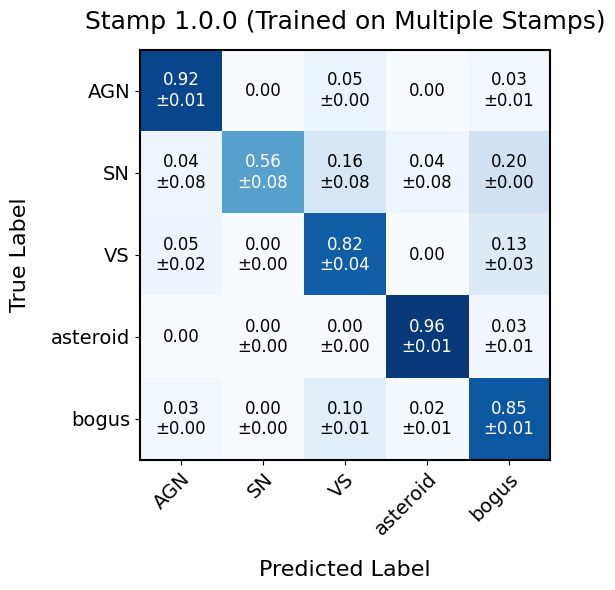

In [ ]:
# Célula 5 (Modificada): Función para Graficar la Matriz de Confusión con fuentes más grandes

def get_confusion_matrix(mean_matrix, std_matrix, order_classes):
    """
    Grafica la matriz de confusión mostrando la media y la desviación estándar.
    """
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=(6, 6)) # Puedes ajustar el tamaño del gráfico si es necesario
    im = ax.imshow(mean_matrix, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    for i in range(mean_matrix.shape[0]):
        for j in range(mean_matrix.shape[1]):
            mean_val = mean_matrix[i, j]
            std_val = std_matrix[i, j]
            
            if mean_val > 0.001:
                text = f'{mean_val:.2f}\n±{std_val:.2f}'
            else:
                text = f'{mean_val:.2f}'
            
            color = "white" if mean_val > 0.5 else "black"
            # Puedes ajustar el tamaño de la fuente dentro de las celdas aquí
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12) 

    # --- Ajustes de tamaño de fuente ---
    ax.set(xticks=np.arange(len(order_classes)),
           yticks=np.arange(len(order_classes)),
           xticklabels=order_classes, 
           yticklabels=order_classes,
           #title="Stamp 0.1.1 (production)",
           ylabel='True Label',
           xlabel='Predicted Label')

    ax.set_title(
        "Stamp 1.0.0 (Trained on Multiple Stamps)",
        fontsize=18, ## <-- CAMBIO AQUÍ
        pad=15       # Espaciado entre el título y el gráfico
    )

    # Aumentar el tamaño de la fuente de los nombres de las clases (ticks)
    ax.tick_params(axis='both', which='major', labelsize=14) ## <-- CAMBIO AQUÍ

    # Aumentar el tamaño de la fuente de las etiquetas de los ejes
    ax.xaxis.label.set_size(16) ## <-- CAMBIO AQUÍ
    ax.yaxis.label.set_size(16) ## <-- CAMBIO AQUÍ
    
    # Ajustar el espaciado para que no se corten las etiquetas
    ax.xaxis.labelpad = 15 ## <-- CAMBIO AQUÍ
    ax.yaxis.labelpad = 15 ## <-- CAMBIO AQUÍ
    
    # Rotación de las etiquetas del eje x
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Añadir borde negro exterior
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)

    fig.tight_layout()
    plt.show()

order_classes = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
get_confusion_matrix(mean_cm_norm, std_cm_norm, order_classes)

In [ ]:
all_predictions[0]

,oid,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
0,169364392051212498,4,4,bogus,bogus,0.434343,0.184093,0.000017,0.381500,0.000047,0.434343
1,169360000490668108,4,2,bogus,VS,0.571661,0.062115,0.000010,0.571661,0.000049,0.366165
2,169368782318862471,4,4,bogus,bogus,0.872643,0.000248,0.000003,0.125983,0.001122,0.872643
3,169355605687927642,4,4,bogus,bogus,0.970260,0.003292,0.000010,0.025823,0.000614,0.970260
4,169342391466066016,4,4,bogus,bogus,0.951035,0.000770,0.000005,0.047827,0.000364,0.951035
...,...,...,...,...,...,...,...,...,...,...,...
813,169364392197488647,4,3,bogus,asteroid,0.993502,0.000201,0.000042,0.000185,0.993502,0.006069
814,169342396864659557,4,4,bogus,bogus,0.955677,0.000377,0.000005,0.043274,0.000666,0.955677
815,169364389349031996,4,4,bogus,bogus,0.530318,0.000166,0.000143,0.001076,0.468298,0.530318
816,169368784371450454,4,4,bogus,bogus,0.698245,0.006324,0.000005,0.294938,0.000488,0.698245


Procesando 5 folds del conjunto de test.


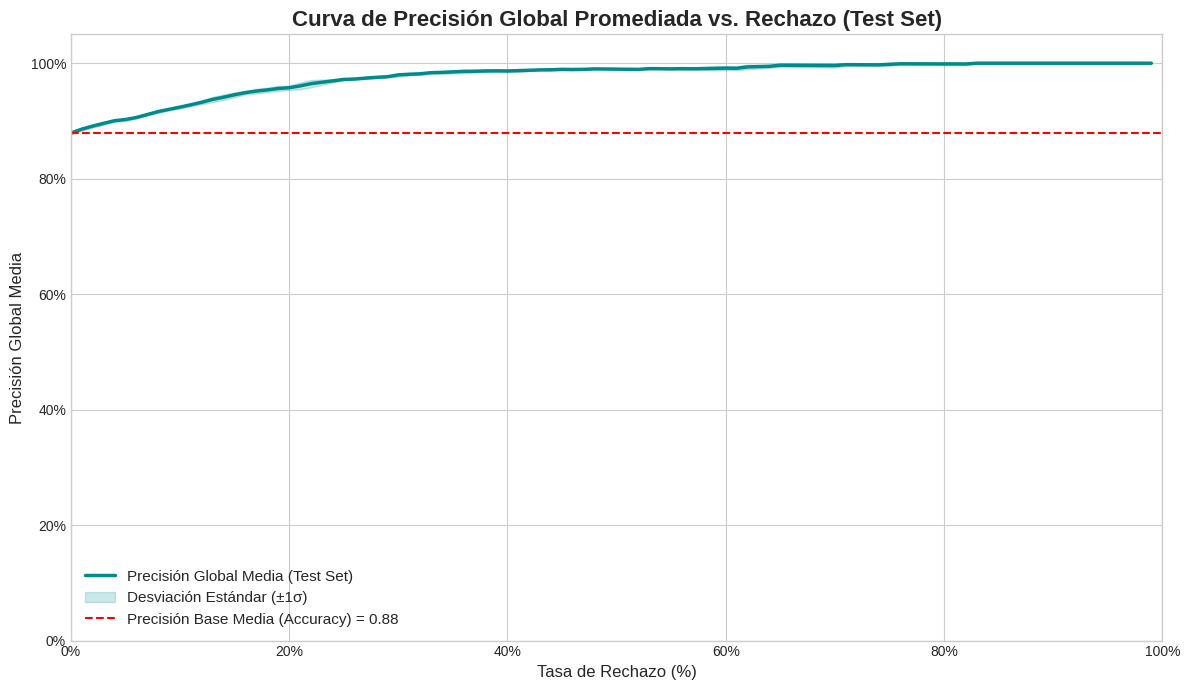


--- Interpretación de Ejemplo (Promedio en Test Set) ---
La precisión media (accuracy) sin rechazar ninguna alerta es: 87.90%
Al rechazar el 50% de las alertas con menor confianza, la precisión media aumenta a: 98.97% (con una desviación estándar de 0.10%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Cálculo de la Curva por Fold ---

if not isinstance(all_predictions, list) or not all(isinstance(df, pd.DataFrame) for df in all_predictions):
    raise TypeError("La variable 'all_predictions' debe ser una lista de DataFrames de pandas.")

print(f"Procesando {len(all_predictions)} folds del conjunto de test.")

rejection_rates = np.linspace(0, 0.99, 100)
precisions_per_fold = []

for i, df_fold in enumerate(all_predictions):
    # Verificar que las columnas necesarias existen
    required_cols = ['true_label', 'predicted_label', 'predicted_probability']
    if not all(col in df_fold.columns for col in required_cols):
        raise ValueError(f"El DataFrame del fold {i} no tiene las columnas requeridas: {required_cols}")

    fold_precisions = []
    scores = df_fold['predicted_probability'].values
    
    for rate in rejection_rates:
        threshold = np.quantile(scores, rate)
        df_accepted = df_fold[df_fold['predicted_probability'] >= threshold]
        
        if len(df_accepted) > 0:
            is_correct = (df_accepted['true_label'] == df_accepted['predicted_label'])
            precision = is_correct.mean()
        else:
            precision = np.nan
            
        fold_precisions.append(precision)
        
    precisions_per_fold.append(fold_precisions)

# --- Agregación de Resultados y Visualización ---

precisions_array = np.array(precisions_per_fold)

mean_precisions = np.nanmean(precisions_array, axis=0)
std_precisions = np.nanstd(precisions_array, axis=0)

upper_bound = mean_precisions + std_precisions
lower_bound = mean_precisions - std_precisions

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Línea de la precisión media
ax.plot(rejection_rates * 100, mean_precisions, 
        label='Precisión Global Media (Test Set)', 
        color='darkcyan', linewidth=2.5)

# Área sombreada para la desviación estándar
ax.fill_between(rejection_rates * 100, lower_bound, upper_bound, 
                color='darkcyan', alpha=0.2, 
                label='Desviación Estándar (±1σ)')

# Línea de base (precisión media sin rechazo)
baseline_precision = mean_precisions[0]
ax.axhline(y=baseline_precision, color='red', linestyle='--', 
           label=f'Precisión Base Media (Accuracy) = {baseline_precision:.2f}')

# Formato y etiquetas
ax.set_title('Curva de Precisión Global Promediada vs. Rechazo (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (%)', fontsize=12)
ax.set_ylabel('Precisión Global Media', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

plt.tight_layout()
plt.show()

# Imprimir un ejemplo de interpretación
idx_50_percent_rejection = np.argmin(np.abs(rejection_rates - 0.5))
precision_at_50 = mean_precisions[idx_50_percent_rejection]
std_at_50 = std_precisions[idx_50_percent_rejection]

print("\n--- Interpretación de Ejemplo (Promedio en Test Set) ---")
print(f"La precisión media (accuracy) sin rechazar ninguna alerta es: {baseline_precision:.2%}")
print(f"Al rechazar el 50% de las alertas con menor confianza, la precisión media aumenta a: {precision_at_50:.2%} (con una desviación estándar de {std_at_50:.2%})")

Procesando 5 folds para la clase 'SN' en el conjunto de test.


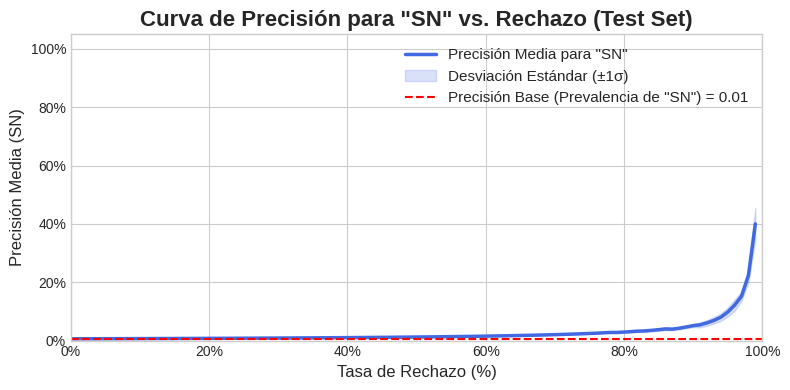


--- Interpretación de Ejemplo (Clase SN en Test Set) ---
La precisión base (prevalencia de SN en los datos) es: 0.61%
Al rechazar el 90% de las alertas con menor probabilidad de ser SN, la precisión media de las alertas restantes aumenta a: 5.12% (± 0.49%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Configuración del Análisis ---
POSITIVE_CLASS_NAME = 'SN'
prob_column_name = f'prob_{POSITIVE_CLASS_NAME}'

# --- Cálculo de la Curva por Fold ---
if not isinstance(all_predictions, list) or not all(isinstance(df, pd.DataFrame) for df in all_predictions):
    raise TypeError("La variable 'all_predictions' debe ser una lista de DataFrames de pandas.")

print(f"Procesando {len(all_predictions)} folds para la clase '{POSITIVE_CLASS_NAME}' en el conjunto de test.")

rejection_rates = np.linspace(0, 0.99, 100)
precisions_per_fold = []

for i, df_fold in enumerate(all_predictions):
    if prob_column_name not in df_fold.columns:
        raise ValueError(f"La columna '{prob_column_name}' no se encuentra en el DataFrame del fold {i}.")

    fold_precisions = []
    # Usamos la columna de probabilidad específica de SN como nuestro score
    scores = df_fold[prob_column_name].values
    
    for rate in rejection_rates:
        threshold = np.quantile(scores, rate)
        df_accepted = df_fold[df_fold[prob_column_name] >= threshold]
        
        if len(df_accepted) > 0:
            # Precisión = (Nº de aceptados que eran SN reales) / (Nº total de aceptados)
            is_correct = (df_accepted['true_label'] == POSITIVE_CLASS_NAME)
            precision = is_correct.mean()
        else:
            precision = np.nan
            
        fold_precisions.append(precision)
        
    precisions_per_fold.append(fold_precisions)

# --- Agregación de Resultados y Visualización ---

precisions_array = np.array(precisions_per_fold)

mean_precisions = np.nanmean(precisions_array, axis=0)
std_precisions = np.nanstd(precisions_array, axis=0)

upper_bound = mean_precisions + std_precisions
lower_bound = mean_precisions - std_precisions

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 4))

# Línea de la precisión media
ax.plot(rejection_rates * 100, mean_precisions, 
        label=f'Precisión Media para "{POSITIVE_CLASS_NAME}"', 
        color='royalblue', linewidth=2.5)

# Área sombreada para la desviación estándar
ax.fill_between(rejection_rates * 100, lower_bound, upper_bound, 
                color='royalblue', alpha=0.2, 
                label='Desviación Estándar (±1σ)')

# Línea de base (prevalencia de la clase en el test set)
baseline_precision = mean_precisions[0]
ax.axhline(y=baseline_precision, color='red', linestyle='--', 
           label=f'Precisión Base (Prevalencia de "{POSITIVE_CLASS_NAME}") = {baseline_precision:.2f}')

# Formato y etiquetas
ax.set_title(f'Curva de Precisión para "{POSITIVE_CLASS_NAME}" vs. Rechazo (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (%)', fontsize=12)
ax.set_ylabel(f'Precisión Media ({POSITIVE_CLASS_NAME})', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

plt.tight_layout()
plt.show()

# Imprimir un ejemplo de interpretación
idx_90_percent_rejection = np.argmin(np.abs(rejection_rates - 0.90))
precision_at_90 = mean_precisions[idx_90_percent_rejection]
std_at_90 = std_precisions[idx_90_percent_rejection]

print("\n--- Interpretación de Ejemplo (Clase SN en Test Set) ---")
print(f"La precisión base (prevalencia de SN en los datos) es: {baseline_precision:.2%}")
if not np.isnan(precision_at_90):
    print(f"Al rechazar el 90% de las alertas con menor probabilidad de ser SN, la precisión media de las alertas restantes aumenta a: {precision_at_90:.2%} (± {std_at_90:.2%})")

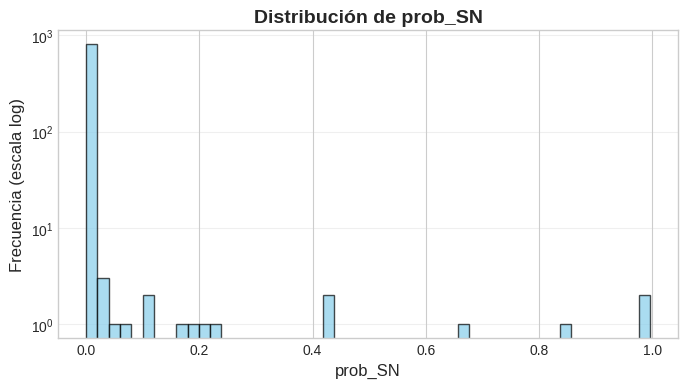

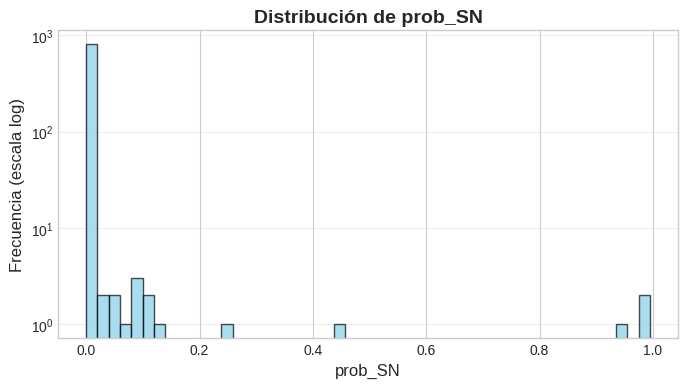

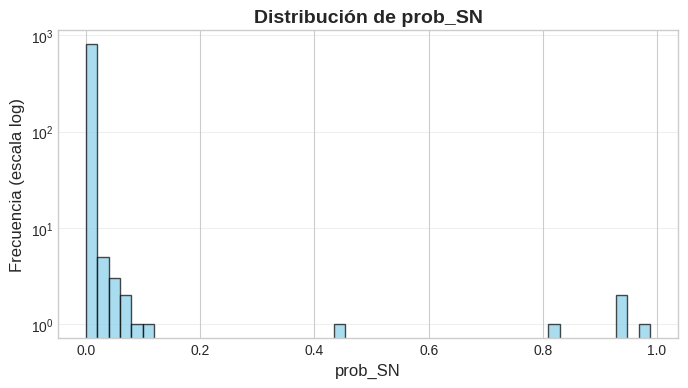

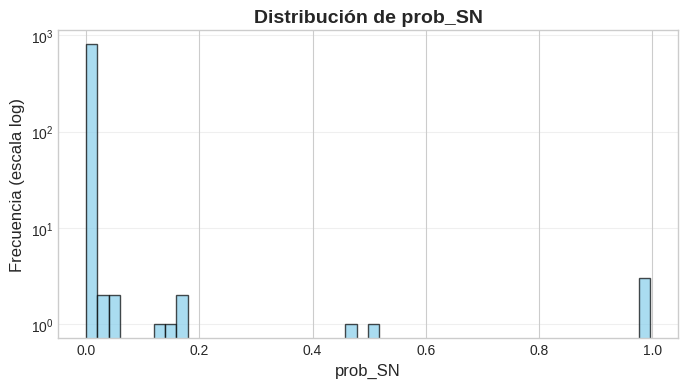

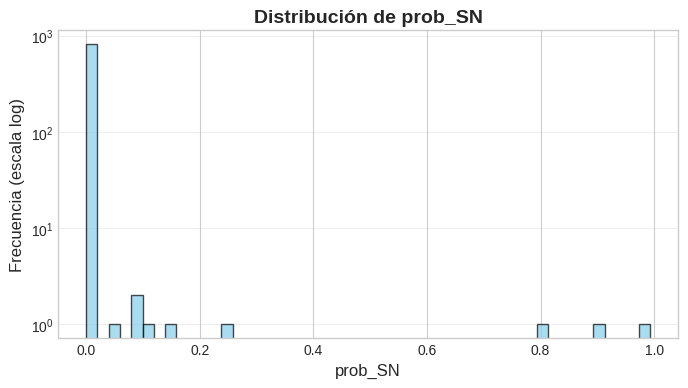

In [ ]:
import matplotlib.pyplot as plt

for df_fold in all_predictions:
    plt.figure(figsize=(8, 4))
    df_fold[prob_column_name].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {prob_column_name}', fontsize=14, fontweight='bold')
    plt.xlabel(prob_column_name, fontsize=12)
    plt.ylabel('Frecuencia (escala log)', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.yscale('log')  # Escala logarítmica en el eje Y
    plt.show()

In [ ]:
sn = df_fold[df_fold.true_label == 'SN']
sn

,oid,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
218,169355604935573556,1,1,SN,SN,0.992497,0.000018,0.992497,0.000021,0.007409,0.000055
219,169342396737257673,1,1,SN,SN,0.802814,0.002947,0.802814,0.192226,0.001865,0.000148
220,169342396578398273,1,3,SN,asteroid,0.565010,0.008705,0.115861,0.309919,0.565010,0.000505
221,21164710903756869,1,4,SN,bogus,0.986402,0.003338,0.000011,0.010219,0.000030,0.986402
222,21163628757006675,1,0,SN,AGN,0.802352,0.802352,0.084268,0.099232,0.001836,0.012312


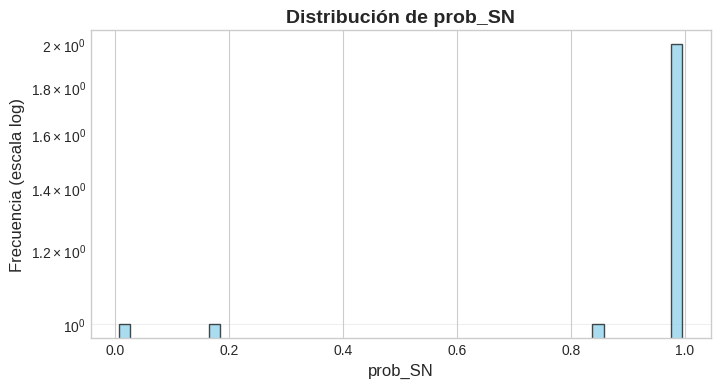

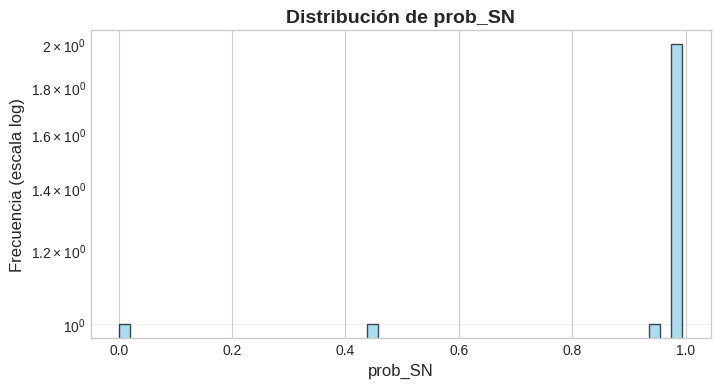

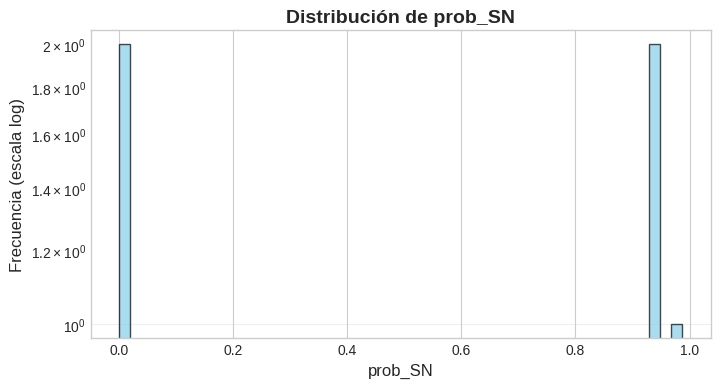

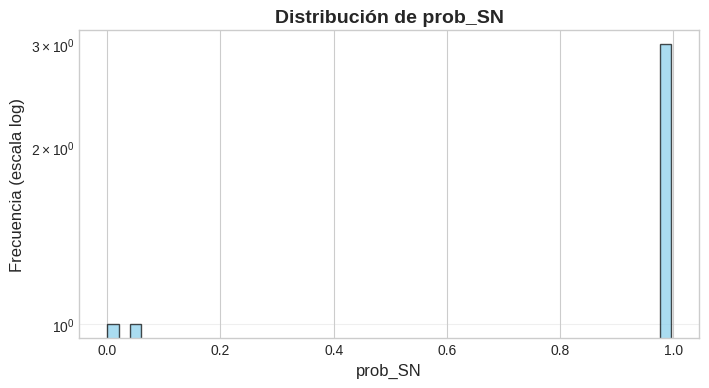

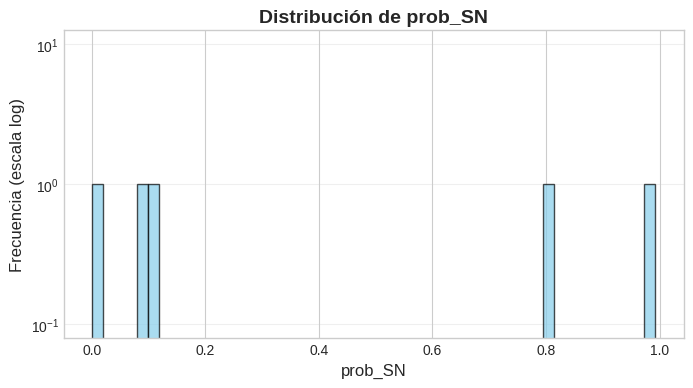

In [ ]:
for df_fold in all_predictions:
    sn = df_fold[df_fold.true_label == 'SN']
    plt.figure(figsize=(8, 4))
    sn[prob_column_name].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {prob_column_name}', fontsize=14, fontweight='bold')
    plt.xlabel(prob_column_name, fontsize=12)
    plt.ylabel('Frecuencia (escala log)', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.yscale('log')  # Escala logarítmica en el eje Y
    plt.show()

In [ ]:
class_map = {
    0: "AGN",
    1: "SN",
    2: "VS",
    3: "asteroid",
    4: "bogus"
}

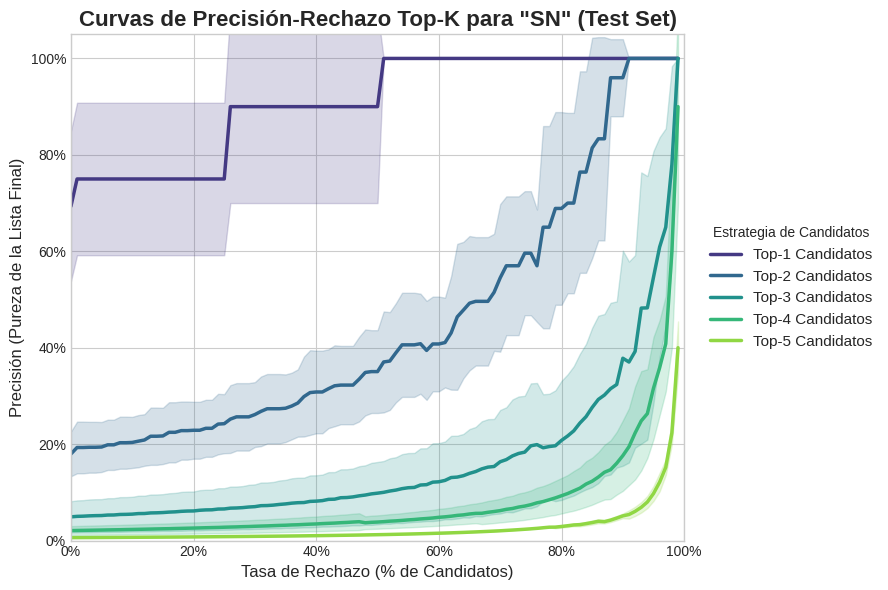

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# --- Configuración del Análisis (sin cambios) ---
TARGET_CLASS_NAME = 'SN'
prob_columns = [f'prob_{name}' for name in class_map.values()]
class_map_inv = {v: k for k, v in class_map.items()}
target_class_id = class_map_inv[TARGET_CLASS_NAME]
prob_column_name = f'prob_{TARGET_CLASS_NAME}'

k_values = [1, 2, 3, 4, 5]
rejection_rates = np.linspace(0, 0.99, 100)

all_curves_data = {k: [] for k in k_values}

# --- Bucle principal por Fold (sin cambios) ---
for df_fold in all_predictions:
    probs = df_fold[prob_columns].to_numpy()
    sorted_class_indices = np.argsort(probs, axis=1)[:, ::-1]
    
    for k in k_values:
        top_k_indices = sorted_class_indices[:, :k]
        is_candidate = np.any(top_k_indices == target_class_id, axis=1)
        df_candidates_k = df_fold[is_candidate]
        
        if len(df_candidates_k) == 0:
            all_curves_data[k].append([np.nan] * len(rejection_rates))
            continue

        fold_precisions = []
        scores = df_candidates_k[prob_column_name].values
        
        for rate in rejection_rates:
            if len(scores) < 2:
                fold_precisions.append(np.nan)
                continue
                
            threshold = np.quantile(scores, rate)
            df_accepted = df_candidates_k[df_candidates_k[prob_column_name] >= threshold]
            
            if len(df_accepted) > 0:
                is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
                precision = is_correct.mean()
            else:
                precision = np.nan
                
            fold_precisions.append(precision)
        
        all_curves_data[k].append(fold_precisions)

# --- Agregación y Visualización (Con la leyenda afuera) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette("viridis", n_colors=len(k_values))

for i, k in enumerate(k_values):
    precisions_array = np.array(all_curves_data[k])
    
    mean_precisions = np.nanmean(precisions_array, axis=0)
    std_precisions = np.nanstd(precisions_array, axis=0)
    upper_bound = mean_precisions + std_precisions
    lower_bound = mean_precisions - std_precisions
    
    if not np.all(np.isnan(mean_precisions)):
        ax.plot(rejection_rates * 100, mean_precisions, 
                label=f'Top-{k} Candidatos', 
                color=palette[i], linewidth=2.5)
        
        ax.fill_between(rejection_rates * 100, lower_bound, upper_bound,
                        color=palette[i], alpha=0.2)

# Formato y etiquetas
ax.set_title(f'Curvas de Precisión-Rechazo Top-K para "{TARGET_CLASS_NAME}" (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (% de Candidatos)', fontsize=12)
ax.set_ylabel('Precisión (Pureza de la Lista Final)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

# --- LÍNEA MODIFICADA PARA MOVER LA LEYENDA ---
ax.legend(title="Estrategia de Candidatos", fontsize=11, 
          bbox_to_anchor=(1.02, 0.5), loc='center left')
# ---------------------------------------------

# Ajusta el layout para asegurar que la leyenda quepa
plt.tight_layout()
plt.show()

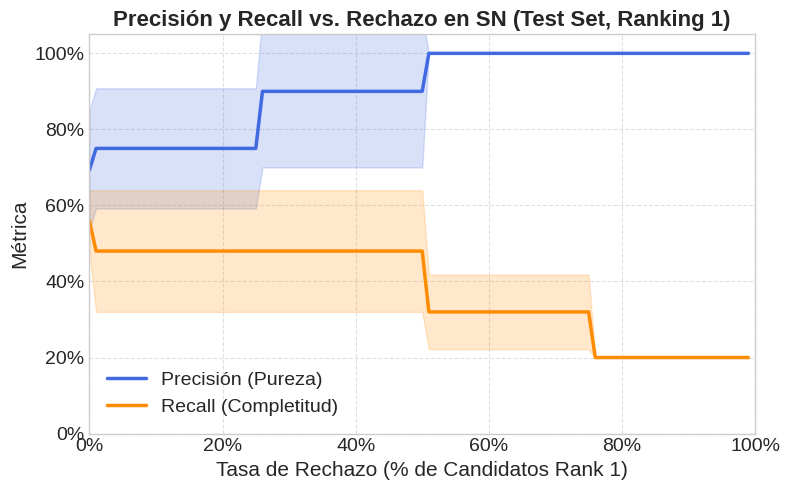

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Asumimos que 'all_predictions', 'tables' y 'class_map' ya existen ---
# (Usaré mocks para que el código sea ejecutable)
# ----------------- INICIO DEL MOCK DATA -----------------
def create_mock_predictions_sn(num_rows=800, num_folds=5): # Test Set Data
    mock_list = []
    labels = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
    label_p = [0.1, 0.02, 0.15, 0.25, 0.48]
    for i in range(num_folds):
        df = pd.DataFrame()
        df['true_label'] = np.random.choice(labels, num_rows, p=label_p)
        probs = np.random.rand(num_rows, len(labels))
        # Make SN probs higher for real SNs and for predicted SNs
        true_sn_indices = df[df['true_label'] == 'SN'].index
        probs[true_sn_indices, 1] = np.clip(probs[true_sn_indices, 1] + 0.6, 0, 1)
        probs = probs / probs.sum(axis=1, keepdims=True)
        for idx, label_name in enumerate(labels):
             df[f'prob_{label_name}'] = probs[:, idx]
        df['predicted_label'] = pd.Index(labels)[np.argmax(probs, axis=1)]
        mock_list.append(df)
    return mock_list

def create_mock_tables(num_rows=20000): # Production Data
    df = pd.DataFrame()
    df['class_id'] = np.random.choice([0, 1, 2, 3, 4], num_rows, p=[0.05, 0.2, 0.3, 0.15, 0.3])
    df['ranking'] = np.random.randint(1, 6, num_rows)
    probs = np.random.beta(a=2, b=15, size=num_rows) + (1 - (df['ranking'] / 5)) * 0.3
    sn_indices = df[df['class_id'] == 0].index
    probs[sn_indices] = probs[sn_indices] + np.random.uniform(0, 0.4, size=len(sn_indices))
    df['probability'] = np.clip(probs, 0.01, 1.0)
    return df

class_map = {0: 'AGN', 1: 'SN', 2: 'VS', 3: 'asteroid', 4: 'bogus'}
if 'all_predictions' not in locals():
    print("Usando datos de ejemplo (mock) para 'all_predictions'.")
    all_predictions = create_mock_predictions_sn()
if 'tables' not in locals():
    print("Usando datos de ejemplo (mock) para 'tables'.\n")
    tables = create_mock_tables()
# ----------------- FIN DEL MOCK DATA -----------------


# --- Configuración del Análisis ---
TARGET_CLASS_NAME = 'SN'
SN_CLASS_ID = 1 # Asumo ID=1 para SN, cámbialo si es necesario
prob_column_name = f'prob_{TARGET_CLASS_NAME}'
rejection_rates = np.linspace(0, 0.99, 100)

# --- Creación de los Subplots ---
fig, ax1 = plt.subplots(figsize=(8, 5))
#ax1, ax2 = axes[0], axes[1]

# ==============================================================================
# GRÁFICO 1: ANÁLISIS EN EL CONJUNTO DE TEST (all_predictions)
# ==============================================================================
precisions_per_fold = []
recalls_per_fold = []

for df_fold in all_predictions:
    # El denominador del Recall: el número total de SN reales en este fold
    total_true_sns_in_fold = (df_fold['true_label'] == TARGET_CLASS_NAME).sum()

    # Filtramos para quedarnos solo con los candidatos de Ranking 1
    # En este dataset, Ranking 1 significa que la predicción fue SN
    candidates_rank1 = df_fold[df_fold['predicted_label'] == TARGET_CLASS_NAME]
    
    fold_precisions, fold_recalls = [], []
    scores = candidates_rank1[prob_column_name].values
    
    for rate in rejection_rates:
        if len(scores) < 2 or total_true_sns_in_fold == 0:
            fold_precisions.append(np.nan)
            fold_recalls.append(np.nan)
            continue
            
        threshold = np.quantile(scores, rate)
        df_accepted = candidates_rank1[candidates_rank1[prob_column_name] >= threshold]
        
        if len(df_accepted) > 0:
            # Precisión
            is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
            precision = is_correct.mean()
            # Recall
            true_positives = is_correct.sum()
            recall = true_positives / total_true_sns_in_fold
        else:
            precision, recall = np.nan, 0 # Si no aceptamos nada, la precisión es indefinida y el recall es 0
            
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        
    precisions_per_fold.append(fold_precisions)
    recalls_per_fold.append(fold_recalls)

# --- Agregación y Visualización para Test Set ---
# Precisión
mean_precisions = np.nanmean(precisions_per_fold, axis=0)
std_precisions = np.nanstd(precisions_per_fold, axis=0)
# Recall
mean_recalls = np.nanmean(recalls_per_fold, axis=0)
std_recalls = np.nanstd(recalls_per_fold, axis=0)

# Graficar Precisión
ax1.plot(rejection_rates * 100, mean_precisions, label='Precisión (Pureza)', color='royalblue', lw=2.5)
ax1.fill_between(rejection_rates * 100, mean_precisions - std_precisions, mean_precisions + std_precisions, color='royalblue', alpha=0.2)

# Graficar Recall
ax1.plot(rejection_rates * 100, mean_recalls, label='Recall (Completitud)', color='darkorange', lw=2.5)
ax1.fill_between(rejection_rates * 100, mean_recalls - std_recalls, mean_recalls + std_recalls, color='darkorange', alpha=0.2)
ax1.set_title('Precisión y Recall vs. Rechazo en SN (Test Set, Ranking 1)', fontsize=16, weight='bold')
ax1.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=15)
ax1.set_ylabel('Métrica', fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=14)

ax1.set_ylim(0, 1.05)
ax1.set_xlim(0, 100)

ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
ax1.legend(fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# ==============================================================================
# GRÁFICO 2: ANÁLISIS EN PRODUCCIÓN (tables)
# ==============================================================================
# Denominador del Recall: Total de SN reales en producción
total_true_sns_in_prod = (tables['class_id'] == SN_CLASS_ID).sum()

# Filtramos para candidatos de Ranking 1
prod_candidates_rank1 = tables[
    (tables.class_id == SN_CLASS_ID) & # Esto es para producción, así que asumimos que class_id es el tipo de objeto
    (tables.ranking == 1)
]

prod_precisions, prod_recalls = [], []
prod_scores = prod_candidates_rank1['probability'].values

for rate in rejection_rates:
    if len(prod_scores) < 2 or total_true_sns_in_prod == 0:
        prod_precisions.append(np.nan)
        prod_recalls.append(np.nan)
        continue

    threshold = np.quantile(prod_scores, rate)
    df_accepted = prod_candidates_rank1[prod_candidates_rank1.probability >= threshold]
    
    if len(df_accepted) > 0:
        # En producción, la precisión de los candidatos de Rank 1 es siempre 100% por definición
        precision = 1.0 
        true_positives = len(df_accepted)
        recall = true_positives / total_true_sns_in_prod
    else:
        precision, recall = np.nan, 0
    
    prod_precisions.append(precision)
    prod_recalls.append(recall)

# --- Visualización para Producción ---
#ax2.plot(rejection_rates * 100, prod_precisions, label='Precisión (Pureza)', color='royalblue', lw=2.5)
#ax2.plot(rejection_rates * 100, prod_recalls, label='Recall (Completitud)', color='darkorange', lw=2.5)
#ax2.set_title('Precisión y Recall vs. Rechazo (Producción, Ranking 1)', fontsize=14, weight='bold')
#ax2.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=12)

# --- Formato Final para Ambos Gráficos ---
#for ax in axes:
#    ax.set_ylim(0, 1.05)
#    ax.set_xlim(0, 100)
#    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
#    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
#    ax.legend()
#    ax.grid(True, linestyle='--', alpha=0.6)

#fig.suptitle('Análisis del Trade-off Precisión-Recall para Candidatos a SN de Ranking 1', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df_fold[prob_column_name].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f'Distribución de {prob_column_name}', fontsize=14, fontweight='bold')
plt.xlabel(prob_column_name, fontsize=12)
plt.ylabel('Frecuencia (escala log)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')  # Escala logarítmica en el eje Y
plt.show()

Procesando 5 folds del conjunto de test.


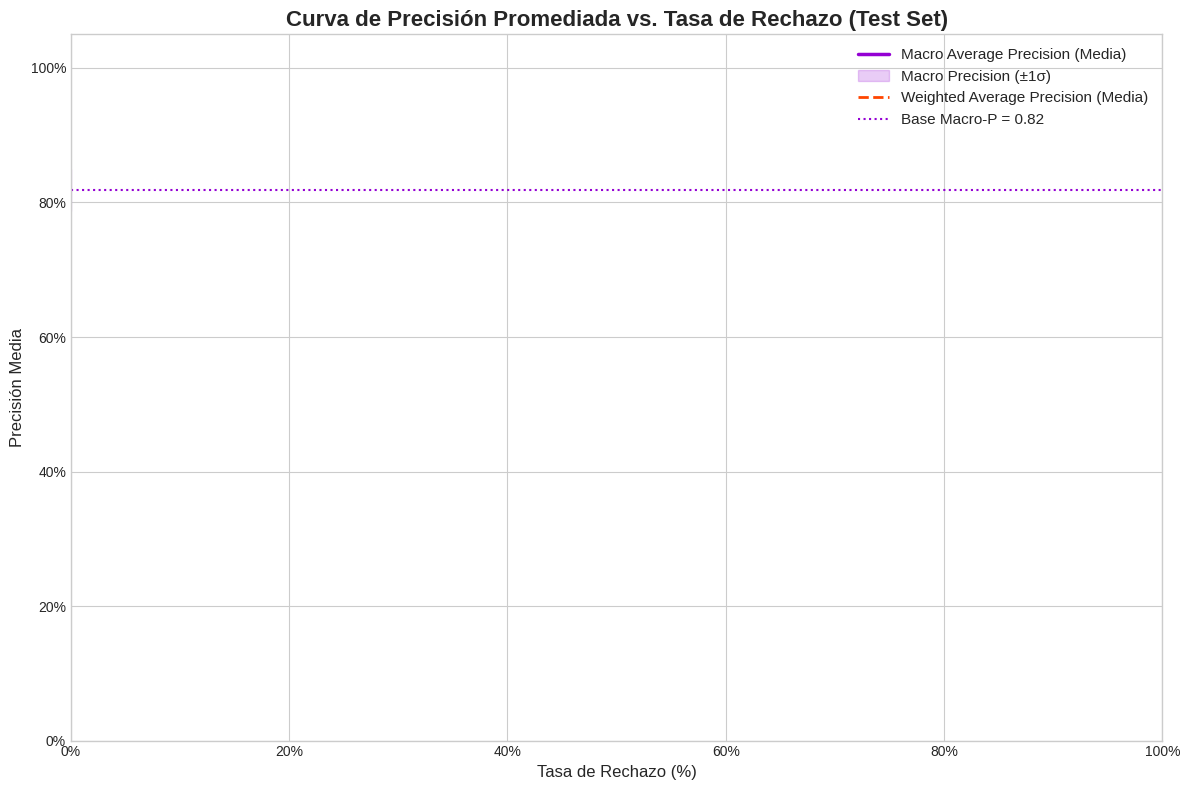

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import precision_score



print(f"Procesando {len(all_predictions)} folds del conjunto de test.")

rejection_rates = np.linspace(0, 0, 100)
macro_precisions_per_fold = []
weighted_precisions_per_fold = []

all_labels = pd.concat(all_predictions)['true_label'].unique()

for i, df_fold in enumerate(all_predictions):
    fold_macro_p = []
    fold_weighted_p = []
    scores = df_fold['predicted_probability'].values
    
    for rate in rejection_rates:
        threshold = np.quantile(scores, rate)
        df_accepted = df_fold[df_fold['predicted_probability'] >= threshold]
        
        if len(df_accepted) > 1: # Necesitamos al menos 2 muestras para un cálculo estable
            y_true = df_accepted['true_label']
            y_pred = df_accepted['predicted_label']
            
            # Calcular Macro Precision
            macro_p = precision_score(y_true, y_pred, labels=all_labels, average='macro', zero_division=0)
            fold_macro_p.append(macro_p)
            
            # Calcular Weighted Precision
            weighted_p = precision_score(y_true, y_pred, labels=all_labels, average='weighted', zero_division=0)
            fold_weighted_p.append(weighted_p)
        else:
            fold_macro_p.append(np.nan)
            fold_weighted_p.append(np.nan)
            
    macro_precisions_per_fold.append(fold_macro_p)
    weighted_precisions_per_fold.append(fold_weighted_p)

# --- Agregación de Resultados y Visualización ---

# Macro Precision
mean_macro_p = np.nanmean(macro_precisions_per_fold, axis=0)
std_macro_p = np.nanstd(macro_precisions_per_fold, axis=0)

# Weighted Precision
mean_weighted_p = np.nanmean(weighted_precisions_per_fold, axis=0)
std_weighted_p = np.nanstd(weighted_precisions_per_fold, axis=0)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Trazar Macro Precision
ax.plot(rejection_rates * 100, mean_macro_p, 
        label='Macro Average Precision (Media)', 
        color='darkviolet', linewidth=2.5)
ax.fill_between(rejection_rates * 100, mean_macro_p - std_macro_p, mean_macro_p + std_macro_p, 
                color='darkviolet', alpha=0.2, label='Macro Precision (±1σ)')

# Trazar Weighted Precision
ax.plot(rejection_rates * 100, mean_weighted_p, 
        label='Weighted Average Precision (Media)', 
        color='orangered', linestyle='--', linewidth=2)

# Línea de base
baseline_macro = mean_macro_p[0]
ax.axhline(y=baseline_macro, color='darkviolet', linestyle=':', 
           label=f'Base Macro-P = {baseline_macro:.2f}')

# Formato y etiquetas
ax.set_title('Curva de Precisión Promediada vs. Tasa de Rechazo (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (%)', fontsize=12)
ax.set_ylabel('Precisión Media', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

plt.tight_layout()
plt.show()

In [ ]:
condicion_true_sn = (predictions['true_label'] == 'SN')
condicion_predicted_vs = (predictions['predicted_label'] == 'AGN')

# Aplicamos ambas condiciones al DataFrame
sn_confundidos_con_vs = predictions[condicion_true_sn & condicion_predicted_vs]


# --- 3. Mostrar los resultados ---
print("Supernovas (SN) clasificadas erróneamente como Estrellas Variables (AGN):")
print("="*70)

if sn_confundidos_con_vs.empty:
    print("No se encontraron Supernovas clasificadas como Estrellas Variables en los datos.")
else:
    print(sn_confundidos_con_vs)

Supernovas (SN) clasificadas erróneamente como Estrellas Variables (AGN):
No se encontraron Supernovas clasificadas como Estrellas Variables en los datos.
